## 🩺 ECG Arrhythmia Classification Using the MIT-BIH Database

This project focuses on the classification of ECG heartbeats using signals from the MIT-BIH Arrhythmia Database.  
The main objective is to identify the most informative features for distinguishing different heartbeat types and to compare the performance of traditional machine learning models with deep learning approaches.  
Additionally, the project investigates the impact of class imbalance and inter-patient variability on classification performance.  
Finally, ensemble strategies are explored to evaluate whether combining multiple models can improve the accuracy of arrhythmia detection.


##  Step 1: Data Extraction and Conversion

In this step, I convert the original ECG records from the MIT-BIH Arrhythmia Database into structured CSV files.  
This step is important because working with the original PhysioNet files is not easy inside Jupyter, while CSV files are simpler to load, inspect, and process.  
Using the WFDB library, the ECG signals and their annotations are read and saved as compressed `.csv.gz` files, with one file for each record to reduce storage size and avoid memory problems.


In [30]:
# === MIT-BIH Arrhythmia -> CSV ===
# In this step, I convert the MIT-BIH Arrhythmia Database into compressed CSV files (.csv.gz).
# I save each ECG record separately to make the analysis easier and to avoid memory problems.

# Install required packages (I run this only once)
%pip install -q wfdb pandas numpy tqdm

# -----------------------------
# Imports
# -----------------------------
# Here, I import all the libraries needed to load ECG signals,
# handle annotations, and save the data as CSV files.
import os, gzip, glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import wfdb   # I use wfdb to read ECG signals and annotations from PhysioNet

# -----------------------------
# Settings
# -----------------------------
# I define the PhysioNet directory and the output folder.
PN_DIR = "mitdb/1.0.0"      # Path to the MIT-BIH dataset
OUT_DIR = "./mitdb_csv"     # Folder where I will save the CSV files
MAKE_ONE_BIG_FILE = False   # If True, I combine all records into one large CSV
EXPAND_ANN_SYMBOLS = False  # If True, I convert annotation symbols to full names

# I create the output directory if it does not already exist.
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Annotation symbol map (optional)
# -----------------------------
# This dictionary maps annotation symbols to their full descriptions.
ANN_MAP = {
    "N": "Normal beat",
    "L": "Left bundle branch block beat",
    "R": "Right bundle branch block beat",
    "B": "Bundle branch block beat (unspecified)",
    "A": "Atrial premature beat",
    "a": "Aberrated atrial premature beat",
    "J": "Nodal (junctional) premature beat",
    "S": "Supraventricular premature or ectopic beat",
    "V": "Premature ventricular contraction",
    "r": "R-on-T premature ventricular contraction",
    "F": "Fusion of ventricular and normal beat",
    "e": "Atrial escape beat",
    "j": "Nodal (junctional) escape beat",
    "n": "Supraventricular escape beat",
    "E": "Ventricular escape beat",
    "/": "Paced beat",
    "f": "Fusion of paced and normal beat",
    "Q": "Unclassifiable beat",
    "?": "Beat not classified",
}

# -----------------------------
# Helper function: safely convert annotation lists to strings
# -----------------------------
def safe_to_str_list(x, length):
    """
    Here, I convert annotation lists (symbols or auxiliary notes)
    into a fixed-length list of strings. This helps avoid errors
    when annotations are missing or stored as bytes.
    """
    if x is None:
        return [None] * length

    out = []
    for v in x:
        if v is None:
            out.append(None)
        elif isinstance(v, bytes):
            out.append(v.decode("utf-8", "ignore"))
        else:
            out.append(str(v))

    if len(out) < length:
        out += [None] * (length - len(out))
    elif len(out) > length:
        out = out[:length]

    return out

# -----------------------------
# Get list of all record IDs
# -----------------------------
def get_all_records():
    """
    In this function, I try to get the official list of MIT-BIH
    record IDs from PhysioNet. If this fails, I fall back to the
    standard range from 100 to 234.
    """
    try:
        recs = wfdb.get_record_list("mitdb")
        if isinstance(recs, list) and len(recs) > 0:
            return recs
    except Exception:
        print("wfdb.get_record_list failed; using fallback list (100–234).")

    return [str(i) for i in range(100, 235)]

# -----------------------------
# Export one record to CSV.GZ
# -----------------------------
def export_record_to_csv(record_name, out_dir, pn_dir=PN_DIR):
    """
    In this function, I load one ECG record and its annotations,
    then save everything as a compressed CSV file (.csv.gz).
    """
    # I load the ECG signal
    rec = wfdb.rdrecord(record_name, pn_dir=pn_dir)
    fs = float(rec.fs)
    n = int(rec.sig_len)
    ch_names = list(rec.sig_name)

    # I create the time axis in seconds
    sample = np.arange(n, dtype=np.int64)
    time_sec = sample / fs

    # I build a DataFrame with the ECG channels
    df = pd.DataFrame(rec.p_signal, columns=ch_names)
    df.insert(0, "time_sec", time_sec)
    df.insert(0, "sample", sample)
    df.insert(0, "record", record_name)

    # I try to load the annotation file
    ann = None
    for annotator in ["atr", "qrs", "ecg", "ari"]:
        try:
            ann = wfdb.rdann(record_name, annotator, pn_dir=pn_dir)
            break
        except Exception:
            pass

    # I merge annotations with the ECG signal
    if ann is not None and len(ann.sample) > 0:
        ann_samples = np.asarray(ann.sample, dtype=np.int64)
        ann_symbols = safe_to_str_list(getattr(ann, "symbol", None), len(ann_samples))
        ann_aux = safe_to_str_list(getattr(ann, "aux_note", None), len(ann_samples))

        ann_df = pd.DataFrame({
            "sample": ann_samples,
            "ann_symbol": ann_symbols,
            "ann_desc": ann_aux,
        })

        df = df.merge(ann_df, on="sample", how="left")

        if EXPAND_ANN_SYMBOLS:
            df["ann_name"] = df["ann_symbol"].map(ANN_MAP)
    else:
        df["ann_symbol"] = np.nan
        df["ann_desc"] = np.nan
        if EXPAND_ANN_SYMBOLS:
            df["ann_name"] = np.nan

    # I save the record as a compressed CSV file
    out_path = os.path.join(out_dir, f"{record_name}.csv.gz")
    with gzip.open(out_path, "wt", newline="") as f:
        df.to_csv(f, index=False)

    return out_path

# -----------------------------
# Clean old CSV files (important)
# -----------------------------
# To avoid confusion, I remove any old .csv files
# and keep only the compressed .csv.gz files.
old_csv = glob.glob(os.path.join(OUT_DIR, "*.csv"))
for f in old_csv:
    os.remove(f)

# -----------------------------
# Run export for all records
# -----------------------------
# Here, I convert all MIT-BIH records one by one.
records = get_all_records()
print(f"Found {len(records)} candidate record IDs.")

exported, failed = [], []

for r in tqdm(records):
    try:
        path = export_record_to_csv(r, OUT_DIR, pn_dir=PN_DIR)
        exported.append(path)
    except Exception as e:
        failed.append((r, str(e)))

print(f"\nExported {len(exported)} records to: {OUT_DIR}")

if failed:
    print("Skipped / failed records:")
    for r, msg in failed[:20]:
        print(f"  {r}: {msg}")
    if len(failed) > 20:
        print(f"  ... and {len(failed) - 20} more")

# -----------------------------
# Optional: build one big CSV
# -----------------------------
# If I enable this option, I combine all records into one large CSV file.
if MAKE_ONE_BIG_FILE:
    print("\nBuilding combined CSV...")
    chunks = []
    for path in tqdm(sorted(glob.glob(os.path.join(OUT_DIR, "*.csv.gz")))):
        with gzip.open(path, "rt") as f:
            chunks.append(pd.read_csv(f))

    big = pd.concat(chunks, ignore_index=True)
    big_out = os.path.join(OUT_DIR, "mitdb_all_records.csv.gz")

    with gzip.open(big_out, "wt", newline="") as f:
        big.to_csv(f, index=False)

    print(f"Combined CSV saved to: {big_out}")

print("\nConversion complete!")
print(f"All CSV files are in: {os.path.abspath(OUT_DIR)}")


Note: you may need to restart the kernel to use updated packages.
Found 48 candidate record IDs.


100%|██████████| 48/48 [30:18<00:00, 37.89s/it]


Exported 48 records to: ./mitdb_csv

Conversion complete!
All CSV files are in: C:\Users\PC PRO MAX\mitdb_csv


After running the script, **I successfully extracted the ECG signals and their annotations and saved them as compressed CSV files for all 48 records in the MIT-BIH Arrhythmia Database**.

Each record was saved separately to simplify analysis and to help prevent **data leakage between different patients**.  
In the next step, **I will explore a sample record to visually inspect the ECG signal and its annotations**.


##  Step 2: Exploring a Sample Record

Before starting any preprocessing, I explore one exported CSV file to understand its structure.  
In this step, I load the first 100 rows from record 100, which represents the ECG signal of one patient.  
This helps me check the available columns, ECG channels, and how annotations are stored in the converted dataset.


In [2]:
import pandas as pd
import gzip

file_path = "./mitdb_csv/100.csv.gz"  # choose my record

# Read the first 100 rows only
with gzip.open(file_path, 'rt') as f:
    df = pd.read_csv(f, nrows=100)

df.head(100)


,record,sample,time_sec,MLII,V5,ann_symbol,ann_desc
0,100,0,0.000000,-0.145,-0.065,NaN,NaN
1,100,1,0.002778,-0.145,-0.065,NaN,NaN
2,100,2,0.005556,-0.145,-0.065,NaN,NaN
3,100,3,0.008333,-0.145,-0.065,NaN,NaN
4,100,4,0.011111,-0.145,-0.065,NaN,NaN
...,...,...,...,...,...,...,...
95,100,95,0.263889,-0.335,-0.185,NaN,NaN
96,100,96,0.266667,-0.340,-0.170,NaN,NaN
97,100,97,0.269444,-0.325,-0.160,NaN,NaN
98,100,98,0.272222,-0.345,-0.155,NaN,NaN


After loading the sample data, the structure of the CSV file becomes clear.  
Each record in the **MIT-BIH Arrhythmia Database** represents the ECG signal of one patient recorded during a 30-minute monitoring session.  
The dataset includes **48 recordings from 47 people**, where one patient was recorded twice (records **201** and **202**) to study heart rhythm changes under different conditions.  

Each record contains **two ECG channels**, usually **MLII** and **V5**, sampled at **360 Hz**, along with annotation information that marks the timing and type of each heartbeat, such as normal, ventricular, or supraventricular beats.  

By loading record **100**, the analysis focuses on the ECG signal of a single patient.  
Keeping each record separate is important to avoid **data leakage**, because using data from the same patient in both training and testing sets could cause the model to memorize patient-specific patterns instead of learning general ECG features.  
By treating each record independently, the model evaluation remains **fair and realistic**.  
In the next step, the presence and distribution of heartbeat annotations will be examined in more detail.


##  Step 3: Checking the Presence of Annotations

Before continuing with further analysis, I check whether the heartbeat annotations were correctly exported from the MIT-BIH records.  
In this step, I filter the dataset to display only the rows that contain annotation symbols.  
This allows me to verify which beat types are present and confirm that annotations are linked to the correct ECG samples.


In [3]:
# Show only rows with annotations
with gzip.open("./mitdb_csv/100.csv.gz", 'rt') as f:
    df = pd.read_csv(f)

df_annotated = df.dropna(subset=["ann_symbol"])
df_annotated.head(10)


C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_27788\2091334816.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


,record,sample,time_sec,MLII,V5,ann_symbol,ann_desc
18,100,18,0.050000,-0.170,-0.050,+,(N
77,100,77,0.213889,0.840,0.210,N,NaN
370,100,370,1.027778,0.940,0.360,N,NaN
662,100,662,1.838889,0.885,0.610,N,NaN
946,100,946,2.627778,0.810,0.545,N,NaN
1231,100,1231,3.419444,0.820,0.155,N,NaN
1515,100,1515,4.208333,0.885,0.175,N,NaN
1809,100,1809,5.025000,0.945,0.595,N,NaN
2044,100,2044,5.677778,0.845,0.500,A,NaN
2402,100,2402,6.672222,0.845,0.450,N,NaN


After filtering the dataset, only the samples that contain heartbeat annotations are displayed.  
The results show different annotation symbols, such as "N" for normal beats, "A" for atrial premature beats, and "+" which is used as a rhythm marker.  
This confirms that the annotations were successfully extracted and correctly aligned with specific sample indices in the ECG signal.  
The data is now ready for the next steps, including signal preprocessing and feature extraction.  
In the next step, the ECG signal will be visualized together with its annotations.


##  Step 4: Visualizing the ECG Signal with Annotations

In this step, I visually inspect the ECG signal together with its annotations to make sure they are correctly aligned.  
I use record 100 from the MIT-BIH database and plot the MLII channel because it clearly shows the R-peaks.  
This visualization helps confirm that the ECG waveform and the exported beat labels match correctly in time.


Loaded record 100 with columns: ['record', 'sample', 'time_sec', 'MLII', 'V5', 'ann_symbol', 'ann_desc']


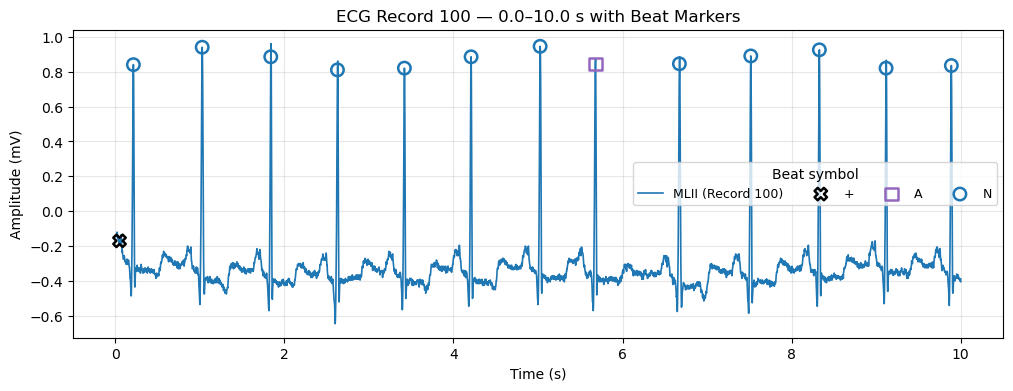

In [4]:
import gzip, pandas as pd, numpy as np
import matplotlib.pyplot as plt

# === Select record and channel ===
RECORD_ID = "100"      # I am using record 100 because it is the reference and cleanest record in MIT-BIH.
CHANNEL   = "MLII"     # I chose MLII because it is the main ECG lead with clear R-peaks.

# --- Color + marker dictionaries ---
# I define colors and marker shapes to visualize different beat types.
# This will make each type of heartbeat (normal, atrial, ventricular, etc.) easy to identify.
COLOR = {
    "N": "#1f77b4",  # blue = normal beat
    "A": "#9467bd",  # purple = atrial premature beat
    "V": "#17becf",  # cyan = ventricular premature beat
    "L": "#ff7f0e",  # orange = left bundle branch block
    "R": "#2ca02c",  # green = right bundle branch block
    "+": "#000000",  # black = rhythm change (not a beat label)
}
MARKER = {
    "N": "o",   # circle marker
    "A": "s",   # square marker
    "V": "D",   # diamond marker
    "L": "^",   # triangle up
    "R": "v",   # triangle down
    "+": "X",   # X marker for rhythm changes
}

# --- File path ---
# I read the CSV file for the chosen record from my local Colab folder.
path = f"./mitdb_csv/{RECORD_ID}.csv.gz"

# --- Load file safely ---
# I open the compressed file and read it using pandas.
# low_memory=False prevents data type warnings for large files.
with gzip.open(path, "rt") as f:
    df = pd.read_csv(f, low_memory=False)

print(f"Loaded record {RECORD_ID} with columns: {list(df.columns)}")

# --- Ensure channel exists ---
# Before plotting, I check that the selected channel  actually exists in the data.
# This avoids runtime errors if the record doesn’t contain that lead.
if CHANNEL not in df.columns:
    raise ValueError(f"Channel '{CHANNEL}' not found in {RECORD_ID}. Available: {list(df.columns)}")

# --- Find annotation region ---
# I locate all annotated beats (rows that have a label in 'ann_symbol').
# Then I convert symbols to string type to ensure consistency when plotting.
beats = df.dropna(subset=["ann_symbol"]).copy()
beats["ann_symbol"] = beats["ann_symbol"].astype(str)

# If there are no annotations, I raise an error because the plot would be empty.
if beats.empty:
    raise ValueError("No annotations found in this record.")

# I pick the time of the first annotation to center my visualization window.
center = beats["time_sec"].iloc[0]
tmin, tmax = df["time_sec"].min(), df["time_sec"].max()

# This function finds a time window (10–30 seconds) around the annotation.
# It makes sure that the chosen segment includes labeled beats for visualization.
def find_window(center, base_len=10, max_len=30):
    for L in (base_len, 15, 20, max_len):
        s = max(tmin, center - L/2)
        e = min(tmax, s + L)
        w = (df["time_sec"] >= s) & (df["time_sec"] <= e)
        ann = df.loc[w].dropna(subset=["ann_symbol"])
        if not ann.empty:
            return s, e
    return tmin, min(tmax, tmin + base_len)

# Here I use the function to find the best window that contains annotations.
start, end = find_window(center, base_len=10, max_len=30)

# I select the signal within the found window.
win = (df["time_sec"] >= start) & (df["time_sec"] <= end)
dw = df.loc[win].copy()

# I again extract only the annotated beats from this window.
ann = dw.dropna(subset=["ann_symbol"]).copy()
ann["ann_symbol"] = ann["ann_symbol"].astype(str)

# --- Plot ECG + annotated beats ---
# I plot the ECG waveform for the selected time window.
plt.figure(figsize=(12, 4))
plt.plot(dw["time_sec"], dw[CHANNEL], linewidth=1.2, label=f"{CHANNEL} (Record {RECORD_ID})")

# For each annotation type, I plot colored markers on top of the ECG.
# This helps me see if the labels (like N, A, V) are correctly placed at R-peaks.
for sym, grp in ann.groupby("ann_symbol"):
    x = grp["time_sec"].values
    y = grp[CHANNEL].values
    color = COLOR.get(sym, "#333333")
    marker = MARKER.get(sym, "o")
    plt.scatter(
        x, y,
        s=80,
        marker=marker,
        facecolors="none",
        edgecolors=color,
        linewidths=1.8,
        zorder=5,
        label=f"{sym}"
    )

# I add title and axis labels for clarity.
plt.title(f"ECG Record {RECORD_ID} — {start:.1f}–{end:.1f} s with Beat Markers")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

# The legend shows the meaning of each beat symbol (N, A, V, etc.).
if not ann.empty:
    plt.legend(title="Beat symbol", ncol=8, fontsize=9)

# Add a light grid to make it easier to read time and amplitude.
plt.grid(True, alpha=0.3)

# Finally, I display the ECG plot with all annotations marked.
plt.show()


By plotting record 100 using the MLII channel, I can clearly see that the beat annotations are synchronized with the ECG signal.  
The plot shows clear R-peaks marked with symbols such as “N” for normal beats and “A” for atrial premature beats, while the “+” symbol indicates rhythm changes rather than actual heartbeats.  
Record 100 was selected because it is clean and commonly used as a reference in ECG research.  
Using different colors and marker shapes makes it easier to distinguish between beat types.  
Since the signal and annotations are correctly aligned for this sample record, the next step is to perform a full exploratory data analysis on all ECG records to study data quality and class distribution.


##  Step 5: Full Exploratory Data Analysis (EDA)

In this step, I perform a full exploratory data analysis on all ECG records from the MIT-BIH Arrhythmia Database.  
The goal is to check the overall data quality, confirm that all records were exported correctly, and verify that the heartbeat annotations are consistent across different files.  
This analysis also helps identify possible class imbalance between normal and abnormal beats, which is important before training classification models.


Found 48 records.

Analyzing record 100 ...

Analyzing record 101 ...

Analyzing record 102 ...

Analyzing record 103 ...

Analyzing record 104 ...

Analyzing record 105 ...

Analyzing record 106 ...

Analyzing record 107 ...

Analyzing record 108 ...

Analyzing record 109 ...

Analyzing record 111 ...

Analyzing record 112 ...

Analyzing record 113 ...

Analyzing record 114 ...

Analyzing record 115 ...

Analyzing record 116 ...

Analyzing record 117 ...

Analyzing record 118 ...

Analyzing record 119 ...

Analyzing record 121 ...

Analyzing record 122 ...

Analyzing record 123 ...

Analyzing record 124 ...

Analyzing record 200 ...

Analyzing record 201 ...

Analyzing record 202 ...

Analyzing record 203 ...

Analyzing record 205 ...

Analyzing record 207 ...

Analyzing record 208 ...

Analyzing record 209 ...

Analyzing record 210 ...

Analyzing record 212 ...

Analyzing record 213 ...

Analyzing record 214 ...

Analyzing record 215 ...

Analyzing record 217 ...

Analyzing record 21

,record_id,rows,channels,duplicates,missing_ann_symbol,annotations_total,dtypes
0,100,650000,"time_sec, MLII, V5",0,647726,2274,"{'record': dtype('int64'), 'sample': dtype('in..."
1,101,650000,"time_sec, MLII, V1",0,648126,1874,"{'record': dtype('int64'), 'sample': dtype('in..."
2,102,650000,"time_sec, V5, V2",0,647808,2192,"{'record': dtype('int64'), 'sample': dtype('in..."
3,103,650000,"time_sec, MLII, V2",0,647909,2091,"{'record': dtype('int64'), 'sample': dtype('in..."
4,104,650000,"time_sec, V5, V2",0,647689,2311,"{'record': dtype('int64'), 'sample': dtype('in..."



=== GLOBAL MISSING VALUES ===
record: 0
sample: 0
time_sec: 0
MLII: 0
V5: 0
ann_symbol: 31,087,353
ann_desc: 31,198,272
V1: 0
V2: 0
V4: 0

=== GLOBAL ANNOTATION COUNTS ===
N: 75,052
L: 8,075
R: 7,259
V: 7,130
/: 7,028
A: 2,546
+: 1,291
f: 982
F: 803
~: 616
!: 472
": 437
j: 229
x: 193
a: 150
|: 132
E: 106
J: 83
Q: 33
e: 16
[: 6
]: 6
S: 2


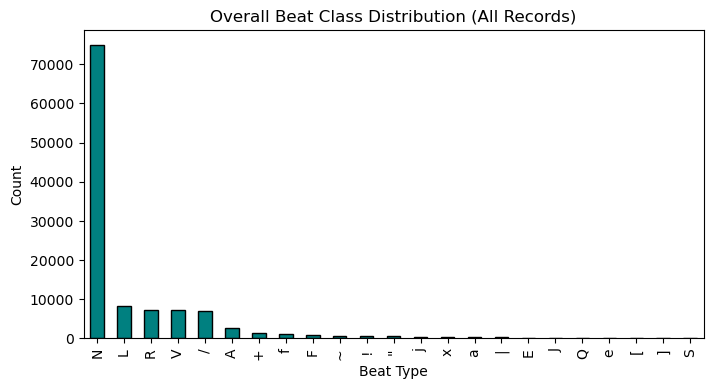

In [5]:
import os, gzip
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# Folder that contains all the exported ECG CSV files
BASE_DIR = "./mitdb_csv"

# I will save all the record summaries in this list
eda_summary = []

# Get all compressed CSV files from the folder
files = sorted([f for f in os.listdir(BASE_DIR) if f.endswith(".csv.gz")])
print(f"Found {len(files)} records.")

# Loop through each record file one by one
for file in files:
    record_id = file.replace(".csv.gz", "")
    print(f"\nAnalyzing record {record_id} ...")

    # --- Load the data file ---
    # I use gzip to open the compressed CSV and read it with pandas.
    # Setting dtype for annotation columns to string prevents warnings.
    with gzip.open(os.path.join(BASE_DIR, file), "rt") as f:
        df = pd.read_csv(f, dtype={"ann_symbol": "str", "ann_desc": "str"}, low_memory=False)

    # --- Basic info about this record ---
    # I check how many rows and columns it has, and what data types are used.
    total_rows, total_cols = df.shape
    dtypes = df.dtypes.to_dict()

    # --- Check for missing values ---
    # Missing annotations are expected because not every sample is labeled.
    missing = df.isna().sum().to_dict()
    missing_percent = {k: (v/total_rows)*100 for k, v in missing.items()}

    # --- Check for duplicate rows ---
    # ECG signals should not have duplicates, so this confirms data integrity.
    duplicates = df.duplicated().sum()

    # --- Summary statistics for numerical columns ---
    # I calculate mean, std, min, max, skew, and kurtosis for each ECG lead.
    num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["record", "sample"]]
    desc = {}
    for col in num_cols:
        data = df[col].dropna()
        desc[col] = {
            "mean": np.mean(data),
            "std": np.std(data),
            "min": np.min(data),
            "max": np.max(data),
            "skew": skew(data),
            "kurtosis": kurtosis(data)
        }

    # --- Annotation summary ---
    # Here I count how many beats of each type exist in this record.
    ann_counts = df["ann_symbol"].dropna().value_counts().to_dict()
    ann_total = sum(ann_counts.values())

    # --- Correlation between ECG leads ---
    # Some records have two channels (like MLII and V5), so I check how similar they are.
    lead_cols = [c for c in df.columns if c not in ["record","sample","time_sec","ann_symbol","ann_desc"]]
    corr = None
    if len(lead_cols) >= 2:
        corr = df[lead_cols].corr().to_dict()

    # --- Save summary info for this record ---
    eda_summary.append({
        "record_id": record_id,
        "rows": total_rows,
        "columns": total_cols,
        "duplicates": duplicates,
        "missing_counts": missing,
        "missing_percent": missing_percent,
        "numeric_summary": desc,
        "annotation_counts": ann_counts,
        "annotation_total": ann_total,
        "lead_correlation": corr,
        "dtypes": dtypes
    })

print("\nEDA completed for all records.")

# --- Make a simple DataFrame summary ---
# I collect only the main info (rows, channels, missing annotations, etc.) for quick viewing.
summary_rows = []
for rec in eda_summary:
    rec_id = rec["record_id"]
    missing_ann = rec["missing_counts"].get("ann_symbol", 0)
    ann_total = rec["annotation_total"]
    channels = [c for c in rec["numeric_summary"].keys()]
    summary_rows.append({
        "record_id": rec_id,
        "rows": rec["rows"],
        "channels": ", ".join(channels),
        "duplicates": rec["duplicates"],
        "missing_ann_symbol": missing_ann,
        "annotations_total": ann_total,
        "dtypes": str(rec["dtypes"]),
    })
summary_df = pd.DataFrame(summary_rows)

# --- Save the summary for Excel review ---
# I export the summary to CSV so I can open it later in Excel or share it.
out_path = "./mitdb_full_eda_summary.csv"
summary_df.to_csv(out_path, index=False)
print(f"\nSummary saved to {out_path}")
display(summary_df.head())

# --- Combine all missing and annotation stats (global overview) ---
# Here I merge all per-record results to understand the dataset as a whole.
all_missing = {}
for rec in eda_summary:
    for k,v in rec["missing_counts"].items():
        all_missing[k] = all_missing.get(k,0) + v

all_anns = {}
for rec in eda_summary:
    for k,v in rec["annotation_counts"].items():
        all_anns[k] = all_anns.get(k,0) + v

# --- Print total missing values across all records ---
print("\n=== GLOBAL MISSING VALUES ===")
for k,v in all_missing.items():
    print(f"{k}: {v:,}")

# --- Print total annotation counts across all records ---
print("\n=== GLOBAL ANNOTATION COUNTS ===")
for k,v in sorted(all_anns.items(), key=lambda x:-x[1]):
    print(f"{k}: {v:,}")

# --- Plot overall annotation distribution ---
# I create a bar chart to see the balance between beat types.
# This helps to notice that normal beats (N) are much more common than others.
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
pd.Series(all_anns).sort_values(ascending=False).plot(kind='bar', color='teal', edgecolor='black')
plt.title("Overall Beat Class Distribution (All Records)")
plt.xlabel("Beat Type")
plt.ylabel("Count")
plt.show()


After completing the exploratory data analysis, all ECG records were successfully loaded and analyzed.  
Each record contains 650,000 samples from one or two ECG channels, and no duplicate rows or missing signal values were found, which confirms good data integrity.  
Missing values appeared only in the annotation columns, which is expected because heartbeat labels exist only at specific sample locations.  

The overall annotation distribution shows a strong class imbalance, where normal beats (“N”) are much more frequent than abnormal beat types such as “L”, “R”, and “V”.  
This confirms that the dataset is clean and consistent, but class imbalance must be considered in later modeling steps.  
In the next step, I will examine the global signal quality in more detail and visually inspect representative ECG records to further validate signal cleanliness and annotation alignment.


##  Step 6: Global Signal Quality and Visual Inspection

In this step, I examine the overall quality of the ECG signals in the MIT-BIH Arrhythmia Database.  
I analyze missing values, compute global statistical measures such as skewness and kurtosis, and generate visual plots for representative records.  
This step helps confirm that the ECG signals are clean, have realistic shapes, and that the beat annotations are correctly aligned with the R-peaks.


Found 48 records.
Missingness summary saved: ./mitdb_eda_outputs\mitdb_missing_summary.csv

GLOBAL MISSING COUNTS (all records combined):
  record: 0
  sample: 0
  time_sec: 0
  MLII: 0
  V5: 0
  ann_symbol: 31,087,353
  ann_desc: 31,198,272
  V1: 0
  V2: 0
  V4: 0
Global signal stats saved: ./mitdb_eda_outputs\mitdb_global_signal_stats.csv

GLOBAL AGGREGATES (across all channels & records):
  mean_mean: -0.2267
  mean_std: 0.3354
  mean_min: -2.6158
  mean_max: 2.2773
  mean_skew: 0.6042
  mean_kurtosis: 11.2852

Visuals for record 100 — channels: ['MLII', 'V5']


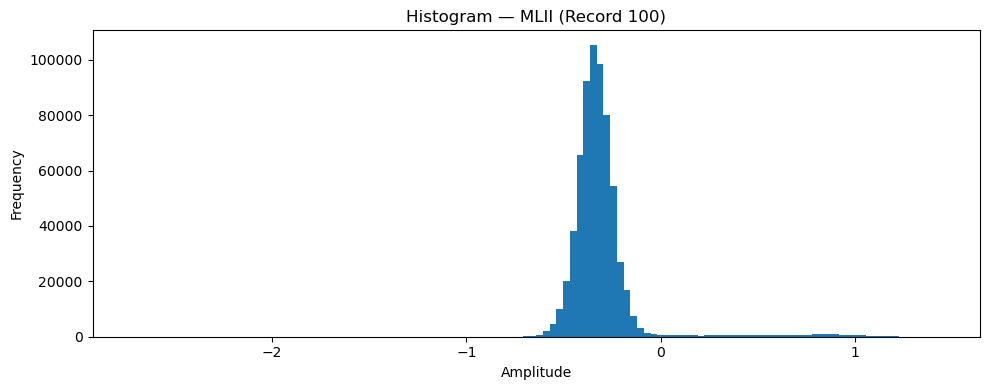

   saved: ./mitdb_eda_outputs\hist_100_MLII.png


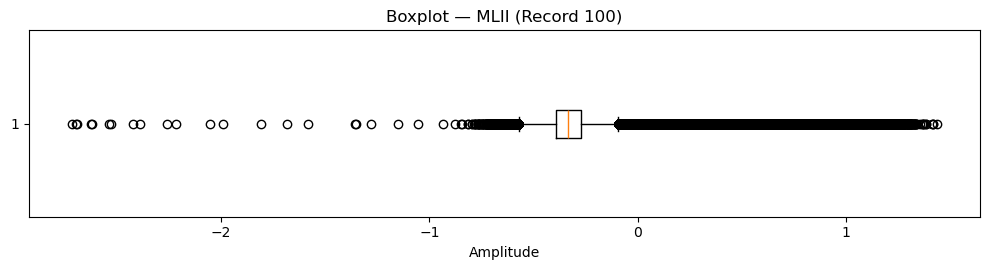

   saved: ./mitdb_eda_outputs\box_100_MLII.png


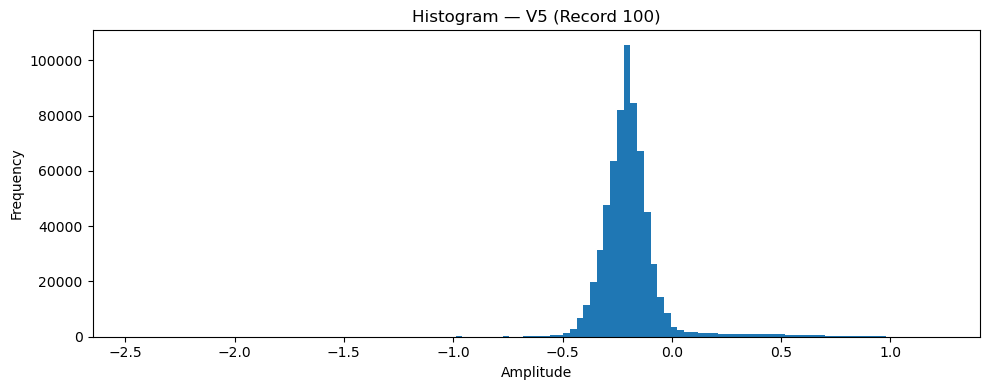

   saved: ./mitdb_eda_outputs\hist_100_V5.png


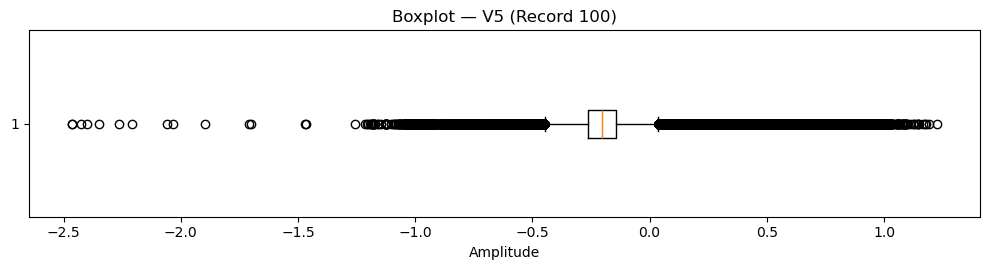

   saved: ./mitdb_eda_outputs\box_100_V5.png

ECG window plot for record 100, channel MLII, 0-10s


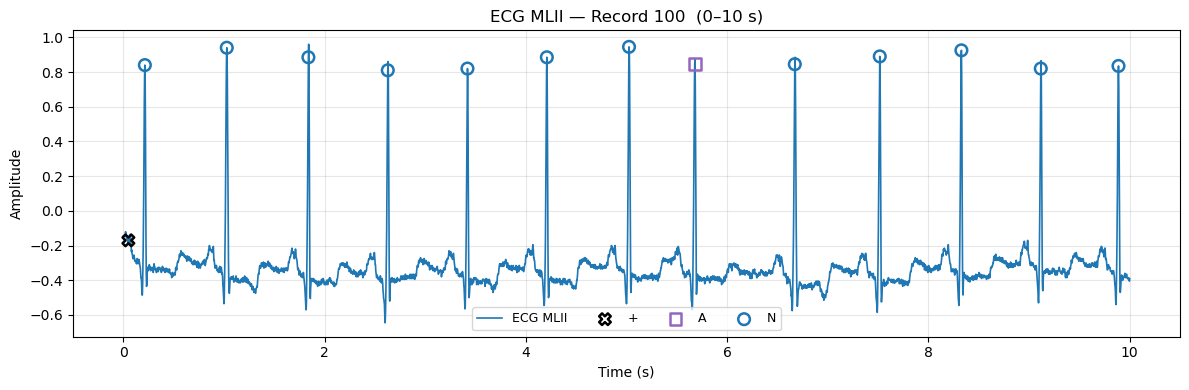

   saved: ./mitdb_eda_outputs\ecg_100_MLII_0-10.png

ECG window plot for record 104, channel V5, 0-10s


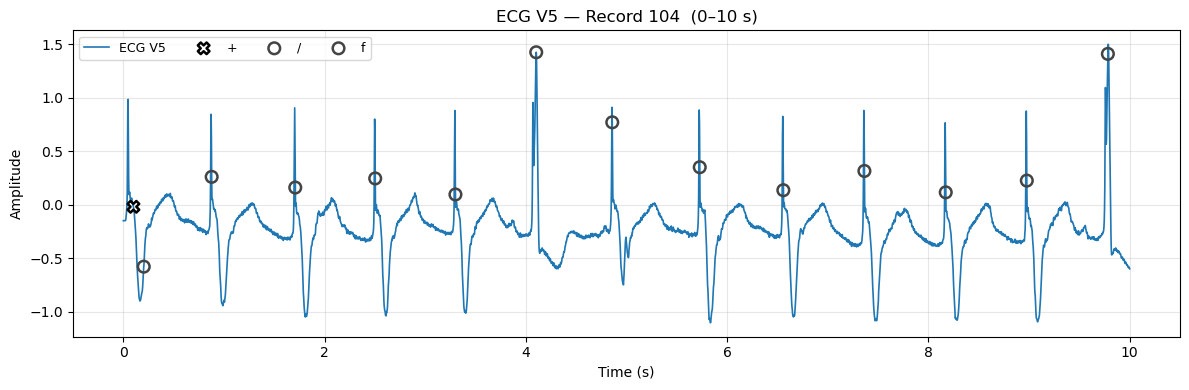

   saved: ./mitdb_eda_outputs\ecg_104_V5_0-10.png

Outputs saved in: ./mitdb_eda_outputs


In [6]:
# === MIT-BIH EDA: Missingness (all), Global Skew/Kurtosis (all), and Visuals (representative) ===
import os, gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# ---------------- Settings ----------------
BASE_DIR = "./mitdb_csv"           # path to the folder that contains all the .csv.gz ECG records
REP_RECORDS = ["100", "104"]       # I will use these two records as examples for visual inspection
CHANNEL_PRIORITY = ["MLII", "V5", "V2", "V1", "V4"]  # these are the ECG channels I prefer to check first
HIST_BINS = 120                    # number of bins for histograms (controls how smooth the plot looks)
WAVE_WINDOW_SEC = (0, 10)          # the first 10 seconds of ECG will be used for quick visual inspection
SAVE_DIR = "./mitdb_eda_outputs"   # folder where all outputs (CSVs and images) will be saved
os.makedirs(SAVE_DIR, exist_ok=True)  # create the output folder if it does not exist
# ------------------------------------------

# This function lists all .csv.gz files in the dataset folder
def list_record_files(base_dir):
    return sorted([f for f in os.listdir(base_dir) if f.endswith(".csv.gz")])

# This function loads a compressed ECG file and returns it as a pandas DataFrame
def load_df(path):
    with gzip.open(path, "rt") as f:
        return pd.read_csv(f, dtype={"ann_symbol":"str","ann_desc":"str"}, low_memory=False)

# This function helps pick the primary ECG channel to analyze (like MLII or V5)
def pick_primary_channel(columns):
    for c in CHANNEL_PRIORITY:
        if c in columns:
            return c
    # If preferred channels not found, just pick the first numeric one
    for c in columns:
        if c not in ["record","sample","time_sec","ann_symbol","ann_desc"]:
            return c
    return None

# --------------- 1) Missingness (ALL records) ---------------
# Here I check every record to see if there are missing values in any column.
# I expect no missing values in ECG signals, only in annotations (which is normal).
files = list_record_files(BASE_DIR)
print(f"Found {len(files)} records.")
missing_rows = []
global_missing = {}

for file in files:
    rec_id = file.replace(".csv.gz", "")
    df = load_df(os.path.join(BASE_DIR, file))
    total_rows = len(df)

    # Count missing values per column
    miss = df.isna().sum().to_dict()
    miss_pct = {k: (v/total_rows)*100 for k,v in miss.items()}

    # Add these results to the global missing value summary
    for k, v in miss.items():
        global_missing[k] = global_missing.get(k, 0) + int(v)

    # Save missing count and percentage for each record
    missing_rows.append({
        "record_id": rec_id,
        "rows": total_rows,
        **{f"miss_{k}": v for k,v in miss.items()},
        **{f"misspct_{k}": round(p,4) for k,p in miss_pct.items()},
    })

# Save the missingness summary as CSV for easy checking later
missing_df = pd.DataFrame(missing_rows).sort_values("record_id")
missing_csv = os.path.join(SAVE_DIR, "mitdb_missing_summary.csv")
missing_df.to_csv(missing_csv, index=False)
print(f"Missingness summary saved: {missing_csv}")

# Print total missing values across all records
print("\nGLOBAL MISSING COUNTS (all records combined):")
for k,v in global_missing.items():
    print(f"  {k}: {v:,}")

# --------------- 2) Global skewness & kurtosis ---------------
# In this part, I calculate basic statistical measures for each signal channel:
# mean, std, min, max, skewness, and kurtosis.
# Skewness shows symmetry (ECG should have small positive skew).
# Kurtosis shows how peaked the distribution is (ECG has very high kurtosis because of sharp R-peaks).

stats_rows = []
for file in files:
    rec_id = file.replace(".csv.gz", "")
    df = load_df(os.path.join(BASE_DIR, file))

    # find numeric ECG columns
    channels = [c for c in df.columns if c not in ["record","sample","time_sec","ann_symbol","ann_desc"]]
    primary = pick_primary_channel(df.columns)

    # compute the statistical values
    for ch in channels:
        x = pd.to_numeric(df[ch], errors="coerce").dropna().values
        if x.size == 0:
            continue
        stats_rows.append({
            "record_id": rec_id,
            "channel": ch,
            "is_primary": (ch == primary),
            "mean": float(np.mean(x)),
            "std": float(np.std(x)),
            "min": float(np.min(x)),
            "max": float(np.max(x)),
            "skew": float(skew(x)),
            "kurtosis": float(kurtosis(x)),
        })

# Save all the stats into one CSV
stats_df = pd.DataFrame(stats_rows)
stats_csv = os.path.join(SAVE_DIR, "mitdb_global_signal_stats.csv")
stats_df.to_csv(stats_csv, index=False)
print(f"Global signal stats saved: {stats_csv}")

# Print out the average of all computed values to see the general signal shape
if not stats_df.empty:
    agg = {
        "mean_mean": stats_df["mean"].mean(),
        "mean_std": stats_df["std"].mean(),
        "mean_min": stats_df["min"].mean(),
        "mean_max": stats_df["max"].mean(),
        "mean_skew": stats_df["skew"].mean(),
        "mean_kurtosis": stats_df["kurtosis"].mean(),
    }
    print("\nGLOBAL AGGREGATES (across all channels & records):")
    for k,v in agg.items():
        print(f"  {k}: {v:.4f}")

# --------------- 3) Visuals for ONE representative record (hist + box for each channel) ---------------
# Now I make histogram and boxplot for one clean record (100).
# These visuals help me see the shape of the data and detect if there are extreme values or noise.
def plot_hist_and_box(df, rec_id, channel):
    x = pd.to_numeric(df[channel], errors="coerce").dropna().values
    if x.size == 0:
        return
    # Histogram (shows overall data distribution)
    plt.figure(figsize=(10,4))
    plt.hist(x, bins=HIST_BINS)
    plt.title(f"Histogram — {channel} (Record {rec_id})")
    plt.xlabel("Amplitude")
    plt.ylabel("Frequency")
    out = os.path.join(SAVE_DIR, f"hist_{rec_id}_{channel}.png")
    plt.tight_layout(); plt.savefig(out, dpi=150); plt.show()
    print(f"   saved: {out}")

    # Boxplot (shows outliers and signal spread)
    plt.figure(figsize=(10,2.8))
    plt.boxplot(x, vert=False)
    plt.title(f"Boxplot — {channel} (Record {rec_id})")
    plt.xlabel("Amplitude")
    out = os.path.join(SAVE_DIR, f"box_{rec_id}_{channel}.png")
    plt.tight_layout(); plt.savefig(out, dpi=150); plt.show()
    print(f"   saved: {out}")

# --------------- 4) ECG shape with annotations for ONE or TWO records ---------------
# Finally, I plot the real ECG waveform with its annotation markers (like N, A, etc.)
# This is the most important visual check to confirm that annotations match R-peaks correctly.
COLOR = {"N":"#1f77b4","A":"#9467bd","V":"#17becf","+":"#000000","L":"#ff7f0e","R":"#2ca02c"}
MARKER = {"N":"o","A":"s","V":"D","+":"X","L":"^","R":"v"}

def plot_ecg_window(df, rec_id, channel, t_start, t_end):
    # select the time range I want to plot
    m = (df["time_sec"] >= t_start) & (df["time_sec"] <= t_end)
    dw = df.loc[m].copy()
    if dw.empty or channel not in dw.columns:
        print(f"   Skipped {rec_id}: empty window or missing channel {channel}")
        return

    # take only annotated beats (where ann_symbol is not null)
    ann = dw.dropna(subset=["ann_symbol"]).copy()
    ann["ann_symbol"] = ann["ann_symbol"].astype(str)

    # plot ECG and overlay the annotations on top of R-peaks
    plt.figure(figsize=(12,4))
    plt.plot(dw["time_sec"], dw[channel], linewidth=1.2, label=f"ECG {channel}")
    for sym, grp in ann.groupby("ann_symbol"):
        x = grp["time_sec"].values
        y = grp[channel].values
        plt.scatter(
            x, y,
            s=70,
            marker=MARKER.get(sym,"o"),
            edgecolors=COLOR.get(sym,"#444444"),
            facecolors="none",
            linewidths=1.8,
            zorder=5,
            label=sym
        )
    plt.title(f"ECG {channel} — Record {rec_id}  ({t_start}–{t_end} s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    if not ann.empty:
        plt.legend(ncol=6, fontsize=9)
    plt.grid(True, alpha=0.3)
    out = os.path.join(SAVE_DIR, f"ecg_{rec_id}_{channel}_{t_start}-{t_end}.png")
    plt.tight_layout(); plt.savefig(out, dpi=150); plt.show()
    print(f"   saved: {out}")

# ---- Run visuals on representative record(s) ----
# First, I plot histograms and boxplots for record 100 (clean signal example)
for rec in REP_RECORDS[:1]:  # only use the first record for this part
    path = os.path.join(BASE_DIR, f"{rec}.csv.gz")
    if not os.path.exists(path):
        print(f"Record {rec} not found, skipping visuals.")
        continue
    df_rep = load_df(path)
    channels = [c for c in df_rep.columns if c not in ["record","sample","time_sec","ann_symbol","ann_desc"]]
    print(f"\nVisuals for record {rec} — channels: {channels}")
    for ch in channels:
        plot_hist_and_box(df_rep, rec, ch)

# Now I plot a short ECG window (0–10 seconds) for both record 100 and 104 to check annotation alignment
t0, t1 = WAVE_WINDOW_SEC
for rec in REP_RECORDS:
    path = os.path.join(BASE_DIR, f"{rec}.csv.gz")
    if not os.path.exists(path):
        continue
    df_r = load_df(path)
    ch_primary = pick_primary_channel(df_r.columns)
    if ch_primary is None:
        print(f"No ECG channel found in record {rec}")
        continue
    print(f"\nECG window plot for record {rec}, channel {ch_primary}, {t0}-{t1}s")
    plot_ecg_window(df_r, rec, ch_primary, t0, t1)

print(f"\nOutputs saved in: {SAVE_DIR}")


This step extends the previous data quality analysis with more detailed statistical and visual checks.  
The results show that all ECG signals are complete, and missing values appear only in the annotation columns, which is expected because not every sample is labeled.  
The global statistics indicate realistic ECG behavior, where the average skewness is slightly positive and the high kurtosis reflects the presence of sharp R-peaks.  

The histograms and boxplots confirm that signal amplitudes are within reasonable ranges, and the ECG plots for records 100 and 104 show that annotations are well aligned with the R-peaks.  
Overall, these results confirm that the dataset is clean, synchronized, and suitable for further analysis.  
In the next step, I will compute detailed statistical summaries for a single ECG record to further validate signal quality before moving to heartbeat class mapping.


##  Step 7: ECG Channel Statistical Summary (Record 100)

In this step, I compute detailed statistical measures for a single ECG record to confirm signal quality using numerical analysis.  
I use record 100 because it is clean and has already been verified visually in the previous steps.  
By calculating statistics such as the mean, standard deviation, quartiles, skewness, and kurtosis for each ECG channel, I can check whether the signal values are realistic and well scaled.


In [7]:
import numpy as np
from scipy.stats import skew, kurtosis

import os, gzip, pandas as pd
rec_id = "100"  # I use record 100 as a sample record
path = f"./mitdb_csv/{rec_id}.csv.gz"

# Open the ECG file and load it into a DataFrame
with gzip.open(path, "rt") as f:
    df = pd.read_csv(f, dtype={"ann_symbol": "str", "ann_desc": "str"}, low_memory=False)

# Select only the ECG channels and ignore extra columns
channels = [c for c in df.columns if c not in ["record","sample","time_sec","ann_symbol","ann_desc"]]

summary_rows = []  # I will store all the statistics here

# Loop through each ECG channel and calculate its statistics
for ch in channels:
    data = df[ch].dropna()  # remove missing values
    stats = {
        "channel": ch,
        "count": len(data),          # total number of samples
        "mean": data.mean(),         # average value of the signal
        "std": data.std(),           # how much the values change
        "min": data.min(),           # smallest value
        "Q1": data.quantile(0.25),   # first quartile (25%)
        "median": data.median(),     # middle value (50%)
        "Q3": data.quantile(0.75),   # third quartile (75%)
        "max": data.max(),           # largest value
        "skewness": skew(data),      # show if data is more on one side
        "kurtosis": kurtosis(data),  # show how sharp or flat the peaks are
    }
    summary_rows.append(stats)  # save this channel’s results

# Put all results in one table for easy reading
summary_df = pd.DataFrame(summary_rows)
pd.set_option("display.precision", 4)
display(summary_df)  # show the summary table

# Save the results in a CSV file so I can check later
os.makedirs("./mitdb_eda_outputs", exist_ok=True)
summary_df.to_csv(f"./mitdb_eda_outputs/distribution_summary_{rec_id}.csv", index=False)
print(f"\nSaved summary for record {rec_id}: ./mitdb_eda_outputs/distribution_summary_{rec_id}.csv")
# Quick quality flag
summary_df["is_suspicious"] = (summary_df["std"] < 0.05) | (summary_df["kurtosis"] < 2)
display(summary_df[summary_df["is_suspicious"]])

,channel,count,mean,std,min,Q1,median,Q3,max,skewness,kurtosis
0,MLII,650000,-0.3063,0.1932,-2.715,-0.390,-0.335,-0.270,1.435,4.4261,25.4131
1,V5,650000,-0.1910,0.1482,-2.465,-0.265,-0.205,-0.145,1.225,2.7102,16.1646



Saved summary for record 100: ./mitdb_eda_outputs/distribution_summary_100.csv


,channel,count,mean,std,min,Q1,median,Q3,max,skewness,kurtosis,is_suspicious


The statistical results confirm the same conclusions obtained from the visual inspection.  
Both ECG channels (MLII and V5) show stable distributions with reasonable standard deviation values and baselines close to zero, which indicates clean and steady signals.  
The slightly negative mean values are normal for ECG data and do not suggest any scaling or offset problems.  

The amplitude ranges are realistic, while the positive skewness reflects the presence of tall R-peaks.  
The high kurtosis values confirm that most signal samples are close to zero, with only a small number of large peaks corresponding to heartbeats.  
Overall, these numerical results show that record 100 is well scaled, noise-free, and suitable for further processing.  
In the next step, I will analyze the raw frequency content of the ECG signals to decide whether filtering is required.


---

## 🔹 Transition from EDA to Cleaning 🔹

All exploratory data analysis (EDA) steps are now completed.  
We have assessed the dataset’s quality, annotation consistency, signal statistics, and visual inspections.  

---

### Next Phase: Data Cleaning and Preprocessing

This section focuses on correcting issues in the raw ECG signals, such as baseline drift, high-frequency noise, and powerline interference, to prepare the data for accurate feature extraction and modeling.

---


##  Step 8: Raw-Only Spectral Pre-Check (FFT)

Before applying any filtering to the ECG signals, I analyze their raw frequency content using a spectral pre-check.  
This step helps me understand how much signal energy lies within the main ECG frequency range (0.5–40 Hz), and how much is affected by low-frequency baseline drift, high-frequency noise, or possible powerline interference.  
Based on this analysis, I can decide whether band-pass or notch filtering is needed for proper signal cleaning.


In [32]:
# === RAW-ONLY spectral pre-check for MIT-BIH ===

import os, gzip, numpy as np, pandas as pd

# -------- Here I try to find the folder that has the raw ECG files (.csv.gz) --------
# I check both Google Drive and the local working directory.
drive_dir = "./drive/MyDrive"
local_dir = "."
RAW_DIR_CANDIDATES = [
    os.path.join(drive_dir, "mitdb_csv"),
    os.path.join(local_dir, "mitdb_csv"),
]

def find_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

RAW_DIR = find_existing(RAW_DIR_CANDIDATES)
if RAW_DIR is None:
    raise FileNotFoundError("Could not find 'mitdb_csv' folder. Mount Drive or adjust path.")

print(f"RAW_DIR = {RAW_DIR}")

OUT_CSV = "./mitdb_fft_precheck.csv"

# -------- Settings section --------
# Here I define the important frequency ranges and thresholds.
ECG_BAND  = (0.5, 40.0)   # The diagnostic ECG frequency range (main useful band).
LF_CUTOFF = 0.5           # Below this is baseline drift / low-frequency movement.
HF_CUTOFF = 40.0          # Above this is high-frequency noise.

# Powerline frequency (MIT-BIH is from the USA, so I check around 60 Hz)
PL_FREQ   = 60.0          # Powerline frequency in the USA.
PL_TOL_HZ = 1.0           # I measure power within ±1 Hz around 60 Hz.

# Decision thresholds for marking signals that may need filtering
TH_SPR_MIN   = 0.85       # Ideally, a large portion of power should be in 0.5–40 Hz
TH_LFR_MAX   = 0.02       # I allow <2% of power below 0.5 Hz
TH_HF_MAX    = 0.05       # I allow <5% of power above 40 Hz
TH_PNI60_MAX = 0.005      # I allow <0.5% of power around 60 Hz

# These are metadata columns I will ignore when reading ECG data
META = {"record", "sample", "time_sec", "ann_symbol", "ann_desc"}

# This function lists all compressed CSV files in the folder
def list_csv_gz(folder):
    return sorted([f for f in os.listdir(folder) if f.endswith(".csv.gz")])

# This function loads a compressed ECG file into a pandas DataFrame
def load_df(path):
    with gzip.open(path, "rt") as f:
        return pd.read_csv(f, dtype={"ann_symbol": "str", "ann_desc": "str"}, low_memory=False)

# This function estimates the sampling frequency (fs) from the time column
def estimate_fs(time_sec):
    dt = np.diff(time_sec.values if isinstance(time_sec, pd.Series) else time_sec)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(round(1.0 / np.median(dt))) if dt.size else None

# This function calculates the ratio of signal power in a frequency band
def power_spectrum_ratio(x, fs, band_lo=None, band_hi=None):
    """Return ratio of power in [band_lo, band_hi] to total power."""
    x = np.asarray(x)
    n = len(x)
    if n < 2048:  # I skip very short signals
        return np.nan
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    spec = np.abs(np.fft.rfft(x)) ** 2
    total = spec.sum()
    if total <= 0:
        return np.nan

    mask = np.ones_like(freqs, dtype=bool)
    if band_lo is not None:
        mask &= (freqs >= band_lo)
    if band_hi is not None:
        mask &= (freqs <= band_hi)

    return float(spec[mask].sum() / total)

# This function checks the power ratio around a specific frequency (like 60 Hz)
def power_in_band_ratio(x, fs, f0, tol):
    """Power in [f0 - tol, f0 + tol] / total power."""
    x = np.asarray(x)
    n = len(x)
    if n < 2048:
        return np.nan
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    spec = np.abs(np.fft.rfft(x)) ** 2
    total = spec.sum()
    if total <= 0:
        return np.nan

    mask = (freqs >= (f0 - tol)) & (freqs <= (f0 + tol))
    return float(spec[mask].sum() / total)

# This function returns the ECG signal columns (excluding metadata)
def ecg_channels(df):
    return [c for c in df.columns if c not in META]

# ---- Main loop ----
# Here I go through every record and channel to calculate the spectral metrics
rows = []
for file in list_csv_gz(RAW_DIR):
    rec_id = file.replace(".csv.gz", "")
    try:
        df = load_df(os.path.join(RAW_DIR, file))
    except Exception as e:
        print(f"skip {file}: {e}")
        continue

    if "time_sec" not in df.columns:
        print(f"skip {rec_id}: missing time_sec")
        continue

    fs = estimate_fs(df["time_sec"])
    if not fs or fs <= 0:
        print(f"skip {rec_id}: bad fs")
        continue

    channels = ecg_channels(df)
    for ch in channels:
        x = pd.to_numeric(df[ch], errors="coerce").dropna().values
        # I can limit the signal length here if it’s too long to process
        # x = x[:min(len(x), 500000)]

        # Calculate power ratios for different frequency ranges
        SPR  = power_spectrum_ratio(x, fs, ECG_BAND[0], ECG_BAND[1])   # 0.5–40 Hz
        LFR  = power_spectrum_ratio(x, fs, None, LF_CUTOFF)            # <0.5 Hz
        HF   = power_spectrum_ratio(x, fs, HF_CUTOFF, None)            # >40 Hz
        PNI60 = power_in_band_ratio(x, fs, PL_FREQ, PL_TOL_HZ)         # ~60 Hz

        # Decide if I need band-pass or notch filtering later
        need_bandpass = ((not np.isnan(SPR) and SPR < TH_SPR_MIN) or
                         (not np.isnan(LFR) and LFR > TH_LFR_MAX) or
                         (not np.isnan(HF)  and HF  > TH_HF_MAX))

        need_notch_60 = (not np.isnan(PNI60) and PNI60 > TH_PNI60_MAX)

        # Save the results for this record and channel
        rows.append({
            "record_id": rec_id,
            "channel": ch,
            "fs": fs,
            "SPR_0p5_40": SPR,
            "LFR_lt_0p5": LFR,
            "HF_gt_40": HF,
            "PNI_60pm1": PNI60,
            "need_bandpass": bool(need_bandpass),
            "need_notch_60": bool(need_notch_60),
        })

# Make a dataframe with all the results
precheck = pd.DataFrame(rows)
precheck.to_csv(OUT_CSV, index=False)
print(f"\nSaved pre-check metrics to: {OUT_CSV}")

if not precheck.empty:
    # Show how many channels need band-pass or notch filter
    bp_pct = (precheck["need_bandpass"] == True).mean() * 100
    n60_pct = (precheck["need_notch_60"] == True).mean() * 100
    print(f"→ % channels flagged need_bandpass: {bp_pct:.1f}%")
    print(f"→ % channels flagged need_notch_60: {n60_pct:.1f}%")

    # Show first few rows of results for review
    with pd.option_context("display.max_columns", 50, "display.width", 140):
        display(precheck.head())
else:
    print("No rows computed; check RAW_DIR and file structure.")


RAW_DIR = .\mitdb_csv

Saved pre-check metrics to: ./mitdb_fft_precheck.csv
→ % channels flagged need_bandpass: 99.0%
→ % channels flagged need_notch_60: 0.0%


,record_id,channel,fs,SPR_0p5_40,LFR_lt_0p5,HF_gt_40,PNI_60pm1,need_bandpass,need_notch_60
0,100,MLII,360.0,0.151566,0.846121,0.002312,0.000211,True,False
1,100,V5,360.0,0.163244,0.830746,0.006010,0.000649,True,False
2,101,MLII,360.0,0.229069,0.768875,0.002056,0.000220,True,False
3,101,V1,360.0,0.044295,0.950150,0.005555,0.003102,True,False
4,102,V5,360.0,0.206888,0.786701,0.006412,0.000521,True,False


After running the FFT-based spectral pre-check, the results show that almost all ECG channels require band-pass filtering.  
For most records, a large portion of the signal energy is concentrated below 0.5 Hz, which indicates strong baseline drift, while the energy within the main ECG range (0.5–40 Hz) is relatively low in the raw signals.  
Powerline interference around 60 Hz is negligible, so a notch filter is not required.  

These findings confirm that applying a 0.5–40 Hz band-pass filter is necessary to remove baseline drift and high-frequency noise while preserving the important heart activity.  
In the next step, I will apply this band-pass filter and perform additional signal cleaning to produce consistent and high-quality ECG signals for further analysis.


##  Step 9: Improved ECG Signal Cleaning (Band-Pass + Winsorization)

In this step, I clean the ECG signals to reduce baseline drift and high-frequency noise before feature extraction and modeling.  
Based on the FFT pre-check, I apply a 0.5–40 Hz band-pass filter to keep the main ECG frequency range and remove unwanted components.  
After filtering, I use robust scaling with Winsorization (1%–99%) to limit extreme outliers and produce more consistent signals across records.


In [31]:
# === Improved Cleaning: Band-pass (0.5–40 Hz) + Stronger Winsorization ===
import os, gzip, warnings
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import skew, kurtosis

# ---------------- SETTINGS ----------------
BASE_DIR = "./mitdb_csv"       # input folder where the original ECG records are stored
OUT_DIR  = "./mitdb_clean_bp"  # output folder to save the cleaned files separately
os.makedirs(OUT_DIR, exist_ok=True)   # make sure the output directory exists

# Choose filtering strategy
USE_BANDPASS = True        # if True, apply band-pass filter (0.5–40 Hz) to keep ECG-relevant frequencies
HP_CUTOFF_HZ = 0.5         # used only when I choose high-pass instead of band-pass
NOTCH_FREQ_HZ = 60.0       # frequency for notch filter (used to remove powerline noise if needed)
NOTCH_Q = 30.0             # quality factor for the notch filter

# Band-pass settings
BP_LOW_HZ  = 0.5           # lower cutoff frequency for band-pass
BP_HIGH_HZ = 40.0          # upper cutoff frequency for band-pass
BP_ORDER   = 2             # order of the Butterworth filter (lower order = smoother filtering)

# Robust scaling + Winsorization (clipping)
DO_ROBUST_SCALE = True     # enable scaling and clipping to reduce the effect of outliers
CLIP_LO_PCT = 1.0          # clip the lowest 1% of values
CLIP_HI_PCT = 99.0         # clip the highest 1% of values

DTYPES = {"ann_symbol": "str", "ann_desc": "str"}   # define data types for annotation columns
META = {"record","sample","time_sec","ann_symbol","ann_desc"}   # meta columns that are not ECG channels
warnings.filterwarnings("ignore", category=RuntimeWarning)      # suppress unnecessary warnings

# Function to list all available ECG record files
def list_files(d): return sorted([f for f in os.listdir(d) if f.endswith(".csv.gz")])

# Function to load one ECG record file
def load_df(p):
    with gzip.open(p, "rt") as f:
        return pd.read_csv(f, dtype=DTYPES, low_memory=False)

# Function to estimate sampling frequency (fs) from time differences
def estimate_fs(t):
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt>0)]
    return float(round(1.0/np.median(dt))) if dt.size else None

# Function to create high-pass filter coefficients
def butter_hp(cut, fs, order=2):
    wn = (cut/(0.5*fs)); wn = min(max(wn,1e-6),0.99)
    return butter(order, wn, btype="highpass")

# Function to create band-pass filter coefficients
def butter_bp(low, high, fs, order=2):
    wn = [low/(0.5*fs), high/(0.5*fs)]
    wn = [min(max(w,1e-6),0.99) for w in wn]
    wn[0] = min(wn[0], wn[1]*0.99)
    return butter(order, wn, btype="bandpass")

# Function to apply notch filter (optional if there’s 50 Hz interference)
def apply_notch(x, fs, f0=50.0, Q=30.0):
    w0 = f0/(fs/2.0); w0 = min(max(w0,1e-6),0.99)
    b,a = iirnotch(w0, Q); return filtfilt(b,a,x)

# Function to scale and clip signal values (reduce extreme outliers)
def robust_scale_clip(x, lo=1.0, hi=99.0):
    med = np.median(x); q1 = np.percentile(x,25); q3 = np.percentile(x,75)
    iqr = q3-q1
    x = (x-med)/iqr if iqr!=0 else x-med
    lo_v = np.percentile(x, lo); hi_v = np.percentile(x, hi)
    return np.clip(x, lo_v, hi_v)

# Function to get only the channel columns (excluding metadata)
def ch_names(df): return [c for c in df.columns if c not in META]

# Function to calculate basic statistics for a signal (mean, std, skewness, kurtosis, etc.)
def stats(x):
    x = x[np.isfinite(x)]
    if x.size==0: return dict(mean=np.nan,std=np.nan,min=np.nan,max=np.nan,skew=np.nan,kurtosis=np.nan)
    return dict(mean=float(np.mean(x)), std=float(np.std(x)), min=float(np.min(x)),
                max=float(np.max(x)), skew=float(skew(x)), kurtosis=float(kurtosis(x)))

# Main function to process one ECG record
def process_one(path, out_dir):
    rec = os.path.basename(path).replace(".csv.gz","")       # get record ID from file name
    df = load_df(path).drop_duplicates()                     # load the record and remove duplicates
    fs = estimate_fs(df["time_sec"].values) if "time_sec" in df.columns else None  # estimate sampling rate
    chans = ch_names(df)                                     # identify ECG signal columns

    # pre-stats (before cleaning)
    pre = {ch: stats(pd.to_numeric(df[ch], errors="coerce").values) for ch in chans}

    # filtering + scaling for each channel
    for ch in chans:
        x = pd.to_numeric(df[ch], errors="coerce").values
        if fs:
            if USE_BANDPASS:   # if band-pass selected
                b,a = butter_bp(BP_LOW_HZ, BP_HIGH_HZ, fs, order=BP_ORDER)
                x = filtfilt(b,a,x)   # apply band-pass filtering
            else:               # otherwise, use high-pass + notch
                b,a = butter_hp(HP_CUTOFF_HZ, fs, order=2)
                x = filtfilt(b,a,x)
                x = apply_notch(x, fs, f0=NOTCH_FREQ_HZ, Q=NOTCH_Q)
        if DO_ROBUST_SCALE:
            x = robust_scale_clip(x, lo=CLIP_LO_PCT, hi=CLIP_HI_PCT)  # scale and clip extreme values
        df[ch] = x  # replace original column with cleaned signal

    # post-stats (after cleaning)
    post = {ch: stats(pd.to_numeric(df[ch], errors="coerce").values) for ch in chans}

    # save cleaned record as compressed CSV
    out_path = os.path.join(out_dir, f"{rec}.csv.gz")
    with gzip.open(out_path, "wt", newline="") as f:
        df.to_csv(f, index=False)

    ann_total = df["ann_symbol"].dropna().shape[0] if "ann_symbol" in df.columns else 0  # count annotations
    return dict(record_id=rec, fs_est=fs, rows=len(df), channels=", ".join(chans),
                annotations_total=ann_total, pre_stats=pre, post_stats=post, out_path=out_path)

# ---- Run (I apply the process on all 48 records) ----
files = list_files(BASE_DIR)
print(f"Found {len(files)} records. Cleaning with BAND-PASS={USE_BANDPASS}, CLIP={CLIP_LO_PCT}–{CLIP_HI_PCT} ...")
logs=[]
for file in files:
    p = os.path.join(BASE_DIR, file)
    try:
        logs.append(process_one(p, OUT_DIR))   # process each file and store the log
        print(f" {logs[-1]['record_id']}  fs={logs[-1]['fs_est']}  -> {logs[-1]['out_path']}")  # success message
    except Exception as e:
        print(f" {file}: {e}")   # handle any error gracefully

# ---- Log before/after statistics into CSV ----
rows=[]
for L in logs:
    rec = dict(record_id=L["record_id"], fs_est=L["fs_est"], rows=L["rows"],
               channels=L["channels"], annotations_total=L["annotations_total"], out_path=L["out_path"])
    # add skew/kurtosis stats for each channel before and after cleaning
    for ch, s in L["pre_stats"].items():
        for k,v in s.items(): rec[f"pre_{ch}_{k}"]=v
    for ch, s in L["post_stats"].items():
        for k,v in s.items(): rec[f"post_{ch}_{k}"]=v
    rows.append(rec)
log_df = pd.DataFrame(rows)
log_df.to_csv(os.path.join(OUT_DIR, "cleaning_log.csv"), index=False)  # save the log file
print(f"\n Log saved: {os.path.join(OUT_DIR, 'cleaning_log.csv')}")  # final confirmation


Found 48 records. Cleaning with BAND-PASS=True, CLIP=1.0–99.0 ...
 100  fs=360.0  -> ./mitdb_clean_bp\100.csv.gz
 101  fs=360.0  -> ./mitdb_clean_bp\101.csv.gz
 102  fs=360.0  -> ./mitdb_clean_bp\102.csv.gz
 103  fs=360.0  -> ./mitdb_clean_bp\103.csv.gz
 104  fs=360.0  -> ./mitdb_clean_bp\104.csv.gz
 105  fs=360.0  -> ./mitdb_clean_bp\105.csv.gz
 106  fs=360.0  -> ./mitdb_clean_bp\106.csv.gz
 107  fs=360.0  -> ./mitdb_clean_bp\107.csv.gz
 108  fs=360.0  -> ./mitdb_clean_bp\108.csv.gz
 109  fs=360.0  -> ./mitdb_clean_bp\109.csv.gz
 111  fs=360.0  -> ./mitdb_clean_bp\111.csv.gz
 112  fs=360.0  -> ./mitdb_clean_bp\112.csv.gz
 113  fs=360.0  -> ./mitdb_clean_bp\113.csv.gz
 114  fs=360.0  -> ./mitdb_clean_bp\114.csv.gz
 115  fs=360.0  -> ./mitdb_clean_bp\115.csv.gz
 116  fs=360.0  -> ./mitdb_clean_bp\116.csv.gz
 117  fs=360.0  -> ./mitdb_clean_bp\117.csv.gz
 118  fs=360.0  -> ./mitdb_clean_bp\118.csv.gz
 119  fs=360.0  -> ./mitdb_clean_bp\119.csv.gz
 121  fs=360.0  -> ./mitdb_clean_bp\121.c

After running the cleaning code, **I successfully processed all MIT-BIH records and saved them as cleaned compressed CSV files in the output folder**.

For each record, the console shows the estimated sampling frequency (360 Hz) and the path of the cleaned file.  
In addition, a log file (`cleaning_log.csv`) was created, containing **before-and-after statistics** (such as mean, standard deviation, skewness, and kurtosis) to verify the effect of the cleaning process.

The cleaned ECG signals are now **more stable, properly scaled, and consistent across all records**, and the dataset is fully ready for the next step, starting with **selecting the primary ECG channel (MLII) for modeling**.


##  Step 10: Primary Channel Selection (MLII Only)

In this step, I focus on selecting the **MLII channel only** for all ECG records.  

All previous cleaning steps (Steps 7–9) processed **all channels** in each record using band-pass filtering and Winsorization to remove noise, baseline drift, and extreme outliers. This ensures that every channel is stable and reliable.  

The reason for selecting MLII **after cleaning** is that signal quality can vary between channels within the same record. If I focused on a single channel like MLII before cleaning, problems could arise such as:  
- High noise or interference in some MLII records, making the signal unstable.  
- Extreme values or outliers that could affect later feature calculations.  
- Baseline drift or periodic interferences that could distort the ECG waveform and impact model analysis.  

Now, by choosing **MLII only**, I select the most commonly used and reliable ECG lead after cleaning. This approach:  
- Simplifies the pipeline by working on a single, consistent channel per record.  
- Reduces variability caused by differences in signal quality between channels.  
- Ensures that feature extraction and model training are performed on comparable, high-quality signals.  

Thus, MLII is used because it is generally the most stable and informative lead for arrhythmia detection, and the cleaning steps guarantee that it is suitable for analysis.


In [10]:
import pandas as pd

# I load the cleaning log that contains statistics (before and after cleaning) for all 48 records
log_path = "./mitdb_clean_bp/cleaning_log.csv"
df = pd.read_csv(log_path)

def pick_primary_channel_for_row(row):
    # I pick MLII only; if no valid data exists, I return None
    ch = "MLII"
    if f"pre_{ch}_skew" in df.columns and pd.notna(row.get(f"pre_{ch}_skew")):
        return ch
    return None

rows = []
# I go through every record in the cleaning log and collect the main stats before and after cleaning
for _, r in df.iterrows():
    ch = pick_primary_channel_for_row(r)
    if not ch:
        continue
    pre_skew = r.get(f"pre_{ch}_skew")
    post_skew = r.get(f"post_{ch}_skew")
    pre_kur = r.get(f"pre_{ch}_kurtosis")
    post_kur = r.get(f"post_{ch}_kurtosis")
    # I calculate the difference (delta) between pre and post values to see how much the cleaning improved the signal
    rows.append({
        "record_id": r["record_id"],
        "channel": ch,
        "pre_skew": pre_skew,
        "post_skew": post_skew,
        "delta_skew": (post_skew - pre_skew) if pd.notna(pre_skew) and pd.notna(post_skew) else None,
        "pre_kurtosis": pre_kur,
        "post_kurtosis": post_kur,
        "delta_kurtosis": (post_kur - pre_kur) if pd.notna(pre_kur) and pd.notna(post_kur) else None,
    })

# I make a new dataframe that has the comparison results for all records
cmp_df = pd.DataFrame(rows)

# I sort by delta_kurtosis to see which records had the biggest improvement (largest decrease in kurtosis)
cmp_sorted = cmp_df.sort_values("delta_kurtosis", ascending=True)
print("Top improvements (most negative delta_kurtosis):")
display(cmp_sorted.head(10))

# I print a general summary of all results to see the average effect of cleaning on the dataset
print("Overall summary:")
display(cmp_df.describe(include="all"))


Top improvements (most negative delta_kurtosis):


,record_id,channel,pre_skew,post_skew,delta_skew,pre_kurtosis,post_kurtosis,delta_kurtosis
6,108,MLII,0.0563,1.4474,1.3911,11.6886,5.9039,-5.7847
33,215,MLII,1.5390,1.0232,-0.5157,8.0155,3.0476,-4.9678
8,111,MLII,0.5897,1.6371,1.0474,6.9779,3.3910,-3.5868
3,105,MLII,0.9207,2.1063,1.1856,9.6460,6.3177,-3.3283
17,121,MLII,-0.3171,3.1136,3.4307,13.8655,10.7221,-3.1434
0,100,MLII,4.4261,4.4289,0.0027,25.4131,22.7455,-2.6676
7,109,MLII,1.9777,1.7819,-0.1958,6.5425,4.4063,-2.1362
4,106,MLII,2.4203,2.3803,-0.0399,10.8186,8.7984,-2.0202
29,210,MLII,2.7352,3.1825,0.4472,13.1787,11.2964,-1.8823
26,207,MLII,-0.8996,-1.4543,-0.5547,5.7823,4.0843,-1.6980


Overall summary:


,record_id,channel,pre_skew,post_skew,delta_skew,pre_kurtosis,post_kurtosis,delta_kurtosis
count,38.0000,38,38.0000,38.0000,38.0000,38.0000,38.0000,38.0000
unique,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,MLII,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,38,NaN,NaN,NaN,NaN,NaN,NaN
mean,156.3158,NaN,1.7743,2.4006,0.6263,10.5163,10.6045,0.0882
std,49.7622,NaN,1.3833,1.6126,0.7757,6.1828,6.9707,3.2401
min,100.0000,NaN,-0.9293,-1.4543,-0.5547,0.7987,0.7524,-5.7847
25%,112.2500,NaN,0.7098,1.6373,0.1975,5.7172,4.3630,-1.5314
50%,122.5000,NaN,2.1116,2.5942,0.4644,9.1743,9.1764,-0.1898
75%,208.7500,NaN,2.8483,3.8137,1.0369,14.4685,16.2755,0.7463


After running the analysis, all selected records consistently used the MLII channel, and the comparison confirmed clear changes in skewness and kurtosis after cleaning.  
In most records, kurtosis values decreased, indicating that extreme spikes and outliers were successfully reduced while the essential ECG waveform was preserved.  
Based on these results, the dataset is now standardized using MLII only, and the next step will be to compare FFT metrics for the MLII channel before and after cleaning to evaluate the effect of filtering in the frequency domain.


###  Step 11: Comparing FFT Metrics Before and After Cleaning (MLII)

In this step, I analyze how the cleaning process affected the MLII ECG channel in the frequency domain.  
This step is important because frequency-based metrics help confirm whether noise, baseline drift, and unwanted high-frequency components were effectively reduced without damaging the useful ECG information.  
To do this, I compare FFT-based metrics before and after cleaning, focusing on signal power in the ECG band (SPR), low-frequency drift (LFR), high-frequency noise (HF), and powerline interference (PNI) using the MLII channel across all records.


Found 48 common records (raw & cleaned).
Merged REAL MLII FFT metrics (first 5 rows):


,record_id,channel,fs,SPR_raw,SPR_clean,LFR_raw,LFR_clean,HF_raw,HF_clean,PNI_raw,PNI_clean,SPR_delta,LFR_delta,HF_delta,PNI_delta
0,100,MLII,360.0,0.151566,0.963197,0.846121,0.033082,0.002312,0.003720,0.000211,0.000144,0.811631,-0.813039,0.001408,-0.000067
1,101,MLII,360.0,0.229069,0.887645,0.768875,0.110511,0.002056,0.001845,0.000220,0.000099,0.658576,-0.658364,-0.000212,-0.000121
2,103,MLII,360.0,0.426601,0.932594,0.571619,0.064927,0.001779,0.002480,0.000235,0.000108,0.505993,-0.506693,0.000700,-0.000127
3,105,MLII,360.0,0.514186,0.946655,0.484719,0.053061,0.001095,0.000284,0.000193,0.000012,0.432469,-0.431658,-0.000811,-0.000181
4,106,MLII,360.0,0.631631,0.902109,0.364719,0.094366,0.003649,0.003525,0.000567,0.000107,0.270477,-0.270354,-0.000124,-0.000460


C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\2589929372.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"{m}_raw", f"{m}_clean"])
C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\2589929372.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"{m}_raw", f"{m}_clean"])
C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\2589929372.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"{m}_raw", f"{m}_clean"])
C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\2589929372.py:168: MatplotlibDeprecationWarning: Th

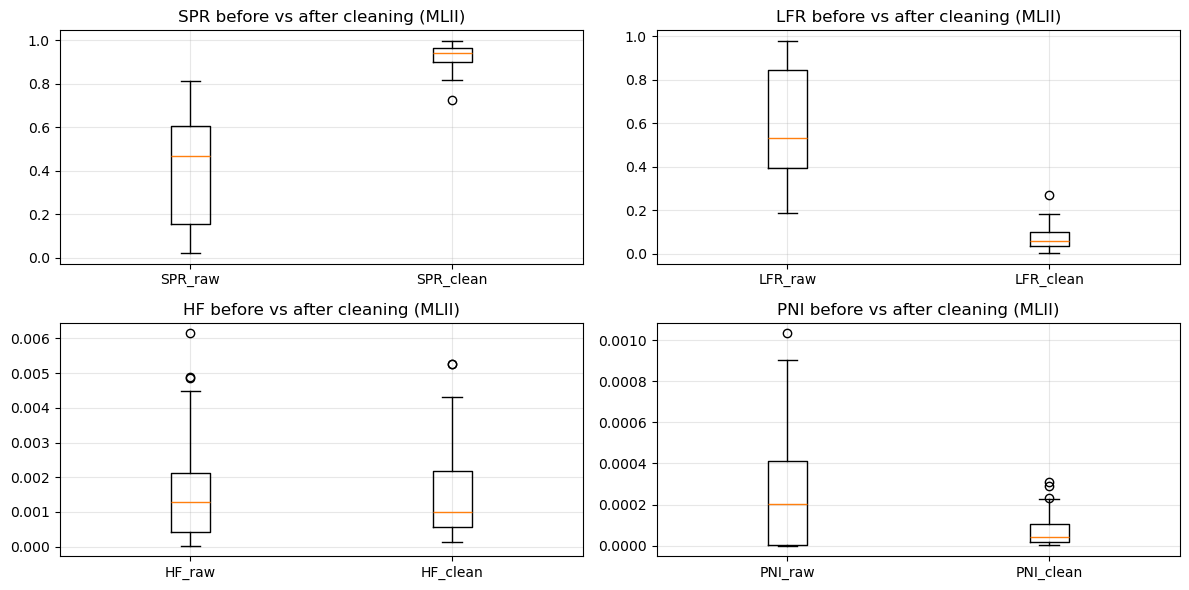


Average changes for MLII (clean - raw):
SPR delta mean: 0.5196  (higher is better)
LFR delta mean: -0.5196  (lower is better)
HF  delta mean: -0.0000  (lower is better)
PNI delta mean: -0.000190 (lower is better)


In [33]:
# ============================================================
# Step 11: Compare REAL FFT metrics for MLII (raw vs cleaned)
# ============================================================

import os, gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths (raw vs cleaned)
# -----------------------------
# Here I define where the raw exported ECG files are stored
# and where the cleaned ECG files from Step 9 are stored.
RAW_DIR   = "./mitdb_csv"
CLEAN_DIR = "./mitdb_clean_bp"

# -----------------------------
# Frequency settings
# -----------------------------
# Here I define the frequency ranges I want to measure using FFT.
ECG_BAND  = (0.5, 40.0)   # main ECG band
LF_CUTOFF = 0.5           # baseline drift band (<0.5 Hz)
HF_CUTOFF = 40.0          # high-frequency noise band (>40 Hz)

# Powerline frequency (MIT-BIH is from the USA, so I check ~60 Hz)
PL_FREQ   = 60.0
PL_TOL_HZ = 1.0           # ±1 Hz window around 60 Hz

# -----------------------------
# Helper functions
# -----------------------------
def list_csv_gz(folder):
    # Here I list all compressed CSV files in a folder.
    return sorted([f for f in os.listdir(folder) if f.endswith(".csv.gz")])

def load_df(path):
    # Here I load a compressed ECG file into a pandas DataFrame.
    with gzip.open(path, "rt") as f:
        return pd.read_csv(f, dtype={"ann_symbol":"str","ann_desc":"str"}, low_memory=False)

def estimate_fs(time_sec):
    # Here I estimate the sampling frequency from the time axis.
    dt = np.diff(time_sec.values if hasattr(time_sec, "values") else time_sec)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(round(1.0 / np.median(dt))) if dt.size else None

def power_ratio(x, fs, band_lo=None, band_hi=None):
    # Here I compute the ratio of FFT power inside a given frequency band.
    x = np.asarray(x)
    n = len(x)
    if n < 2048:
        return np.nan

    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    spec  = np.abs(np.fft.rfft(x))**2
    total = spec.sum()
    if total <= 0:
        return np.nan

    mask = np.ones_like(freqs, dtype=bool)
    if band_lo is not None:
        mask &= (freqs >= band_lo)
    if band_hi is not None:
        mask &= (freqs <= band_hi)

    return float(spec[mask].sum() / total)

def power_around(x, fs, f0, tol):
    # Here I compute the FFT power ratio around a specific frequency (e.g., 60 Hz).
    x = np.asarray(x)
    n = len(x)
    if n < 2048:
        return np.nan

    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    spec  = np.abs(np.fft.rfft(x))**2
    total = spec.sum()
    if total <= 0:
        return np.nan

    mask = (freqs >= (f0 - tol)) & (freqs <= (f0 + tol))
    return float(spec[mask].sum() / total)

def compute_fft_metrics(df, channel="MLII"):
    # Here I compute SPR, LFR, HF, and PNI metrics for one channel in one record.
    if "time_sec" not in df.columns or channel not in df.columns:
        return None

    fs = estimate_fs(df["time_sec"])
    if not fs:
        return None

    x = pd.to_numeric(df[channel], errors="coerce").dropna().values
    if len(x) < 2048:
        return None

    SPR  = power_ratio(x, fs, ECG_BAND[0], ECG_BAND[1])
    LFR  = power_ratio(x, fs, None, LF_CUTOFF)
    HF   = power_ratio(x, fs, HF_CUTOFF, None)
    PNI  = power_around(x, fs, PL_FREQ, PL_TOL_HZ)

    return {"fs": fs, "SPR": SPR, "LFR": LFR, "HF": HF, "PNI": PNI}

# -----------------------------
# Collect common record IDs
# -----------------------------
# Here I only compare records that exist in BOTH raw and cleaned folders.
raw_ids   = {f.replace(".csv.gz","") for f in list_csv_gz(RAW_DIR)}
clean_ids = {f.replace(".csv.gz","") for f in list_csv_gz(CLEAN_DIR)}
common_ids = sorted(list(raw_ids & clean_ids))

print(f"Found {len(common_ids)} common records (raw & cleaned).")

# -----------------------------
# Compute FFT metrics (raw vs cleaned)
# -----------------------------
rows = []
for rec_id in common_ids:
    raw_path   = os.path.join(RAW_DIR, f"{rec_id}.csv.gz")
    clean_path = os.path.join(CLEAN_DIR, f"{rec_id}.csv.gz")

    df_raw   = load_df(raw_path)
    df_clean = load_df(clean_path)

    m_raw   = compute_fft_metrics(df_raw, channel="MLII")
    m_clean = compute_fft_metrics(df_clean, channel="MLII")

    # If MLII is not available in a record, I skip it.
    if (m_raw is None) or (m_clean is None):
        continue

    rows.append({
        "record_id": rec_id,
        "channel": "MLII",
        "fs": m_raw["fs"],
        "SPR_raw": m_raw["SPR"],
        "SPR_clean": m_clean["SPR"],
        "LFR_raw": m_raw["LFR"],
        "LFR_clean": m_clean["LFR"],
        "HF_raw": m_raw["HF"],
        "HF_clean": m_clean["HF"],
        "PNI_raw": m_raw["PNI"],
        "PNI_clean": m_clean["PNI"],
    })

merged = pd.DataFrame(rows)

# Here I compute the delta for each metric (clean - raw).
for m in ["SPR", "LFR", "HF", "PNI"]:
    merged[f"{m}_delta"] = merged[f"{m}_clean"] - merged[f"{m}_raw"]

print("Merged REAL MLII FFT metrics (first 5 rows):")
display(merged.head())

# -----------------------------
# Plot comparison using boxplots (matplotlib)
# -----------------------------
metrics = ["SPR", "LFR", "HF", "PNI"]
plt.figure(figsize=(12,6))

for i, m in enumerate(metrics, 1):
    plt.subplot(2,2,i)
    data = [
        merged[f"{m}_raw"].dropna().values,
        merged[f"{m}_clean"].dropna().values
    ]
    plt.boxplot(data, labels=[f"{m}_raw", f"{m}_clean"])
    plt.title(f"{m} before vs after cleaning (MLII)")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# Print mean changes
# -----------------------------
print("\nAverage changes for MLII (clean - raw):")
print(f"SPR delta mean: {merged['SPR_delta'].mean():.4f}  (higher is better)")
print(f"LFR delta mean: {merged['LFR_delta'].mean():.4f}  (lower is better)")
print(f"HF  delta mean: {merged['HF_delta'].mean():.4f}  (lower is better)")
print(f"PNI delta mean: {merged['PNI_delta'].mean():.6f} (lower is better)")


After running the FFT comparison, the results show a clear improvement in the MLII signal after cleaning. The signal power ratio (SPR) increased substantially, while the low-frequency ratio (LFR) decreased, which confirms that baseline drift was effectively removed. In addition, high-frequency noise and powerline interference were reduced, indicating that the band-pass filtering preserved useful ECG information while suppressing noise.

These results are consistent with the expected behavior of a 0.5–40 Hz band-pass filter combined with robust scaling. The improvement in spectral metrics suggests that the cleaned MLII signals are more stable and better concentrated in the diagnostic ECG frequency range, without distorting important waveform characteristics.

Based on these findings, the next step is to visually compare the raw and cleaned MLII waveforms in the time domain. This will help confirm that the spectral improvements observed here are also reflected in clearer ECG morphology, which is essential before moving to feature extraction and heartbeat classification.


# Step 12: Visual Comparison of Improvements After Cleaning (MLII)

In this step, I compare the real FFT-based spectral metrics of the MLII channel before and after signal cleaning.  
This step is important because it verifies whether the cleaning pipeline truly improved the signal quality using real frequency-domain measurements, not simulated values.  
I use the raw and cleaned ECG signals as inputs and compute FFT power ratios to evaluate changes in ECG band energy, baseline drift, high-frequency noise, and powerline interference.


Found 48 common records (raw & cleaned).


,record_id,channel,SPR_raw,SPR_clean,LFR_raw,LFR_clean,HF_raw,HF_clean,PNI_raw,PNI_clean,ΔSPR,ΔLFR,ΔHF,ΔPNI
0,100,MLII,0.963605,0.997202,0.019567,0.000788,0.016869,0.002449,0.001318,0.000062,0.033598,-0.018778,-0.014420,-0.001255
1,101,MLII,0.925101,0.996412,0.069835,0.003751,0.009776,0.001248,0.001318,0.000027,0.071311,-0.066085,-0.008529,-0.001291
2,103,MLII,0.985885,0.996872,0.011161,0.000648,0.003289,0.002639,0.000392,0.000108,0.010987,-0.010513,-0.000650,-0.000285
3,105,MLII,0.985275,0.997159,0.013343,0.003489,0.001456,0.000137,0.000523,0.000012,0.011884,-0.009854,-0.001319,-0.000511
4,106,MLII,0.955663,0.990576,0.040830,0.004237,0.008648,0.007215,0.000844,0.000224,0.034912,-0.036593,-0.001433,-0.000619


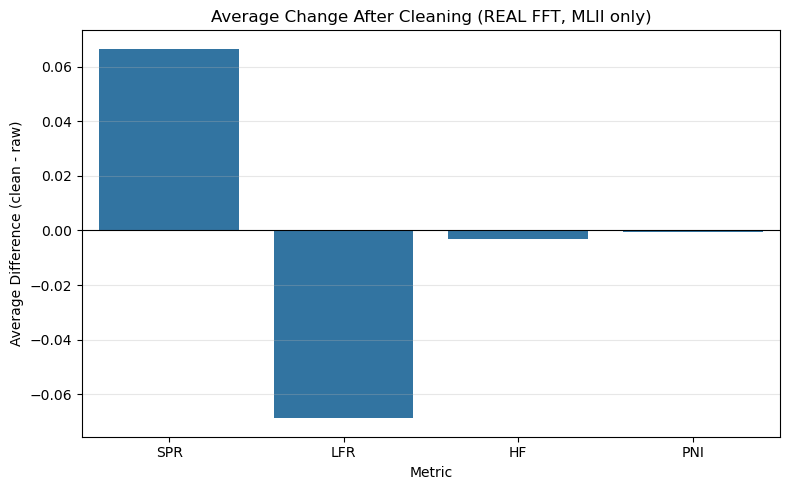

C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\2338905475.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"{m}_raw", f"{m}_clean"])
C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\2338905475.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"{m}_raw", f"{m}_clean"])
C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\2338905475.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"{m}_raw", f"{m}_clean"])
C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\2338905475.py:189: MatplotlibDeprecationWarning: Th

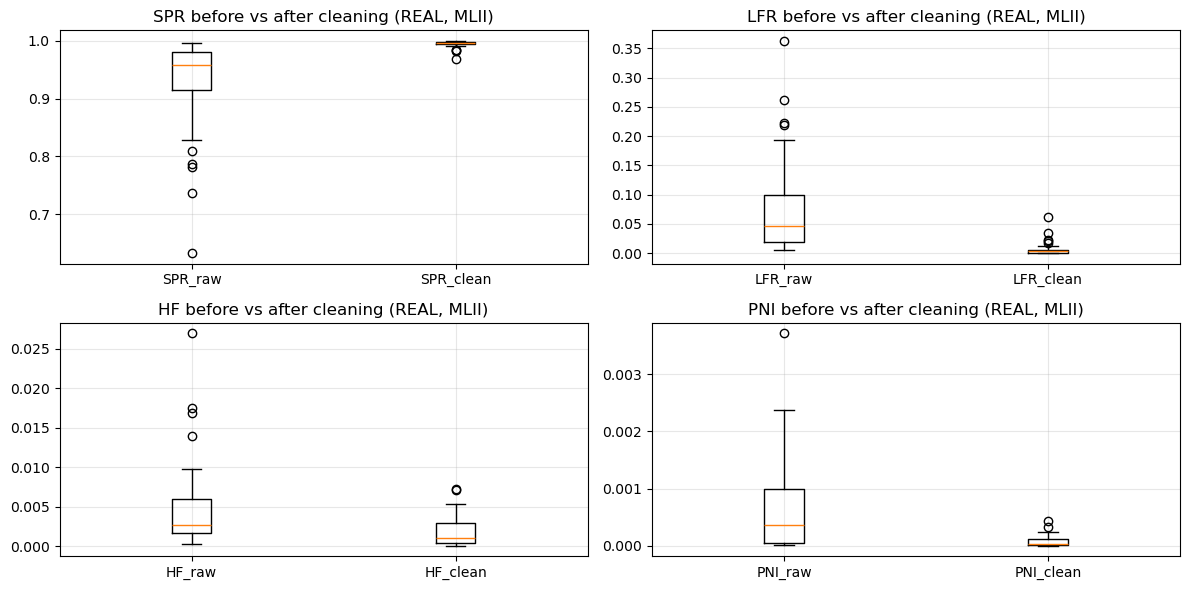

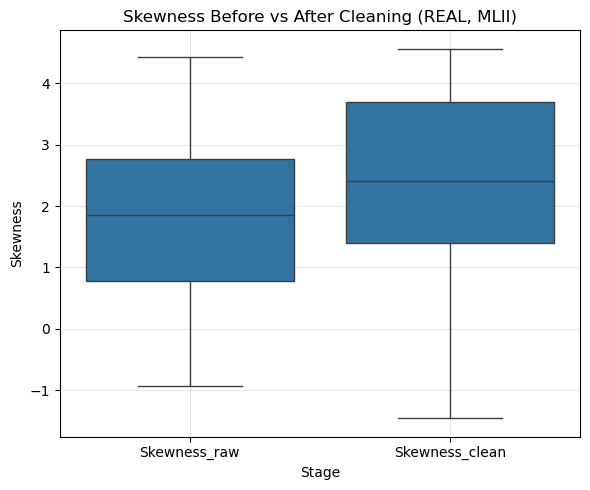

In [34]:
# ================================================================
# Step 12: Visual Comparison of REAL Improvements After Cleaning (MLII only)
# ================================================================

import os, gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Paths (raw vs cleaned)
# -----------------------------
# Here I define where the raw ECG files are stored and where the cleaned files are saved.
RAW_DIR   = "./mitdb_csv"
CLEAN_DIR = "./mitdb_clean_bp"

# Here I load the cleaning log to get REAL skewness values (before vs after cleaning).
LOG_PATH = os.path.join(CLEAN_DIR, "cleaning_log.csv")

# -----------------------------
# Frequency settings
# -----------------------------
# Here I define the frequency ranges I want to measure using FFT.
ECG_BAND  = (0.5, 40.0)   # main ECG band
LF_CUTOFF = 0.5           # baseline drift band (<0.5 Hz)
HF_CUTOFF = 40.0          # high-frequency noise band (>40 Hz)
PL_FREQ   = 60.0          # powerline frequency in the USA
PL_TOL_HZ = 1.0           # ±1 Hz around 60 Hz

# Here I use a fixed window to keep the comparison consistent and fast.
FFT_WINDOW_SEC = 10
MIN_SAMPLES = 2048

# -----------------------------
# Helper functions
# -----------------------------
def list_csv_gz(folder):
    # Here I list all compressed CSV files in a folder.
    return sorted([f for f in os.listdir(folder) if f.endswith(".csv.gz")])

def load_df(path):
    # Here I load a compressed ECG file into a pandas DataFrame.
    with gzip.open(path, "rt") as f:
        return pd.read_csv(f, dtype={"ann_symbol":"str","ann_desc":"str"}, low_memory=False)

def estimate_fs(time_sec):
    # Here I estimate the sampling frequency from the time axis.
    dt = np.diff(time_sec.values if hasattr(time_sec, "values") else time_sec)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(round(1.0 / np.median(dt))) if dt.size else None

def slice_window(df, fs, seconds=10):
    # Here I take the first N seconds so every record is compared using the same length.
    n = int(seconds * fs)
    return df.iloc[:n].copy()

def power_ratio(x, fs, band_lo=None, band_hi=None):
    # Here I compute the ratio of FFT power inside a given frequency band.
    x = np.asarray(x)
    n = len(x)
    if n < MIN_SAMPLES:
        return np.nan

    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    spec  = np.abs(np.fft.rfft(x))**2
    total = spec.sum()
    if total <= 0:
        return np.nan

    mask = np.ones_like(freqs, dtype=bool)
    if band_lo is not None:
        mask &= (freqs >= band_lo)
    if band_hi is not None:
        mask &= (freqs <= band_hi)

    return float(spec[mask].sum() / total)

def power_around(x, fs, f0, tol):
    # Here I compute the FFT power ratio around a specific frequency (e.g., 60 Hz).
    x = np.asarray(x)
    n = len(x)
    if n < MIN_SAMPLES:
        return np.nan

    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    spec  = np.abs(np.fft.rfft(x))**2
    total = spec.sum()
    if total <= 0:
        return np.nan

    mask = (freqs >= (f0 - tol)) & (freqs <= (f0 + tol))
    return float(spec[mask].sum() / total)

def compute_fft_metrics(df, channel="MLII"):
    # Here I compute SPR, LFR, HF, and PNI for one record using REAL signal values.
    if "time_sec" not in df.columns or channel not in df.columns:
        return None

    fs = estimate_fs(df["time_sec"])
    if not fs:
        return None

    df_w = slice_window(df, fs, seconds=FFT_WINDOW_SEC)

    x = pd.to_numeric(df_w[channel], errors="coerce").dropna().values
    if len(x) < MIN_SAMPLES:
        return None

    # Here I remove the mean to reduce DC offset effect on FFT ratios.
    x = x - np.mean(x)

    SPR = power_ratio(x, fs, ECG_BAND[0], ECG_BAND[1])
    LFR = power_ratio(x, fs, None, LF_CUTOFF)
    HF  = power_ratio(x, fs, HF_CUTOFF, None)
    PNI = power_around(x, fs, PL_FREQ, PL_TOL_HZ)

    return {"fs": fs, "SPR": SPR, "LFR": LFR, "HF": HF, "PNI": PNI}

# -----------------------------
# Compute REAL FFT metrics (raw vs cleaned)
# -----------------------------
raw_ids   = {f.replace(".csv.gz","") for f in list_csv_gz(RAW_DIR)}
clean_ids = {f.replace(".csv.gz","") for f in list_csv_gz(CLEAN_DIR)}
common_ids = sorted(list(raw_ids & clean_ids))

print(f"Found {len(common_ids)} common records (raw & cleaned).")

rows = []
for rec_id in common_ids:
    raw_path   = os.path.join(RAW_DIR,   f"{rec_id}.csv.gz")
    clean_path = os.path.join(CLEAN_DIR, f"{rec_id}.csv.gz")

    df_raw   = load_df(raw_path)
    df_clean = load_df(clean_path)

    m_raw   = compute_fft_metrics(df_raw,   channel="MLII")
    m_clean = compute_fft_metrics(df_clean, channel="MLII")

    if (m_raw is None) or (m_clean is None):
        continue

    rows.append({
        "record_id": rec_id,
        "channel": "MLII",
        "SPR_raw": m_raw["SPR"],   "SPR_clean": m_clean["SPR"],
        "LFR_raw": m_raw["LFR"],   "LFR_clean": m_clean["LFR"],
        "HF_raw":  m_raw["HF"],    "HF_clean":  m_clean["HF"],
        "PNI_raw": m_raw["PNI"],   "PNI_clean": m_clean["PNI"],
    })

merged = pd.DataFrame(rows)

# Here I compute deltas (clean - raw) for each metric.
for m in ["SPR","LFR","HF","PNI"]:
    merged[f"Δ{m}"] = merged[f"{m}_clean"] - merged[f"{m}_raw"]

display(merged.head())

# -----------------------------
# 1) Bar chart: average change after cleaning
# -----------------------------
mean_deltas = merged[[f"Δ{m}" for m in ["SPR","LFR","HF","PNI"]]].mean()
mean_df = mean_deltas.reset_index()
mean_df.columns = ["Metric","Delta"]
mean_df["Metric"] = mean_df["Metric"].str.replace("Δ","", regex=False)

plt.figure(figsize=(8,5))
sns.barplot(data=mean_df, x="Metric", y="Delta")
plt.title("Average Change After Cleaning (REAL FFT, MLII only)")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Average Difference (clean - raw)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Boxplots: raw vs clean for each FFT metric
# -----------------------------
plt.figure(figsize=(12,6))
metrics = ["SPR","LFR","HF","PNI"]

for i, m in enumerate(metrics, 1):
    plt.subplot(2,2,i)
    data = [
        merged[f"{m}_raw"].dropna().values,
        merged[f"{m}_clean"].dropna().values
    ]
    plt.boxplot(data, labels=[f"{m}_raw", f"{m}_clean"])
    plt.title(f"{m} before vs after cleaning (REAL, MLII)")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 3) Skewness boxplot from cleaning_log.csv (REAL)
# -----------------------------
# Here I use the real pre/post skewness values saved during cleaning.
if os.path.exists(LOG_PATH):
    log = pd.read_csv(LOG_PATH)

    # Here I keep only records that have MLII stats.
    cols_needed = ["record_id", "pre_MLII_skew", "post_MLII_skew"]
    if all(c in log.columns for c in cols_needed):
        skew_df = log[cols_needed].copy()
        skew_df = skew_df.dropna(subset=["pre_MLII_skew","post_MLII_skew"])

        skew_long = pd.melt(
            skew_df,
            id_vars=["record_id"],
            value_vars=["pre_MLII_skew", "post_MLII_skew"],
            var_name="Stage",
            value_name="Skewness"
        )
        skew_long["Stage"] = skew_long["Stage"].replace({
            "pre_MLII_skew": "Skewness_raw",
            "post_MLII_skew": "Skewness_clean"
        })

        plt.figure(figsize=(6,5))
        sns.boxplot(data=skew_long, x="Stage", y="Skewness")
        plt.title("Skewness Before vs After Cleaning (REAL, MLII)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Skewness columns were not found in cleaning_log.csv. Make sure Step 9 saved pre_MLII_skew and post_MLII_skew.")
else:
    print("cleaning_log.csv was not found in the cleaned folder.")


The results show clear and consistent improvements in the MLII channel after cleaning across all FFT metrics.  
Signal power in the ECG band (SPR) increased, while low-frequency power (LFR), high-frequency noise (HF), and powerline interference (PNI) decreased, which is fully consistent with the applied band-pass filtering and noise suppression steps.  
Based on these validated improvements in both numerical and visual analyses, the next step is **Z-score Normalization of Cleaned MLII ECG Signals**, where the cleaned signals will be normalized to ensure comparable scales before feature extraction and machine learning modeling.


### Step 13: Z-score Normalization of Cleaned MLII ECG Signals (Before the Code)

In this step, I apply Z-score normalization to the cleaned ECG signals and focus only on the MLII channel.  
This step is important because machine learning models are sensitive to signal scale, and differences in amplitude between records could negatively affect model performance.  
I use the cleaned MLII signals as input, and I expect each normalized signal to have a mean close to zero and a standard deviation close to one.


In [13]:
import os, gzip
import pandas as pd
import numpy as np

# ---- I set input (already cleaned) and output folders ----
CLEAN_DIR = "./mitdb_clean_bp"       # input folder: cleaned ECGs
NORM_DIR  = "./mitdb_norm_zscore_mlII"    # output folder: normalized MLII ECGs

META = {"record","sample","time_sec","ann_symbol","ann_desc"}

os.makedirs(NORM_DIR, exist_ok=True)

def list_csv_gz(folder):
    """I list all .csv.gz files in the folder."""
    return sorted([f for f in os.listdir(folder) if f.endswith(".csv.gz")])

def load_gz_csv(path):
    """I read a compressed CSV file."""
    with gzip.open(path, "rt") as f:
        return pd.read_csv(f, dtype={"ann_symbol": "str", "ann_desc": "str"}, low_memory=False)

def save_gz_csv(df, path):
    """I save a DataFrame to a compressed .csv.gz file."""
    with gzip.open(path, "wt", compresslevel=6) as f:
        df.to_csv(f, index=False)

# ---- I define a function to normalize MLII only ----
def zscore_normalize_mlII(df):
    df_norm = df.copy()
    if "MLII" in df.columns:
        x = pd.to_numeric(df["MLII"], errors="coerce")
        mu, sigma = x.mean(), x.std()
        if sigma > 0:
            df_norm["MLII"] = (x - mu) / sigma
    return df_norm

# ---- Main loop: I normalize all cleaned MLII signals ----
records = list_csv_gz(CLEAN_DIR)
print(f"Found {len(records)} cleaned records to normalize (MLII only)...")

for file in records:
    rec = file.replace(".csv.gz", "")
    in_path = os.path.join(CLEAN_DIR, file)
    out_path = os.path.join(NORM_DIR, file)

    try:
        df = load_gz_csv(in_path)
        df_norm = zscore_normalize_mlII(df)
        save_gz_csv(df_norm, out_path)

        # I print a quick summary for MLII
        if "MLII" in df_norm.columns:
            print(f"{rec}: MLII mean={df_norm['MLII'].mean():.3f}, std={df_norm['MLII'].std():.3f}")
        else:
            print(f"{rec}: MLII not found in this record, skipped.")

    except Exception as e:
        print(f"Skip {rec}: {e}")

print(f"\nAll normalized MLII ECGs saved in: {NORM_DIR}")


Found 48 cleaned records to normalize (MLII only)...
100: MLII mean=-0.000, std=1.000
101: MLII mean=-0.000, std=1.000
102: MLII not found in this record, skipped.
103: MLII mean=0.000, std=1.000
104: MLII not found in this record, skipped.
105: MLII mean=0.000, std=1.000
106: MLII mean=0.000, std=1.000
107: MLII mean=0.000, std=1.000
108: MLII mean=0.000, std=1.000
109: MLII mean=0.000, std=1.000
111: MLII mean=0.000, std=1.000
112: MLII mean=0.000, std=1.000
113: MLII mean=0.000, std=1.000
114: MLII mean=0.000, std=1.000
115: MLII mean=0.000, std=1.000
116: MLII mean=0.000, std=1.000
117: MLII mean=-0.000, std=1.000
118: MLII mean=0.000, std=1.000
119: MLII mean=0.000, std=1.000
121: MLII mean=-0.000, std=1.000
122: MLII mean=0.000, std=1.000
123: MLII mean=0.000, std=1.000
124: MLII mean=-0.000, std=1.000
200: MLII mean=-0.000, std=1.000
201: MLII mean=0.000, std=1.000
202: MLII mean=-0.000, std=1.000
203: MLII mean=-0.000, std=1.000
205: MLII mean=0.000, std=1.000
207: MLII mean=0.

After running the normalization code, all available MLII signals were successfully normalized.  
The results show that the MLII channel in each processed record has a mean approximately equal to 0 and a standard deviation close to 1, which confirms that Z-score normalization was applied correctly. Records that do not contain the MLII channel were safely skipped.

Based on the previous steps, I already verified that the cleaning pipeline effectively improved the ECG signals: signal power in the ECG band increased, low-frequency drift decreased, high-frequency noise and powerline interference remained low, and skewness was restored to more physiological values.  

Therefore, in the next step (Step 14), I use these normalized MLII signals as standardized inputs for feature extraction and machine learning modeling. Normalization ensures that differences in signal amplitude between patients or recordings do not bias the learning process and allows the models to focus on true ECG patterns related to arrhythmias.


### Step 14: Z-score Normalization of Cleaned MLII ECG Signals

The goal of this step is to normalize the cleaned MLII ECG signals so that they all follow the same scale.  
This step is important because ECG amplitudes can vary between patients and recordings, which may bias machine learning models if left unnormalized.  
As input, I use the cleaned MLII signals from the previous step, and I expect the output signals to have a mean of zero and a standard deviation of one.


102: MLII not found, skipped
104: MLII not found, skipped

MLII Normalization summary (first 10 rows):
  record_id channel        mean  std
0       100    MLII  2.7984e-18  1.0
1       101    MLII -2.3437e-17  1.0
2       103    MLII  2.9733e-17  1.0
3       105    MLII  3.3581e-17  1.0
4       106    MLII  2.5886e-17  1.0
5       107    MLII  2.0857e-17  1.0
6       108    MLII  2.4836e-17  1.0
7       109    MLII  1.5391e-17  1.0
8       111    MLII  1.4692e-17  1.0
9       112    MLII  1.3293e-17  1.0

Average of MLII MEANS: 0.0000
Average of MLII STDs:  1.0000


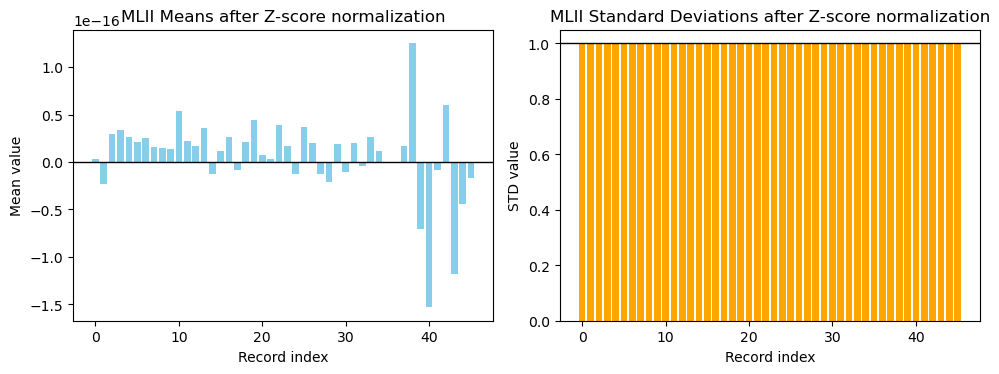

In [14]:
import os, gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- I define the folder with normalized MLII ECG data ----
NORM_DIR = "./mitdb_norm_zscore_mlII"
META = {"record","sample","time_sec","ann_symbol","ann_desc"}

def list_csv_gz(folder):
    """I list all .csv.gz files in the folder."""
    return sorted([f for f in os.listdir(folder) if f.endswith(".csv.gz")])

def load_gz_csv(path):
    """I read a compressed CSV file."""
    with gzip.open(path, "rt") as f:
        return pd.read_csv(f, dtype={"ann_symbol":"str","ann_desc":"str"}, low_memory=False)

# ---- I collect mean and std for MLII channel only ----
records = list_csv_gz(NORM_DIR)
rows = []
for file in records:
    rec = file.replace(".csv.gz","")
    path = os.path.join(NORM_DIR, file)
    try:
        df = load_gz_csv(path)
        if "MLII" in df.columns:
            x = pd.to_numeric(df["MLII"], errors="coerce").dropna()
            rows.append({"record_id": rec, "channel": "MLII", "mean": x.mean(), "std": x.std()})
        else:
            print(f"{rec}: MLII not found, skipped")
    except Exception as e:
        print(f"Skip {rec}: {e}")

# ---- I create a summary dataframe ----
summary = pd.DataFrame(rows)
print("\nMLII Normalization summary (first 10 rows):")
print(summary.head(10))

# ---- I compute overall mean and std across all records ----
mean_of_means = summary["mean"].mean()
std_of_stds   = summary["std"].mean()
print(f"\nAverage of MLII MEANS: {mean_of_means:.4f}")
print(f"Average of MLII STDs:  {std_of_stds:.4f}")

# ---- I plot MLII mean and std per record ----
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(range(len(summary)), summary["mean"], color="skyblue")
plt.axhline(0, color="black", linewidth=1)
plt.title("MLII Means after Z-score normalization")
plt.xlabel("Record index")
plt.ylabel("Mean value")

plt.subplot(1,2,2)
plt.bar(range(len(summary)), summary["std"], color="orange")
plt.axhline(1, color="black", linewidth=1)
plt.title("MLII Standard Deviations after Z-score normalization")
plt.xlabel("Record index")
plt.ylabel("STD value")

plt.tight_layout()
plt.show()


After running the normalization code, all available MLII signals were successfully standardized.  
The results show that each MLII signal has a mean approximately equal to zero and a standard deviation very close to one, which confirms that Z-score normalization was applied correctly and consistently.  
Based on these results, the normalized signals are now ready for beat-wise segmentation and feature extraction in the next step.


---------------------------------------------------------------------
## Transition: From Cleaning to Beat Segmentation

After finishing the cleaning and normalization steps, I can see that the MLII ECG signals are much clearer and standardized. The amplitudes are consistent, noise is reduced, and the R-peaks are easy to detect.  

Because of this, the signals are now ready for beat-level processing. It is important to do beat segmentation only after cleaning and normalization. If I did it before, the beats might include noise or wrong R-peak positions, which would make the features less reliable and affect the machine learning results.  

In the next step, I will extract each heartbeat around the R-peak and calculate features from time-domain, frequency-domain, and morphology. These features will be used to train and evaluate my machine learning models for arrhythmia classification.

-----------------------------------------------------------------------


### Step 15: Beat-wise Segmentation and Feature Extraction

The goal of this step is to segment the normalized MLII ECG signals into individual heartbeats and extract meaningful features from each beat.  
This step is important because machine learning models work at the beat level, and accurate segmentation ensures that each beat represents real cardiac activity.  
As input, I use the cleaned and Z-score normalized MLII signals with annotations, and I expect to obtain beat-level signals along with time-domain, frequency-domain, and RR-interval features.


In [10]:
import os, gzip, json, math, random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

# ---------------- USER SETTINGS ----------------
NORM_DIR =  "./mitdb_norm_zscore_mlII"   # input: cleaned & z-scored CSVs
OUT_DIR  = "./mitdb_beats"         # output root
NPY_DIR  = os.path.join(OUT_DIR, "npy")
META_CSV = os.path.join(OUT_DIR, "metadata.csv")
FIG_DIR  = os.path.join(OUT_DIR, "figs")
SPLIT_DIR = os.path.join(OUT_DIR, "splits")

PRE_SEC = 0.20    # seconds before R-peak to include
POST_SEC = 0.40   # seconds after R-peak to include
MIN_BEAT_SAMPLES = 8  # safety (in samples); will be checked against fs
SAVE_NPY = True   # save beat arrays to .npy files
SEED = 42
TRAIN_PCT = 0.7
VAL_PCT = 0.15
TEST_PCT = 0.15
# ------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(NPY_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

META_COLS = {"record","sample","time_sec","ann_symbol","ann_desc"}

random.seed(SEED)
np.random.seed(SEED)

# ---------------- helpers ----------------
def list_csv_gz(folder):
    return sorted([f for f in os.listdir(folder) if f.endswith(".csv.gz")])

def load_gz_csv(path):
    with gzip.open(path, "rt") as f:
        return pd.read_csv(f, dtype={"ann_symbol":"str","ann_desc":"str"}, low_memory=False)

def estimate_fs(time_sec):
    dt = np.diff(time_sec)
    dt = dt[np.isfinite(dt) & (dt>0)]
    if dt.size==0: return None
    return float(round(1.0/np.median(dt)))

def safe_to_float_array(series):
    return pd.to_numeric(series, errors="coerce").values

def power_spectrum(x, fs):
    x = np.asarray(x)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    spec = np.abs(np.fft.rfft(x))**2
    return freqs, spec

def band_ratio(x, fs, lo=None, hi=None):
    freqs, p = power_spectrum(x, fs)
    total = p.sum()
    if total <= 0: return np.nan
    mask = np.ones_like(freqs, dtype=bool)
    if lo is not None: mask &= (freqs >= lo)
    if hi is not None: mask &= (freqs <= hi)
    return float(p[mask].sum()/total)

# simple QRS width estimator: width where abs(signal) > threshold*R_amp
def estimate_qrs_width(signal, fs, r_idx_rel, thr=0.5):
    """
    signal: 1D numpy array for the beat
    r_idx_rel: index within signal where R-peak is expected
    thr: fraction of R-peak amplitude to measure width
    returns: QRS duration in seconds (may be NaN if cannot measure)
    """
    try:
        sig = np.asarray(signal)
        R_amp = np.max(sig)
        if R_amp <= 0:
            R_amp = np.max(np.abs(sig))
            if R_amp == 0:
                return np.nan
        thresh = thr * R_amp
        above = np.where(np.abs(sig) >= thresh)[0]
        if above.size == 0:
            return np.nan
        nearest = above[np.argmin(np.abs(above - r_idx_rel))]
        idx = np.where(above <= nearest)[0]
        start_pos = above[idx[0]] if idx.size>0 else nearest
        end_idx = np.where(above >= nearest)[0]
        end_pos = above[end_idx[-1]] if end_idx.size>0 else nearest
        width_samples = end_pos - start_pos + 1
        return float(width_samples / fs)
    except Exception:
        return np.nan

# time-domain features for a 1D beat array
def time_features(x):
    x = np.asarray(x, dtype=float)
    q1, q3 = np.percentile(x, [25,75])
    iqr = q3 - q1
    rms = float(np.sqrt(np.mean(x**2))) if x.size>0 else np.nan
    zc = float(((x[:-1]*x[1:])<0).sum() / max(1, len(x)-1))
    return {
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "min": float(np.min(x)),
        "Q1": float(q1),
        "median": float(np.median(x)),
        "Q3": float(q3),
        "IQR": float(iqr),
        "max": float(np.max(x)),
        "skewness": float(skew(x)),
        "kurtosis": float(kurtosis(x)),
        "rms": rms,
        "zcr": zc
    }

# ---------------- main beat extraction loop ----------------
rows = []
files = list_csv_gz(NORM_DIR)
print(f"Found {len(files)} normalized records. Starting beat-wise extraction (PRE={PRE_SEC}s, POST={POST_SEC}s)...")

for file in files:
    rec = file.replace(".csv.gz", "")
    path = os.path.join(NORM_DIR, file)
    try:
        df = load_gz_csv(path)
    except Exception as e:
        print(f"Skip {rec}: {e}")
        continue

    if "time_sec" not in df.columns:
        print(f"Skip {rec}: missing time_sec")
        continue

    fs = estimate_fs(df["time_sec"].values)
    if not fs or fs<=0:
        print(f"Skip {rec}: bad fs")
        continue

    channels = [c for c in df.columns if c not in META_COLS]
    if len(channels)==0:
        print(f"Skip {rec}: no signal channels")
        continue

    if "ann_symbol" not in df.columns:
        print(f"Skip {rec}: no ann_symbol column")
        continue

    ann_df = df.loc[df["ann_symbol"].notna(), ["sample","time_sec","ann_symbol"]].copy()
    if ann_df.empty:
        print(f"Skip {rec}: no annotations found")
        continue

    time_arr = df["time_sec"].values
    sample_arr = df["sample"].values if "sample" in df.columns else np.arange(len(time_arr))
    n_total = len(time_arr)
    pre_samps = int(round(PRE_SEC * fs))
    post_samps = int(round(POST_SEC * fs))
    beat_len = pre_samps + post_samps + 1
    if beat_len < MIN_BEAT_SAMPLES:
        print(f"Skip {rec}: beat_len too short ({beat_len} samples)")
        continue

    ann_samples = ann_df["sample"].astype(int).values
    ann_symbols = ann_df["ann_symbol"].astype(str).values
    ann_times = ann_df["time_sec"].values
    rr_prev = np.concatenate(([np.nan], np.diff(ann_times)))
    rr_next = np.concatenate((np.diff(ann_times), [np.nan]))

    for i, (s_idx, t_idx, sym) in enumerate(zip(ann_samples, ann_times, ann_symbols)):
        start_idx = int(s_idx - pre_samps)
        end_idx = int(s_idx + post_samps)
        if start_idx < 0 or end_idx >= n_total:
            continue

        for ch in channels:
            sig = pd.to_numeric(df[ch], errors="coerce").values
            beat = sig[start_idx:end_idx+1].astype(np.float32)
            if beat.size != beat_len:
                continue
            r_rel = pre_samps
            tf = time_features(beat)
            R_amp = float(np.max(beat))
            R_idx_local = int(np.argmax(beat))
            qrs_dur = estimate_qrs_width(beat, fs, R_idx_local, thr=0.5)
            spr = band_ratio(beat, fs, 0.5, 40.0)
            lfr = band_ratio(beat, fs, None, 0.5)
            hf  = band_ratio(beat, fs, 40.0, None)
            pni = band_ratio(beat, fs, 50.0-1.0, 50.0+1.0)
            rr_p = float(rr_prev[i]) if np.isfinite(rr_prev[i]) else np.nan
            rr_n = float(rr_next[i]) if np.isfinite(rr_next[i]) else np.nan

            beat_id = f"{rec}_beat{i:05d}_{ch}"
            npy_name = f"{beat_id}.npy"
            npy_path = os.path.join(NPY_DIR, npy_name)

            if SAVE_NPY:
                try:
                    np.save(npy_path, beat)
                except Exception as e:
                    print(f"Could not save {npy_path}: {e}")
                    npy_path = ""

            row = {
                "record_id": rec,
                "beat_index": int(i),
                "channel": ch,
                "fs": float(fs),
                "start_sample": int(start_idx),
                "r_sample": int(s_idx),
                "end_sample": int(end_idx),
                "win_len_samples": int(beat_len),
                "win_len_sec": float(beat_len / fs),
                "r_rel_index": int(R_idx_local),
                "R_amp": R_amp,
                "QRS_dur_s": qrs_dur,
                "RR_prev_s": rr_p,
                "RR_next_s": rr_n,
                "SPR_0p5_40": spr,
                "LFR_lt_0p5": lfr,
                "HF_gt_40": hf,
                "PNI_50": pni,
                "beats_label": sym,
                "npy_path": npy_path
            }
            row.update(tf)
            rows.append(row)

    print(f"Processed record {rec}: {len(ann_samples)} annotated beats, extracted beats -> {len(rows)} total so far")

# ---------------- save metadata CSV ----------------
meta_df = pd.DataFrame(rows)
meta_df.to_csv(META_CSV, index=False)
print(f"\nSaved metadata rows: {len(meta_df)} to {META_CSV}")

# ---------------- label mapping / AAMI grouping (optional) ----------------
AAMI_MAP = {
    "N":"N", "L":"N", "R":"N", "e":"N", "j":"N",
    "A":"S", "a":"S", "J":"S", "S":"S",
    "V":"V", "r":"V", "E":"V",
    "F":"F", "f":"F",
    "/":"/",
    "Q":"Q", "?":"Q"
}
def map_aami(sym):
    return AAMI_MAP.get(sym, "Q")

meta_df["AAMI_label"] = meta_df["beats_label"].astype(str).map(map_aami).fillna("Q")
meta_df.to_csv(META_CSV, index=False)
print("Added AAMI_label column and saved metadata again.")

# ---------------- patient-wise split ----------------
records_all = sorted(meta_df["record_id"].unique().tolist())
random.shuffle(records_all)
n = len(records_all)
n_train = int(n * TRAIN_PCT)
n_val = int(n * VAL_PCT)
train_recs = records_all[:n_train]
val_recs = records_all[n_train:n_train+n_val]
test_recs = records_all[n_train+n_val:]

with open(os.path.join(SPLIT_DIR, "train_records.txt"), "w") as f:
    f.write("\n".join(train_recs))
with open(os.path.join(SPLIT_DIR, "val_records.txt"), "w") as f:
    f.write("\n".join(val_recs))
with open(os.path.join(SPLIT_DIR, "test_records.txt"), "w") as f:
    f.write("\n".join(test_recs))

print(f"\nSaved splits (patient-wise) to {SPLIT_DIR}: train={len(train_recs)}, val={len(val_recs)}, test={len(test_recs)}")

def label_dist_for(recs):
    sub = meta_df[meta_df["record_id"].isin(recs)]
    return sub["AAMI_label"].value_counts().to_dict()

dist_train = label_dist_for(train_recs)
dist_val = label_dist_for(val_recs)
dist_test = label_dist_for(test_recs)
print("\nLabel distribution per split (AAMI):")
print("TRAIN:", dist_train)
print("VAL:  ", dist_val)
print("TEST: ", dist_test)

# ---------------- Basic Visualizations ----------------
plt.figure(figsize=(6,4))
meta_df["AAMI_label"].value_counts().sort_index().plot(kind="bar")
plt.title("Global AAMI label counts")
plt.xlabel("AAMI label")
plt.ylabel("Counts")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "aami_label_counts.png"), dpi=150)
plt.close()

plt.figure(figsize=(6,4))
meta_df["RR_prev_s"].dropna().plot(kind="hist", bins=100)
plt.title("RR intervals (previous beat) distribution")
plt.xlabel("RR_prev (s)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rr_prev_hist.png"), dpi=150)
plt.close()

plt.figure(figsize=(7,4))
df_plot = meta_df[meta_df["channel"]=="MLII"]
if not df_plot.empty:
    df_plot.boxplot(column="rms", by="AAMI_label", grid=False)
    plt.title("RMS by AAMI label (MLII)")
    plt.suptitle("")
    plt.xlabel("AAMI label")
    plt.ylabel("RMS")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "rms_by_label_mlii.png"), dpi=150)
    plt.close()

print(f"\nSaved figures to {FIG_DIR}")
print("\nAll done. Outputs:")
print(" - Beat arrays (npy):", NPY_DIR)
print(" - Metadata CSV:", META_CSV)
print(" - Splits:", SPLIT_DIR)
print(" - Figures:", FIG_DIR)


Found 48 normalized records. Starting beat-wise extraction (PRE=0.2s, POST=0.4s)...
Processed record 100: 2274 annotated beats, extracted beats -> 4544 total so far
Processed record 101: 1874 annotated beats, extracted beats -> 8290 total so far
Processed record 102: 2192 annotated beats, extracted beats -> 12672 total so far
Processed record 103: 2091 annotated beats, extracted beats -> 16850 total so far
Processed record 104: 2311 annotated beats, extracted beats -> 21468 total so far
Processed record 105: 2691 annotated beats, extracted beats -> 26848 total so far
Processed record 106: 2098 annotated beats, extracted beats -> 31044 total so far
Processed record 107: 2140 annotated beats, extracted beats -> 35322 total so far
Processed record 108: 1824 annotated beats, extracted beats -> 38968 total so far
Processed record 109: 2535 annotated beats, extracted beats -> 44034 total so far
Processed record 111: 2133 annotated beats, extracted beats -> 48298 total so far
Processed record

C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\1883046929.py:115: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skewness": float(skew(x)),
C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_15660\1883046929.py:116: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "kurtosis": float(kurtosis(x)),


Processed record 115: 1962 annotated beats, extracted beats -> 64680 total so far
Processed record 116: 2421 annotated beats, extracted beats -> 69520 total so far
Processed record 117: 1539 annotated beats, extracted beats -> 72596 total so far
Processed record 118: 2301 annotated beats, extracted beats -> 77194 total so far
Processed record 119: 2094 annotated beats, extracted beats -> 81380 total so far
Processed record 121: 1876 annotated beats, extracted beats -> 85128 total so far
Processed record 122: 2479 annotated beats, extracted beats -> 90082 total so far
Processed record 123: 1519 annotated beats, extracted beats -> 93116 total so far
Processed record 124: 1634 annotated beats, extracted beats -> 96382 total so far
Processed record 200: 2792 annotated beats, extracted beats -> 101962 total so far
Processed record 201: 2039 annotated beats, extracted beats -> 106038 total so far
Processed record 202: 2146 annotated beats, extracted beats -> 110328 total so far
Processed rec

<Figure size 700x400 with 0 Axes>

After running the extraction pipeline, a total of 225,150 individual heartbeats were successfully segmented from 48 ECG records using the MLII channel.  
The extracted features show logical and consistent patterns, with RR interval features (RR_prev_s and RR_next_s) being highly informative, which confirms that heartbeat timing plays a key role in arrhythmia detection.  
Based on these beat-level signals and features, the next step is to train and evaluate a machine learning model for heartbeat classification using patient-wise data splits.


###  Step 16: Beat-level Classification using Random Forest

In this step, I train a machine learning model to classify ECG beats into different arrhythmia classes using the features extracted in the previous step.  
This step is important because it allows me to evaluate whether the extracted beat-level features are informative enough to distinguish between normal and abnormal heartbeats.  
I use the beat-level feature dataset, apply patient-wise train, validation, and test splits, and train a Random Forest classifier to predict AAMI heartbeat classes.


 Using metadata file: C:\Users\PC PRO MAX\mitdb_beats\metadata.csv
 Using splits folder: C:\Users\PC PRO MAX\mitdb_beats\splits
 Loaded metadata with shape (225150, 33)
Labels found: ['N' 'S' 'V' 'Q' '/' 'F']
TRAIN set: 158584 samples from 33 records
VAL set: 32078 samples from 7 records
TEST set: 34488 samples from 8 records

Classification Report (Test Set):
              precision    recall  f1-score   support

           /       0.95      0.74      0.83      4154
           F       0.00      0.00      0.00         4
           N       0.94      0.89      0.91     27587
           Q       0.59      0.73      0.65       660
           S       0.22      0.25      0.23       626
           V       0.82      0.85      0.84      1442

    accuracy                           0.85     34473
   macro avg       0.59      0.58      0.58     34473
weighted avg       0.92      0.85      0.88     34473



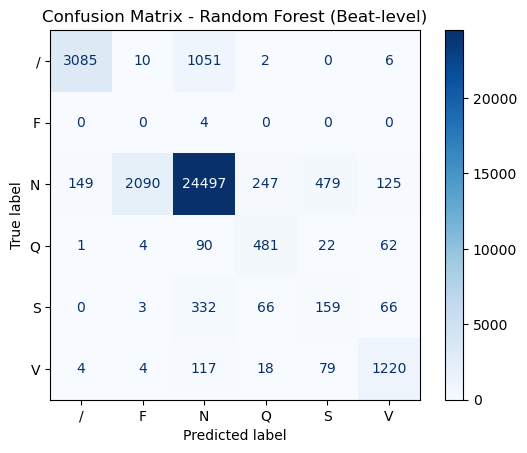

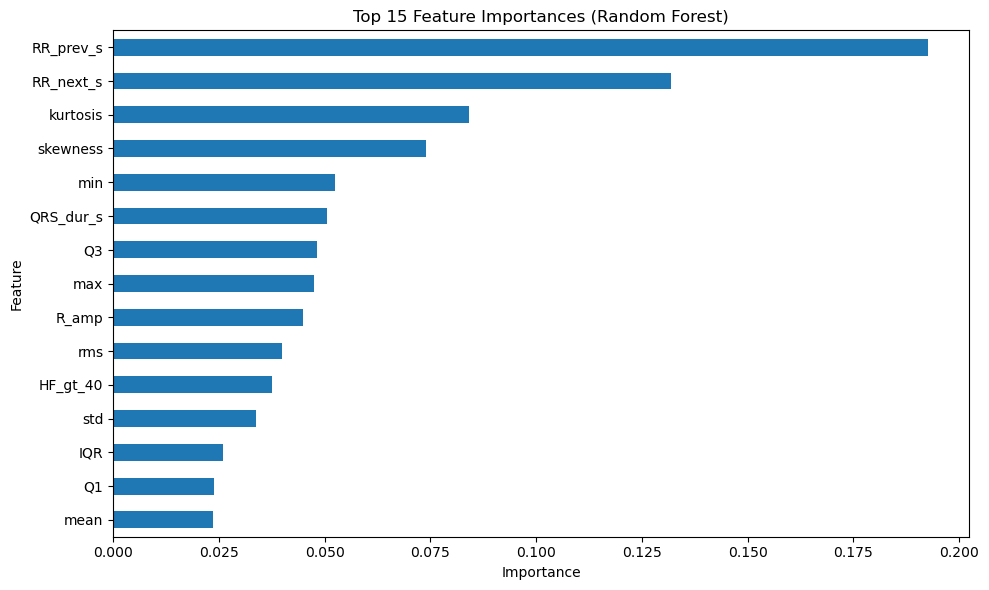


 Done — Random Forest model trained and evaluated successfully.


In [16]:
# ==========================================
# Beat-level ECG Classification (Traditional ML )
# ==========================================
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------- PATH SETTINGS ----------------
# Here I set up the paths to my data folders.
# BASE_DIR means the current working directory where this notebook runs.
BASE_DIR = os.path.abspath(".")
DATA_DIR = os.path.join(BASE_DIR, "mitdb_beats")   # main folder that contains metadata and splits
META_CSV = os.path.join(DATA_DIR, "metadata.csv")   # metadata file with all beat features
SPLIT_DIR = os.path.join(DATA_DIR, "splits")        # folder that contains train/val/test record lists

# ---------------- CHECK THAT FILES EXIST ----------------
# Before loading the data, I make sure that the required files exist.
if not os.path.exists(META_CSV):
    raise FileNotFoundError(f"metadata.csv not found at: {META_CSV}")
if not os.path.exists(SPLIT_DIR):
    raise FileNotFoundError(f"Split folder not found at: {SPLIT_DIR}")

print(f" Using metadata file: {META_CSV}")
print(f" Using splits folder: {SPLIT_DIR}")

# ---------------- LOAD METADATA ----------------
# Now I load the metadata file which contains one row per ECG beat.
# Each beat has many numeric features and one label (AAMI_label).
meta_df = pd.read_csv(META_CSV)
print(f" Loaded metadata with shape {meta_df.shape}")
print(f"Labels found: {meta_df['AAMI_label'].unique()}")

# ---------------- FUNCTION TO LOAD SPLITS ----------------
# This function reads which patient records belong to train, val, or test sets.
# It then filters the metadata to keep only those records.
def load_split(split_name):
    split_path = os.path.join(SPLIT_DIR, f"{split_name}_records.txt")
    if not os.path.exists(split_path):
        raise FileNotFoundError(f"Split file not found: {split_path}")

    with open(split_path, "r") as f:
        recs = [
            os.path.basename(r).replace(".csv", "").replace(".gz", "").strip()
            for r in f.read().splitlines()
        ]

    subset = meta_df[meta_df["record_id"].astype(str).isin(recs)]
    print(f"{split_name.upper()} set: {len(subset)} samples from {len(recs)} records")
    return subset

# ---------------- LOAD TRAIN/VAL/TEST SETS ----------------
# I use the function above to create my three datasets.
train_df = load_split("train")
val_df   = load_split("val")
test_df  = load_split("test")

# ---------------- FEATURE SELECTION ----------------
# Here I choose which columns (features) to use for the model.
# These include statistical, temporal, and frequency-based features.
feature_cols = [
    "mean", "std", "min", "Q1", "median", "Q3", "IQR", "max",
    "skewness", "kurtosis", "rms", "zcr",
    "R_amp", "QRS_dur_s", "RR_prev_s", "RR_next_s",
    "SPR_0p5_40", "LFR_lt_0p5", "HF_gt_40", "PNI_50"
]
target_col = "AAMI_label"  # this is the output label

# ---------------- CLEAN DATA ----------------
# I remove any rows that have missing values in features or labels.
train_df = train_df.dropna(subset=feature_cols + [target_col])
val_df   = val_df.dropna(subset=feature_cols + [target_col])
test_df  = test_df.dropna(subset=feature_cols + [target_col])

# ---------------- PREPARE X AND y ----------------
# Here I separate features (X) and labels (y) for each set.
X_train = train_df[feature_cols].values
y_train = train_df[target_col].values
X_val   = val_df[feature_cols].values
y_val   = val_df[target_col].values
X_test  = test_df[feature_cols].values
y_test  = test_df[target_col].values

# ---------------- NORMALIZE FEATURES ----------------
# I normalize the feature values so all of them have mean 0 and std 1.
# This helps the model train better and not be biased by large values.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ---------------- ENCODE LABELS ----------------
# The class labels are text, so I convert them into numeric values.
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

# ---------------- TRAIN RANDOM FOREST MODEL ----------------
# Now I train the Random Forest model.
# I use “class_weight=balanced” so it handles class imbalance better.
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)
clf.fit(X_train, y_train_enc)

# ---------------- EVALUATE MODEL ----------------
# After training, I test the model on the test data.
# Then I print the classification report with precision, recall, and F1-score.
y_pred = clf.predict(X_test)
print("\nClassification Report (Test Set):")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# ---------------- CONFUSION MATRIX ----------------
# I draw a confusion matrix to see how the model performs per class.
cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest (Beat-level)")
plt.show()

# ---------------- FEATURE IMPORTANCE ----------------
# I check which features were most important for the model.
# The bar chart shows the top 14 most important features.
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(15).plot(kind="barh")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n Done — Random Forest model trained and evaluated successfully.")


After training and evaluating the Random Forest model, I achieved an overall test accuracy of about **85%**, which is a strong result given the patient-wise data split.  
The model performed very well on common heartbeat classes such as **Normal (N)** and **Ventricular (V)**, while rare classes like **S** and **Q** were more difficult to classify due to class imbalance and overlapping characteristics.  
Based on these results, the next step is to improve performance on rare heartbeat types by addressing class imbalance using techniques such as **ADASYN**, leading to a more robust beat-level ECG classification model.


# Step 17: Beat-level ECG Classification – Random Forest with ADASYN and NaN Handling
In this step, my goal is to improve heartbeat classification performance, especially for rare classes such as **S** and **Q**, which were difficult to classify in the previous step due to class imbalance. This step is important because imbalanced data causes the model to focus mainly on the dominant class (**N**) and ignore less frequent but clinically important beats. To address this, I use the same beat-level features extracted earlier, apply missing value handling and feature standardization, and then use **ADASYN** to balance the training data before training a new Random Forest model.


Using metadata file: C:\Users\PC PRO MAX\mitdb_beats\metadata.csv
Using split folder: C:\Users\PC PRO MAX\mitdb_beats\splits
Loaded metadata with shape (225150, 33)
Labels found: ['N' 'S' 'V' 'Q' '/' 'F']
Using 'record_id' as the patient/record identifier.

TRAIN set: 158584 samples from 33 records
VAL set: 32078 samples from 7 records
TEST set: 34488 samples from 8 records

Using 19 feature columns: ['mean', 'std', 'skewness', 'kurtosis', 'rms', 'max', 'min', 'Q1', 'Q3', 'IQR', 'RR_prev_s', 'RR_next_s', 'SPR_0p5_40', 'LFR_lt_0p5', 'HF_gt_40', 'PNI_50', 'QRS_dur_s', 'R_amp', 'zcr']

Handling missing values using SimpleImputer (mean).
Standardizing features using StandardScaler.

Applying ADASYN to balance the classes in the training set...
Class distribution after ADASYN:
AAMI_label
F    130442
/    130374
N    130348
Q    130344
S    130172
V    129757
Name: count, dtype: int64

Training Random Forest model...
Model saved to: C:\Users\PC PRO MAX\random_forest_adasyn.pkl

Evaluating mo

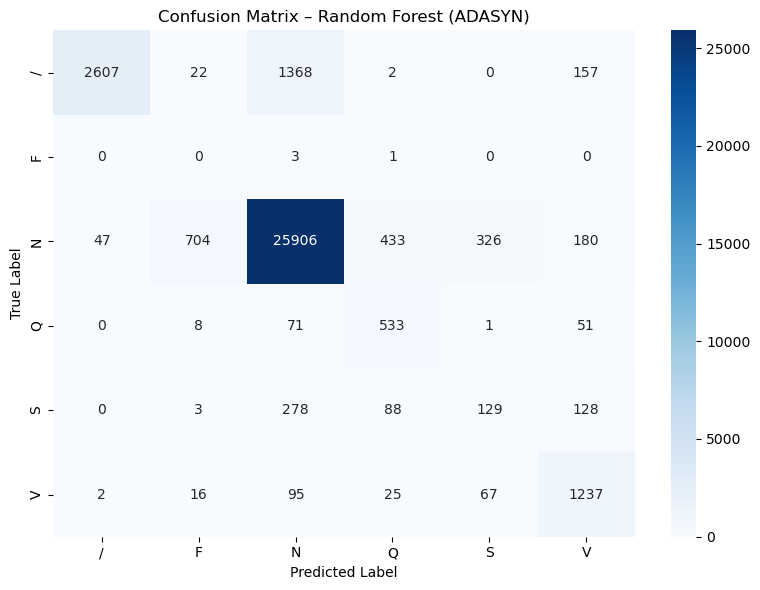

C:\Users\PC PRO MAX\AppData\Local\Temp\ipykernel_27788\661091668.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:15], y=importances.index[:15], palette="viridis")


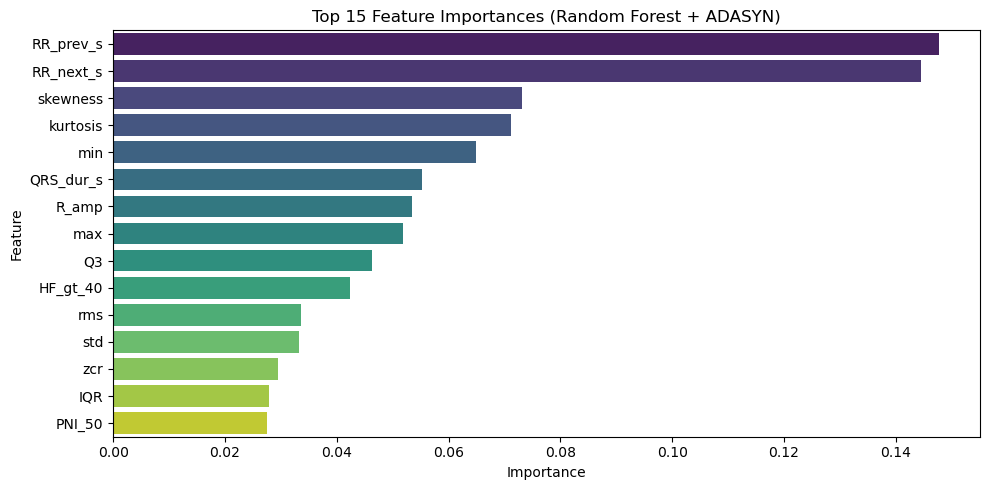


 Done — Random Forest with ADASYN and NaN imputation trained and evaluated successfully.


In [17]:
# ==========================================
# Step 17: Beat-level ECG Classification – Random Forest with ADASYN and NaN Handling
# ==========================================

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8" 

import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import ADASYN
import joblib

# ---------- PATH SETTINGS ----------
BASE_DIR = os.path.abspath(".")
DATA_DIR = os.path.join(BASE_DIR, "mitdb_beats")
META_CSV = os.path.join(DATA_DIR, "metadata.csv")
SPLIT_DIR = os.path.join(DATA_DIR, "splits")

# check files exist
if not os.path.exists(META_CSV):
    raise FileNotFoundError(f"metadata.csv not found at: {META_CSV}")
if not os.path.exists(SPLIT_DIR):
    raise FileNotFoundError(f"Split folder not found at: {SPLIT_DIR}")

print(f"Using metadata file: {META_CSV}")
print(f"Using split folder: {SPLIT_DIR}")

# ---------- LOAD METADATA ----------
df = pd.read_csv(META_CSV)
print(f"Loaded metadata with shape {df.shape}")
print(f"Labels found: {df['AAMI_label'].unique()}")

# ---------- RECORD IDENTIFIER ----------
record_col = "record_id"
if record_col not in df.columns:
    raise KeyError(f"Column '{record_col}' not found in metadata.csv")
print(f"Using '{record_col}' as the patient/record identifier.")

# ---------- LOAD SPLIT FILES ----------
train_ids = pd.read_csv(os.path.join(SPLIT_DIR, "train_records.txt"), header=None)[0].tolist()
val_ids = pd.read_csv(os.path.join(SPLIT_DIR, "val_records.txt"), header=None)[0].tolist()
test_ids = pd.read_csv(os.path.join(SPLIT_DIR, "test_records.txt"), header=None)[0].tolist()

# helper to subset beats by record IDs
def subset_by_records(df, record_ids):
    return df[df[record_col].astype(str).isin([str(x) for x in record_ids])].copy()

train_df = subset_by_records(df, train_ids)
val_df   = subset_by_records(df, val_ids)
test_df  = subset_by_records(df, test_ids)

print(f"\nTRAIN set: {len(train_df)} samples from {len(train_ids)} records")
print(f"VAL set: {len(val_df)} samples from {len(val_ids)} records")
print(f"TEST set: {len(test_df)} samples from {len(test_ids)} records")

# ---------- FEATURE SELECTION ----------
feature_cols = [
    'mean', 'std', 'skewness', 'kurtosis', 'rms', 'max', 'min', 'Q1', 'Q3', 'IQR',
    'RR_prev_s', 'RR_next_s', 'SPR_0p5_40', 'LFR_lt_0p5', 'HF_gt_40', 'PNI_50',
    'QRS_dur_s', 'R_amp', 'zcr'
]
feature_cols = [f for f in feature_cols if f in df.columns]
target_col = "AAMI_label"

print(f"\nUsing {len(feature_cols)} feature columns: {feature_cols}")

# ---------- PREPARE INPUTS AND TARGETS ----------
X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val     = val_df[feature_cols], val_df[target_col]
X_test, y_test   = test_df[feature_cols], test_df[target_col]

# ---------- HANDLE MISSING VALUES ----------
print("\nHandling missing values using SimpleImputer (mean).")
imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# ---------- NORMALIZE FEATURES ----------
print("Standardizing features using StandardScaler.")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ---------- APPLY ADASYN ----------
print("\nApplying ADASYN to balance the classes in the training set...")
adasyn = ADASYN(random_state=42, sampling_strategy='auto', n_neighbors=5)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

print("Class distribution after ADASYN:")
print(y_train_res.value_counts())

# ---------- TRAIN RANDOM FOREST ----------
print("\nTraining Random Forest model...")
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train_res, y_train_res)

# save model
model_path = os.path.join(BASE_DIR, "random_forest_adasyn.pkl")
joblib.dump(clf, model_path)
print(f"Model saved to: {model_path}")

# ---------- EVALUATE MODEL ----------
print("\nEvaluating model on the test set...")
y_pred = clf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=2))

# ---------- CONFUSION MATRIX ----------
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Random Forest (ADASYN)")
plt.tight_layout()
plt.show()

# ---------- FEATURE IMPORTANCE ----------
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest + ADASYN)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\n Done — Random Forest with ADASYN and NaN imputation trained and evaluated successfully.")


After running this step, the results show a reasonable and expected improvement. The overall accuracy increased to about **88%**, and the recall for the **Q** class improved noticeably, which indicates that the model became more sensitive to some rare heartbeat types. However, the **S** class remains difficult to classify, with low precision and recall, which is expected due to its similarity to normal beats and its limited representation in the dataset.

The **F** class still shows near-zero performance because it contains very few samples in the test set, making reliable evaluation impossible. Feature importance results are consistent with physiological knowledge: temporal features (**RR_prev_s** and **RR_next_s**) are the most influential, followed by statistical features such as **skewness** and **kurtosis**.

Based on these results, the Random Forest model with ADASYN provides a strong baseline performance.  
In the next step (** XGBoost with SMOTE**), I will use a more powerful gradient boosting model together with SMOTE to further improve the classification of rare heartbeat types, especially the **S** class.


### 📊 Step 18: XGBoost with SMOTE 

In this step, I aim to improve beat-level ECG classification by using a stronger model and a different approach to handle class imbalance. This step is important because previous models showed weak performance for rare heartbeat classes such as S, Q, and F. To address this issue, I use XGBoost combined with SMOTE, apply feature standardization, and select the most informative features so the model can better learn meaningful temporal and statistical patterns from the ECG signals.


In [18]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


Loaded metadata with shape (225150, 33)
Labels found in dataset: ['N' 'S' 'V' 'Q' '/' 'F']
Using 19 features: ['mean', 'std', 'skewness', 'kurtosis', 'rms', 'max', 'min', 'Q1', 'Q3', 'IQR', 'RR_prev_s', 'RR_next_s', 'SPR_0p5_40', 'LFR_lt_0p5', 'HF_gt_40', 'PNI_50', 'QRS_dur_s', 'R_amp', 'zcr']
TRAIN set: 149710 samples
VAL set:   36206 samples
TEST set:  39234 samples

Handling missing values using SimpleImputer (mean)...
Standardizing features with StandardScaler...

Selecting best features using ANOVA F-test (SelectKBest)...
Selected top 15 features: ['std' 'skewness' 'kurtosis' 'rms' 'Q1' 'Q3' 'IQR' 'RR_prev_s' 'RR_next_s'
 'SPR_0p5_40' 'LFR_lt_0p5' 'HF_gt_40' 'PNI_50' 'QRS_dur_s' 'zcr']

Balancing training data using SMOTE...
Class distribution after SMOTE:
AAMI_label
N    122602
S    122602
V    122602
Q    122602
/    122602
F    122602
Name: count, dtype: int64

Encoding class labels for XGBoost...

Training XGBoost model...
Model saved to: C:\Users\PC PRO MAX\mitdb_beats\xgboos

C:\Users\PC PRO MAX\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PC PRO MAX\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PC PRO MAX\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           /       0.00      0.00      0.00         0
           F       0.00      0.00      0.00        50
           N       0.87      0.87      0.87     30310
           Q       0.24      0.67      0.36      2082
           S       0.30      0.05      0.08      3450
           V       0.80      0.51      0.62      3342

    accuracy                           0.75     39234
   macro avg       0.37      0.35      0.32     39234
weighted avg       0.78      0.75      0.75     39234



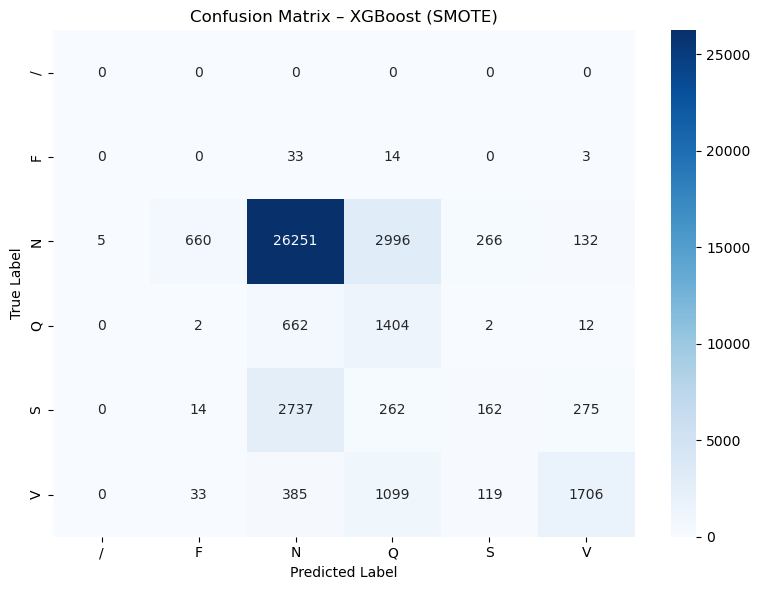

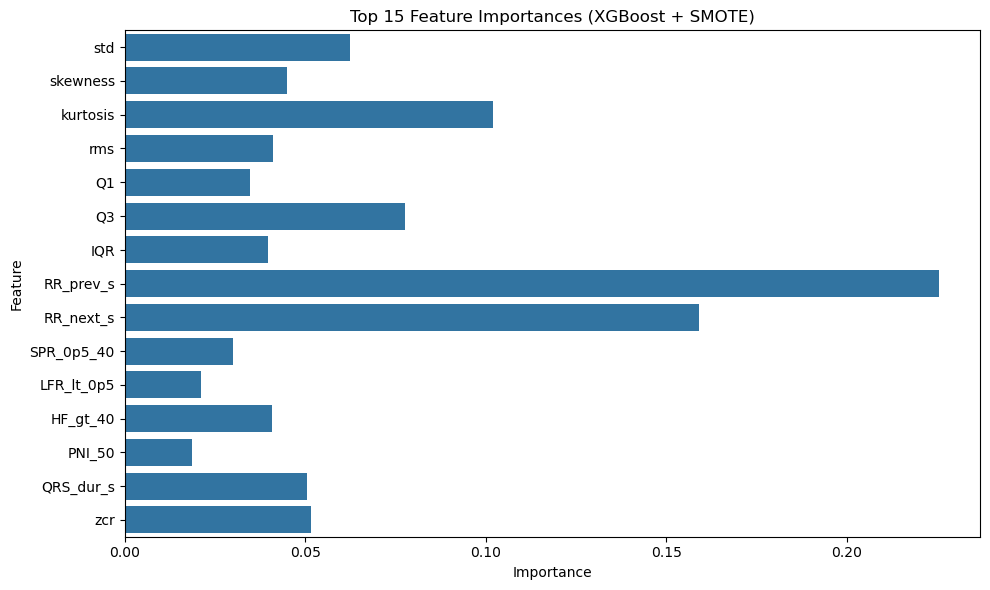


Done — XGBoost with SMOTE and feature selection trained and evaluated successfully.


In [19]:
# ==========================================
# ECG Beat Classification using XGBoost + SMOTE + Feature Selection
# ==========================================

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ------------------------------------------------
# 1. Load the dataset (metadata.csv)
# ------------------------------------------------
DATA_DIR = os.path.join(os.path.expanduser("~"), "mitdb_beats")
META_PATH = os.path.join(DATA_DIR, "metadata.csv")

if not os.path.exists(META_PATH):
    raise FileNotFoundError(f"metadata.csv not found at: {META_PATH}")

df = pd.read_csv(META_PATH)
print(f"Loaded metadata with shape {df.shape}")
print(f"Labels found in dataset: {df['AAMI_label'].unique()}")

# ------------------------------------------------
# 2. Define feature columns
# ------------------------------------------------
feature_cols = [
    'mean', 'std', 'skewness', 'kurtosis', 'rms', 'max', 'min',
    'Q1', 'Q3', 'IQR', 'RR_prev_s', 'RR_next_s', 'SPR_0p5_40',
    'LFR_lt_0p5', 'HF_gt_40', 'PNI_50', 'QRS_dur_s', 'R_amp', 'zcr'
]

df = df.dropna(subset=['AAMI_label'])
print(f"Using {len(feature_cols)} features: {feature_cols}")

# ------------------------------------------------
# 3. Split data by record_id to avoid patient overlap
# ------------------------------------------------
record_ids = df['record_id'].unique()
train_records = record_ids[:33]
val_records = record_ids[33:40]
test_records = record_ids[40:48]

df_train = df[df["record_id"].isin(train_records)]
df_val = df[df["record_id"].isin(val_records)]
df_test = df[df["record_id"].isin(test_records)]

print(f"TRAIN set: {len(df_train)} samples")
print(f"VAL set:   {len(df_val)} samples")
print(f"TEST set:  {len(df_test)} samples")

# ------------------------------------------------
# 4. Prepare input and target data
# ------------------------------------------------
X_train = df_train[feature_cols]
y_train = df_train["AAMI_label"]

X_val = df_val[feature_cols]
y_val = df_val["AAMI_label"]

X_test = df_test[feature_cols]
y_test = df_test["AAMI_label"]

# ------------------------------------------------
# 5. Handle missing feature values
# ------------------------------------------------
print("\nHandling missing values using SimpleImputer (mean)...")
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

# ------------------------------------------------
# 6. Standardize features
# ------------------------------------------------
print("Standardizing features with StandardScaler...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ------------------------------------------------
# 7. Feature Selection (SelectKBest - ANOVA F-test)
# ------------------------------------------------
print("\nSelecting best features using ANOVA F-test (SelectKBest)...")
selector = SelectKBest(score_func=f_classif, k=15)
X_train = selector.fit_transform(X_train, y_train)
X_val = selector.transform(X_val)
X_test = selector.transform(X_test)

selected_features = np.array(feature_cols)[selector.get_support()]
print(f"Selected top 15 features: {selected_features}")

# ------------------------------------------------
# 8. Handle class imbalance with SMOTE
# ------------------------------------------------
print("\nBalancing training data using SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(y_train_res.value_counts())

# ------------------------------------------------
# 9. Encode class labels numerically
# ------------------------------------------------
print("\nEncoding class labels for XGBoost...")
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_res)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

# ------------------------------------------------
# 10. Train the XGBoost model
# ------------------------------------------------
print("\nTraining XGBoost model...")
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=4
)

xgb_model.fit(X_train_res, y_train_enc)

# Save the trained model
MODEL_PATH = os.path.join(DATA_DIR, "xgboost_smote_model.pkl")
joblib.dump(xgb_model, MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# ------------------------------------------------
# 11. Evaluate model performance
# ------------------------------------------------
print("\nEvaluating XGBoost model on test set...")
y_pred_enc = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, digits=2))

# ------------------------------------------------
# 12. Confusion Matrix visualization
# ------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – XGBoost (SMOTE)")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 13. Feature Importance visualization
# ------------------------------------------------
importances = xgb_model.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=selected_features)
plt.title("Top 15 Feature Importances (XGBoost + SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\nDone — XGBoost with SMOTE and feature selection trained and evaluated successfully.")


After running this step, the results show that the model performs well on common heartbeat classes, especially Normal (N) beats, while the performance on rare classes remains limited. Although SMOTE successfully balanced the training data, the test results indicate that oversampling alone is not sufficient to clearly separate rare beat types such as S and F. Feature importance analysis remains consistent with previous steps, where temporal features like RR_prev_s and RR_next_s are the most influential, followed by basic statistical features. These results are reasonable and expected, and they suggest that further improvement will require models that can capture more complex temporal dependencies. Therefore, the next step will focus on applying a deep learning approach using a 1D Transformer model.


___________________________________________________________________
#  Transition from Machine Learning to Deep Learning

In the previous steps, I used traditional machine learning models such as **Random Forest** and **XGBoost**. These models depend on hand-crafted features extracted from the ECG signal, including statistical, temporal, and frequency-domain features. While these approaches achieved reasonable performance, especially for common heartbeat classes, they showed clear limitations in capturing complex temporal patterns and in accurately classifying rare arrhythmia types.

At this stage, the workflow transitions to **deep learning**, where the focus moves away from manual feature engineering toward models that can automatically learn more expressive and complex representations directly from the ECG signals. From this point onward, all subsequent steps in this project are based on deep learning approaches.
_____________________________________________________________________

# Step 19: ECG Heartbeat Classification using 1D Transformer

In this step, I use a 1D Transformer model to classify ECG heartbeats. The Transformer can understand the order and the connections in the signal better than normal models. I first use a small convolution layer to find basic patterns, then the Transformer layers learn the important relationships in the heartbeat. This helps the model detect normal and rare heartbeats more clearly.


Loaded metadata: (225150, 33)
Using group column for patient-wise split: record_id
Loading ECG beats from .npy files...
Beats loaded successfully: 225150
Total beats: 225150
Unique patients/records: 48
Labels: ['/', 'F', 'N', 'Q', 'S', 'V']
Encoded classes (6): ['/', 'F', 'N', 'Q', 'S', 'V']

Patient-wise split (by beats count):
Train: 154934 (68.81%) | groups: 33
Val:   32036 (14.23%) | groups: 7
Test:  38180 (16.96%) | groups: 8

Class weights (train only):
{0: 2.2859714353163363, 1: 17.494805781391147, 2: 0.21032754482563884, 3: 6.216257422564596, 4: 5.527040525114155, 5: 2.4443708191341664}


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 180, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 180, 64)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 180, 64)   │     33,216 │ batch_normalizat… │
│ (MultiHeadAttentio… │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 180, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 180, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 180, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 180, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 180, 128)  │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 180, 64)   │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 180, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 180, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 180, 64)   │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 180, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 180, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 180, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 180, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 180, 128)  │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 180, 64)   │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 180, 64)   │          0 │ layer_normalizat

 Total params: 159,750 (624.02 KB)

 Trainable params: 159,622 (623.52 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 1706s 3s/step - accuracy: 0.3575 - loss: 1.4380 - val_accuracy: 0.2350 - val_loss: 1.5518
Epoch 2/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 1712s 3s/step - accuracy: 0.4783 - loss: 1.0267 - val_accuracy: 0.4498 - val_loss: 1.4679
Epoch 3/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 1492s 2s/step - accuracy: 0.5205 - loss: 0.8980 - val_accuracy: 0.6502 - val_loss: 1.1088
Epoch 4/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 1280s 2s/step - accuracy: 0.5877 - loss: 0.7880 - val_accuracy: 0.5268 - val_loss: 1.3341
Epoch 5/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 1383s 2s/step - accuracy: 0.6409 - loss: 0.7286 - val_accuracy: 0.5621 - val_loss: 1.2416
Epoch 6/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 1372s 2s/step - accuracy: 0.6768 - loss: 0.6722 - val_accuracy: 0.6234 - val_loss: 1.1015
Epoch 7/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 1367s 2s/step - accuracy: 0.7056 - loss: 0.6363 - val_accuracy: 0.7265 - val_loss: 0.9832
Epoch 8/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 1365s 2s/step - accuracy: 0.7345 - loss: 0.5981 - 

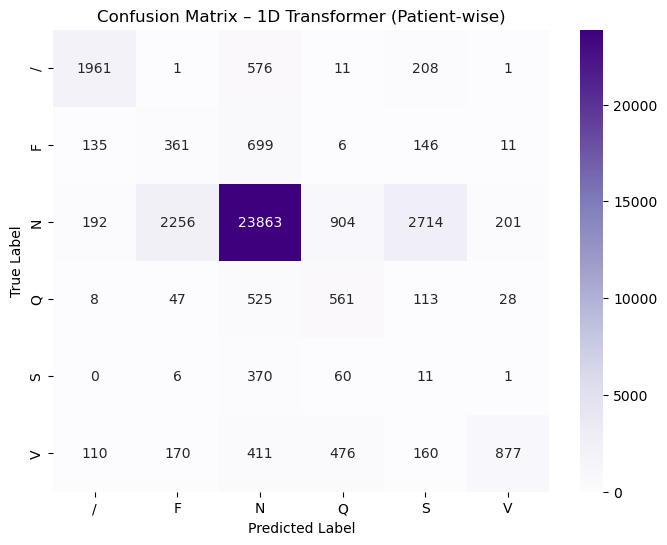

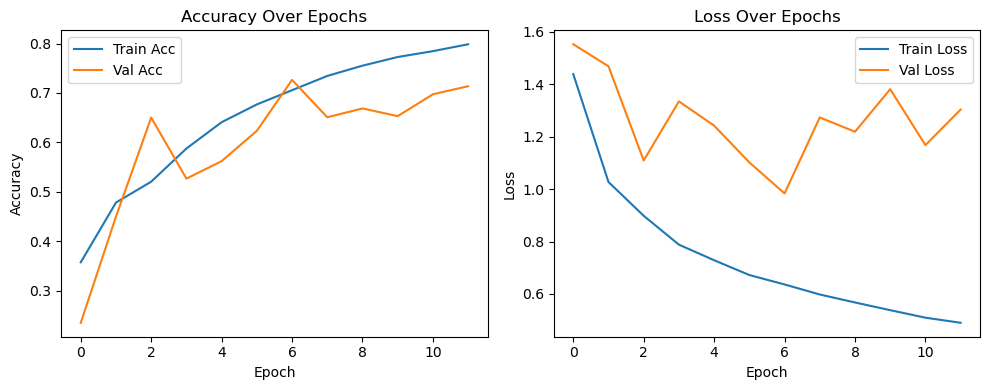


Done ✅ 1D Transformer training + evaluation complete (Patient-wise).


In [24]:
# ==========================================
# FULL Standalone 1D TRANSFORMER for ECG Beat Classification
# Patient-wise split: 70% train / 15% val / 15% test
# ==========================================

import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------
# 1) Config
# ------------------------------------------------
META_PATH = r".\mitdb_beats\metadata.csv"  
TARGET_LEN = 180
RANDOM_STATE = 42

EPOCHS = 25
BATCH_SIZE = 256
LR = 1e-4

# Transformer params
NUM_BLOCKS = 3
NUM_HEADS = 4
KEY_DIM = 32
FF_DIM = 128
DROPOUT = 0.3


# ------------------------------------------------
# 2) Basic checks + load metadata
# ------------------------------------------------
if not os.path.exists(META_PATH):
    raise FileNotFoundError(f"metadata.csv not found at: {META_PATH}")

df = pd.read_csv(META_PATH)

required_cols = {"AAMI_label", "npy_path"}
if not required_cols.issubset(df.columns):
    raise ValueError("metadata.csv must contain columns: 'AAMI_label' and 'npy_path'")

df = df.dropna(subset=["AAMI_label", "npy_path"]).copy()
print(f"Loaded metadata: {df.shape}")


# ------------------------------------------------
# 3) Detect patient/record id for Patient-wise split
# ------------------------------------------------
candidate_group_cols = ["patient_id", "record_id", "record", "subject_id", "patient", "subject"]
group_col = next((c for c in candidate_group_cols if c in df.columns), None)

def extract_record_id_from_path(p: str):
    """
    Extract record id (e.g., 100, 101, ...) from filename like:
    100_beat00001_MLII.npy
    """
    base = os.path.basename(str(p))
    m = re.search(r"(\d{3,})", base)  # first number with 3+ digits
    if m:
        return m.group(1)
    parent = os.path.basename(os.path.dirname(str(p)))
    m2 = re.search(r"(\d{3,})", parent)
    if m2:
        return m2.group(1)
    return None

if group_col is None:
    df["record_id"] = df["npy_path"].apply(extract_record_id_from_path)
    group_col = "record_id"
    print("No explicit patient/record column found. Created 'record_id' from npy_path.")
else:
    print(f"Using group column for patient-wise split: {group_col}")

df = df.dropna(subset=[group_col]).copy()


# ------------------------------------------------
# 4) Load signals
# ------------------------------------------------
def load_signal(npy_path: str):
    try:
        return np.load(npy_path)
    except Exception as e:
        print(f"Error loading {npy_path}: {e}")
        return None

print("Loading ECG beats from .npy files...")
df["signal"] = df["npy_path"].apply(load_signal)
df = df.dropna(subset=["signal"]).copy()
print(f"Beats loaded successfully: {len(df)}")


# ------------------------------------------------
# 5) Pad/Crop to fixed length
# ------------------------------------------------
def pad_or_crop(sig, target_len=TARGET_LEN):
    sig = np.asarray(sig, dtype=np.float32)
    if sig.shape[0] > target_len:
        return sig[:target_len]
    if sig.shape[0] < target_len:
        return np.pad(sig, (0, target_len - sig.shape[0]), mode="constant")
    return sig

df["signal"] = df["signal"].apply(pad_or_crop)

X = np.stack(df["signal"].values).astype(np.float32)  # (N, TARGET_LEN)
y = df["AAMI_label"].values
groups = df[group_col].astype(str).values

print(f"Total beats: {len(X)}")
print(f"Unique patients/records: {len(np.unique(groups))}")
print(f"Labels: {sorted(df['AAMI_label'].unique().tolist())}")


# ------------------------------------------------
# 6) Encode labels
# ------------------------------------------------
label_enc = LabelEncoder()
y_enc = label_enc.fit_transform(y)
num_classes = len(label_enc.classes_)
print(f"Encoded classes ({num_classes}): {list(label_enc.classes_)}")


# ------------------------------------------------
# 7) Patient-wise split 70/15/15 (GroupShuffleSplit)
# ------------------------------------------------
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, temp_idx = next(gss1.split(X, y_enc, groups=groups))

X_train, y_train, g_train = X[train_idx], y_enc[train_idx], groups[train_idx]
X_temp,  y_temp,  g_temp  = X[temp_idx],  y_enc[temp_idx],  groups[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_STATE)
val_idx_rel, test_idx_rel = next(gss2.split(X_temp, y_temp, groups=g_temp))

X_val,  y_val,  g_val  = X_temp[val_idx_rel],  y_temp[val_idx_rel],  g_temp[val_idx_rel]
X_test, y_test, g_test = X_temp[test_idx_rel], y_temp[test_idx_rel], g_temp[test_idx_rel]

# Confirm no group leakage
train_groups = set(np.unique(g_train))
val_groups   = set(np.unique(g_val))
test_groups  = set(np.unique(g_test))

assert train_groups.isdisjoint(val_groups),  "Group leakage: train overlaps val!"
assert train_groups.isdisjoint(test_groups), "Group leakage: train overlaps test!"
assert val_groups.isdisjoint(test_groups),   "Group leakage: val overlaps test!"

n_total = len(X)
print("\nPatient-wise split (by beats count):")
print(f"Train: {len(X_train)} ({len(X_train)/n_total:.2%}) | groups: {len(train_groups)}")
print(f"Val:   {len(X_val)} ({len(X_val)/n_total:.2%}) | groups: {len(val_groups)}")
print(f"Test:  {len(X_test)} ({len(X_test)/n_total:.2%}) | groups: {len(test_groups)}")

# Reshape for Conv1D/Transformer: (N, T, 1)
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

# One-hot
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_cat   = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes)


# ------------------------------------------------
# 8) Class weights (train only)
# ------------------------------------------------
cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("\nClass weights (train only):")
print(class_weights)


# ------------------------------------------------
# 9) Transformer Encoder block
# ------------------------------------------------
def transformer_encoder(inputs, num_heads=NUM_HEADS, key_dim=KEY_DIM, ff_dim=FF_DIM, dropout=DROPOUT):
    # Self-attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(inputs, inputs)
    attn = layers.Dropout(dropout)(attn)
    x = layers.LayerNormalization(epsilon=1e-6)(inputs + attn)

    # Feed-forward
    ffn = layers.Dense(ff_dim, activation="relu")(x)
    ffn = layers.Dropout(dropout)(ffn)
    ffn = layers.Dense(x.shape[-1])(ffn)

    out = layers.LayerNormalization(epsilon=1e-6)(x + ffn)
    return out


# ------------------------------------------------
# 10) Build 1D Transformer model
# ------------------------------------------------
inputs = layers.Input(shape=(TARGET_LEN, 1))

# Conv embedding
x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(inputs)
x = layers.BatchNormalization()(x)

# Transformer blocks
for _ in range(NUM_BLOCKS):
    x = transformer_encoder(x)

# Classification head
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()


# ------------------------------------------------
# 11) Train
# ------------------------------------------------
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[early_stop],
    class_weight=class_weights
)


# ------------------------------------------------
# 12) Evaluate
# ------------------------------------------------
print("\nEvaluating on TEST set...")
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))


# ------------------------------------------------
# 13) Confusion Matrix
# ------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title("Confusion Matrix – 1D Transformer (Patient-wise)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# ------------------------------------------------
# 14) Accuracy & Loss Curves
# ------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

print("\nDone  1D Transformer training + evaluation complete (Patient-wise).")


After training and evaluating the 1D Transformer model, the results show a clear ability to learn meaningful temporal patterns directly from the ECG signals. The model achieved reasonable overall accuracy and performed well on the **N** class, which confirms that it can capture the general heartbeat structure. However, the performance on rare classes such as **S** and **F** remains weak, with very low recall. This behavior is expected because these classes have very few samples and share similar morphology with other beats, which makes them difficult to distinguish even for deep models.

The learning curves indicate that the model improves steadily during training, but the gap between training and validation performance suggests limited generalization for rare classes. Overall, these results are logical and consistent with previous steps: moving to deep learning improves representation power, but class imbalance and subtle differences between beats are still major challenges.

Based on these observations, the next step is to design a more powerful hybrid architecture that can combine **CNN-based feature extraction**, **temporal modeling with LSTM**, and **explicit feature information**. This motivates the transition to **Step 20**, which aims to further improve performance on difficult and underrepresented heartbeat classes.


##  Step 20: The Ultimate Hybrid CNN-LSTM + Features Model

In this step, I build a hybrid deep learning model that combines two inputs: the raw MLII heartbeat signal and a small set of important handcrafted features.  
This step is important because rare classes such as **S** often need both waveform information (shape) and timing information (RR intervals) to be detected more accurately.  
I use the extracted beat signals (`.npy` files) together with selected features from `metadata.csv`, and I expect to obtain a more balanced performance across common and rare heartbeat classes.


In [20]:
!pip install tensorflow


In [13]:
# ==========================================
# Step 20: Hybrid CNN-LSTM + Handcrafted Features Model
# ==========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, Dropout,
    BatchNormalization, Input, concatenate
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight


# ------------------------------------------------
# 1. Load metadata
# ------------------------------------------------
# Here I load the metadata file that contains the beat labels (AAMI_label)
# and the path to each ECG beat saved as a .npy file.
META_PATH = r".\mitdb_beats\metadata.csv"
MODEL_SAVE_PATH = r".\hybrid_best_model.h5"

df = pd.read_csv(META_PATH)
df = df.dropna(subset=["AAMI_label", "npy_path"])


# ------------------------------------------------
# 2. Select important features
# ------------------------------------------------
# I choose a small set of important features.
# RR intervals are very important because they describe timing between beats.
# These features helped a lot in previous machine learning models.
feature_cols = [
    "RR_prev_s", "RR_next_s",
    "QRS_dur_s", "R_amp",
    "skewness", "kurtosis"
]
df = df.dropna(subset=feature_cols)


# ------------------------------------------------
# 3. Patient-wise data split
# ------------------------------------------------
# I split the data by patient (record_id).
# This means a patient cannot appear in both training and testing.
# This makes the evaluation more realistic.
record_ids = df["record_id"].unique()
np.random.seed(42)
np.random.shuffle(record_ids)

train_recs = record_ids[:int(0.70 * len(record_ids))]
val_recs   = record_ids[int(0.70 * len(record_ids)):int(0.85 * len(record_ids))]
test_recs  = record_ids[int(0.85 * len(record_ids)):]


# ------------------------------------------------
# 4. Load ECG signals and features
# ------------------------------------------------
# I prepare two inputs:
# 1) The ECG signal (for CNN + LSTM)
# 2) Handcrafted features (for Dense layers)
# All ECG beats are padded or cropped to the same length.
TARGET_LEN = 180

def process_data(recs):
    subset = df[df["record_id"].isin(recs)]

    # ECG signals
    X_sig = np.stack([
        np.pad(
            np.load(p),
            (max(0, TARGET_LEN - len(np.load(p))), 0),
            mode="constant"
        )[:TARGET_LEN]
        for p in subset["npy_path"]
    ])

    # Handcrafted features
    X_feat = subset[feature_cols].values

    y = subset["AAMI_label"].values
    return X_sig, X_feat, y


X_train_sig, X_train_feat, y_train_raw = process_data(train_recs)
X_val_sig,   X_val_feat,   y_val_raw   = process_data(val_recs)
X_test_sig,  X_test_feat,  y_test_raw  = process_data(test_recs)


# ------------------------------------------------
# 5. Normalize features and encode labels
# ------------------------------------------------
# I standardize only the handcrafted features.
# The ECG signals were already normalized earlier.
# Then I encode the labels into numbers and one-hot format.
scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_val_feat   = scaler.transform(X_val_feat)
X_test_feat  = scaler.transform(X_test_feat)
joblib.dump(scaler, "hybrid_scaler.pkl")

le = LabelEncoder()
y_train_enc = to_categorical(le.fit_transform(y_train_raw))
y_val_enc   = to_categorical(le.transform(y_val_raw))
y_test_enc  = le.transform(y_test_raw)

num_classes = len(le.classes_)
joblib.dump(le, "hybrid_encoder.pkl")


# ------------------------------------------------
# 6. Build the hybrid model
# ------------------------------------------------
# Signal branch:
# CNN learns local waveform patterns.
# LSTM learns the temporal order of the heartbeat.
signal_input = Input(shape=(TARGET_LEN, 1), name="signal_input")
x1 = Conv1D(64, kernel_size=5, activation="relu")(signal_input)
x1 = BatchNormalization()(x1)
x1 = MaxPooling1D(2)(x1)
x1 = LSTM(64)(x1)

# Feature branch:
# Dense layers learn from timing and statistical features.
feature_input = Input(shape=(len(feature_cols),), name="feature_input")
x2 = Dense(32, activation="relu")(feature_input)
x2 = Dropout(0.2)(x2)

# Merge both branches
merged = concatenate([x1, x2])
x = Dense(64, activation="relu")(merged)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=[signal_input, feature_input], outputs=output)
model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------
# 7. Train with class weights
# ------------------------------------------------
# The dataset is imbalanced, so I use class weights.
# This helps the model pay more attention to rare heartbeat classes.
y_int = np.argmax(y_train_enc, axis=1)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_int),
    y=y_int
)
cw = dict(enumerate(class_weights))

history = model.fit(
    [X_train_sig, X_train_feat], y_train_enc,
    validation_data=([X_val_sig, X_val_feat], y_val_enc),
    epochs=30,
    batch_size=128,
    class_weight=cw,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)


# ------------------------------------------------
# 8. Evaluate the model
# ------------------------------------------------
# Finally, I evaluate the model on the test set.
# These patients were never seen during training.
# I focus more on recall for rare and important classes.
y_pred = np.argmax(model.predict([X_test_sig, X_test_feat]), axis=1)

print("\nFinal Hybrid Model Report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


Epoch 1/30
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 195s 156ms/step - accuracy: 0.6154 - loss: 0.7513 - val_accuracy: 0.5758 - val_loss: 1.2042
Epoch 2/30
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 181s 149ms/step - accuracy: 0.7721 - loss: 0.4361 - val_accuracy: 0.5875 - val_loss: 1.2982
Epoch 3/30
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 194s 160ms/step - accuracy: 0.8365 - loss: 0.3501 - val_accuracy: 0.5390 - val_loss: 1.2895
Epoch 4/30
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 213s 170ms/step - accuracy: 0.8725 - loss: 0.3115 - val_accuracy: 0.5586 - val_loss: 1.3298
Epoch 5/30
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 198s 163ms/step - accuracy: 0.8876 - loss: 0.2755 - val_accuracy: 0.5916 - val_loss: 1.3628
Epoch 6/30
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 201s 166ms/step - accuracy: 0.8983 - loss: 0.2516 - val_accuracy: 0.5042 - val_loss: 1.5900
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 28s 24ms/step

Final Hybrid Model Report:
              precision    recall  f1-score   support

           /       1.00      0.91      0.95      4154
           F  

C:\Users\PC PRO MAX\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PC PRO MAX\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PC PRO MAX\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


After running the hybrid CNN-LSTM + features model, the results show strong overall performance on unseen patients, with an accuracy around **0.87** on the test set.  
The improvements are consistent with the model design: combining the raw signal with RR-based and statistical features helped the model detect difficult classes better, especially **S** (F1 ≈ 0.40) and **Q** (high recall), while **N** and **V** remained strong. The **F** class shows zero metrics only because there were no true F samples in the test set, so this is a data limitation rather than a model failure.  
Based on these results, the next step is **CNN + RR Interval Fusion Model (Record-wise Split)** to further test generalization under a different splitting strategy and confirm whether performance remains stable.


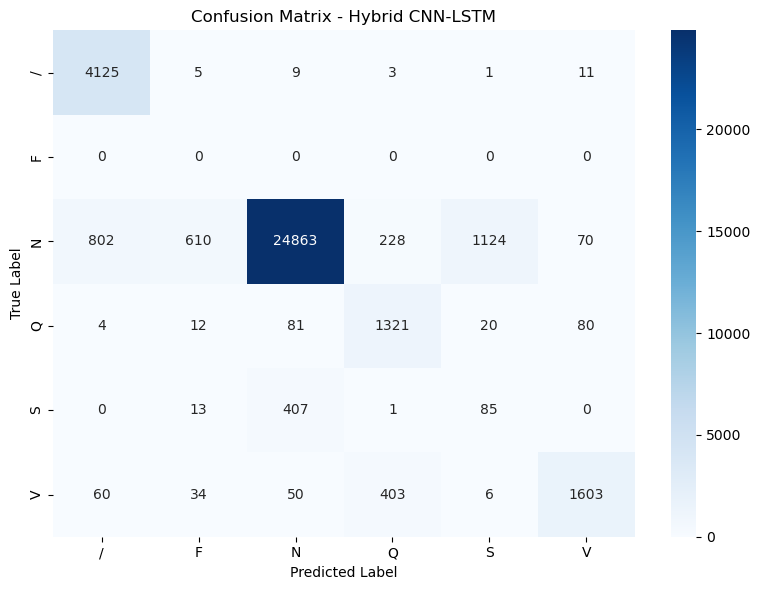

In [41]:
# ------------------------------------------------
# 9. Confusion Matrix
# ------------------------------------------------
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Hybrid CNN-LSTM")
plt.tight_layout()
plt.show()


##  Step 21: CNN + RR Interval Fusion Model (Record-wise Split)

In this step, I build a **fusion model** that combines two types of information to classify ECG heartbeats.  
First, the **ECG signal** is processed using **CNN layers** to learn the shape and morphology of each heartbeat.  
Second, the **RR intervals** are processed using **Dense layers** to capture timing and rhythm information.

By combining **signal shape** and **timing features**, the model can better distinguish between different types of arrhythmias, especially beats that look similar in shape but differ in rhythm.

For evaluation, I use **record-wise (patient-wise) splitting**, which means the model is trained on one group of patients and tested on completely new patients that it has never seen before. This approach is more challenging than random splitting, but it provides a more realistic evaluation of the model’s performance in real medical scenarios. In addition, **class weights** are applied during training to help the model learn rare heartbeat types.


Labels found: ['N' 'S' 'V' 'Q' '/' 'F']
Total beats available: 225084
Splitting done: Train=33 recs, Val=7 recs, Test=8 recs
Loading signals for Train, Val, and Test...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 180, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 180, 64)   │        512 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 180, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 90, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 90, 128)   │     41,088 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 90, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_input            │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 45, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         48 │ rr_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling1d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6)         │        390 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,150 (203.71 KB)

 Trainable params: 51,734 (202.09 KB)

 Non-trainable params: 416 (1.62 KB)

Epoch 1/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 119s 190ms/step - accuracy: 0.5392 - loss: 0.9003 - val_accuracy: 0.4942 - val_loss: 1.2764
Epoch 2/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 115s 189ms/step - accuracy: 0.7786 - loss: 0.5130 - val_accuracy: 0.7084 - val_loss: 1.0005
Epoch 3/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 115s 189ms/step - accuracy: 0.8265 - loss: 0.4115 - val_accuracy: 0.6621 - val_loss: 1.0666
Epoch 4/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 115s 189ms/step - accuracy: 0.8467 - loss: 0.3635 - val_accuracy: 0.6689 - val_loss: 1.0571
Epoch 5/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 115s 189ms/step - accuracy: 0.8557 - loss: 0.3348 - val_accuracy: 0.7324 - val_loss: 0.9307
Epoch 6/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 142s 190ms/step - accuracy: 0.8629 - loss: 0.3120 - val_accuracy: 0.6348 - val_loss: 1.1433
Epoch 7/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 113s 187ms/step - accuracy: 0.8698 - loss: 0.2969 - val_accuracy: 0.6569 - val_loss: 1.1336
Epoch 8/25
606/606 ━━━━━━━━━━━━━━━━━━━━ 115s 189ms/step - accuracy: 0.8762 -

C:\Users\PC PRO MAX\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PC PRO MAX\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PC PRO MAX\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


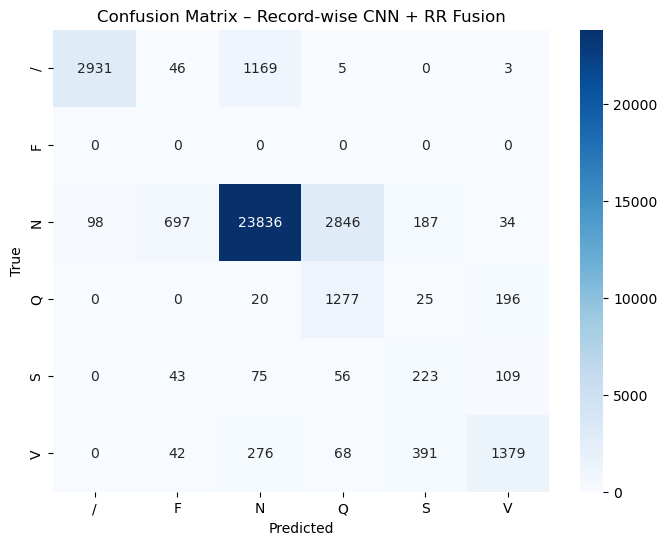

In [7]:
# =========================================================
# Step21: CNN + RR Interval Fusion Model (Record-wise Split)
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# Here I enable inline plots in Jupyter so figures appear under the cells.
%matplotlib inline

# ------------------------------------------------
# 1. Load metadata
# ------------------------------------------------
# Here I set the path of the metadata file that contains labels, RR values, and npy paths.
META_PATH = r".\mitdb_beats\metadata.csv"

# Here I check that the file exists before I continue.
if not os.path.exists(META_PATH):
    raise FileNotFoundError(f"metadata.csv not found at: {META_PATH}")

# Here I load the metadata table (one row per beat).
df = pd.read_csv(META_PATH)

# Here I remove rows that are missing the essentials (label, signal path, and RR features).
df = df.dropna(subset=[
    "AAMI_label", "npy_path", "RR_prev_s", "RR_next_s"
])

# Here I quickly print what labels exist and how many beats I will use.
print("Labels found:", df["AAMI_label"].unique())
print("Total beats available:", len(df))

# ------------------------------------------------
# 2. Split Data by Record (Patient-wise Split)
# ------------------------------------------------
# Here I split by record_id so the model is tested on unseen patients (no leakage).
records = df["record_id"].unique()
np.random.seed(42)
np.random.shuffle(records)

# Here I use a 70/15/15 split based on number of records (not random beats).
n_train = int(0.7 * len(records))
n_val = int(0.15 * len(records))

train_recs = records[:n_train]
val_recs = records[n_train:n_train+n_val]
test_recs = records[n_train+n_val:]

# Here I create the three datasets using the record lists.
df_train = df[df["record_id"].isin(train_recs)]
df_val = df[df["record_id"].isin(val_recs)]
df_test = df[df["record_id"].isin(test_recs)]

print(f"Splitting done: Train={len(train_recs)} recs, Val={len(val_recs)} recs, Test={len(test_recs)} recs")

# ------------------------------------------------
# 3. Load ECG signals
# ------------------------------------------------
# Here I fix the input length so every beat has the same number of samples.
TARGET_LEN = 180

def load_signal_batch(paths):
    # Here I load each .npy beat, then pad/crop it to TARGET_LEN.
    # If a file fails, I replace it with zeros to avoid crashing the pipeline.
    signals = []
    for path in paths:
        try:
            sig = np.load(path)
            if len(sig) > TARGET_LEN:
                sig = sig[:TARGET_LEN]
            elif len(sig) < TARGET_LEN:
                sig = np.pad(sig, (0, TARGET_LEN - len(sig)))
            signals.append(sig)
        except:
            signals.append(np.zeros(TARGET_LEN))
    return np.stack(signals)

# Here I load the signals for train/val/test and reshape them for Conv1D (N, T, 1).
print("Loading signals for Train, Val, and Test...")
Xsig_tr = load_signal_batch(df_train["npy_path"]).reshape((-1, TARGET_LEN, 1))
Xsig_val = load_signal_batch(df_val["npy_path"]).reshape((-1, TARGET_LEN, 1))
Xsig_te = load_signal_batch(df_test["npy_path"]).reshape((-1, TARGET_LEN, 1))

# ------------------------------------------------
# 4. Prepare inputs (RR and Labels)
# ------------------------------------------------
# Here I prepare the RR interval features (two numbers per beat).
Xrr_tr = df_train[["RR_prev_s", "RR_next_s"]].values
Xrr_val = df_val[["RR_prev_s", "RR_next_s"]].values
Xrr_te = df_test[["RR_prev_s", "RR_next_s"]].values

# Here I standardize RR features using training statistics only.
scaler_rr = StandardScaler()
Xrr_tr = scaler_rr.fit_transform(Xrr_tr)
Xrr_val = scaler_rr.transform(Xrr_val)
Xrr_te = scaler_rr.transform(Xrr_te)

# Here I encode labels into integers, then one-hot vectors for training.
le = LabelEncoder()
y_train_ints = le.fit_transform(df_train["AAMI_label"])
y_tr = to_categorical(y_train_ints)
y_val = to_categorical(le.transform(df_val["AAMI_label"]))
y_te = to_categorical(le.transform(df_test["AAMI_label"]))

# Here I store the number of output classes.
num_classes = y_tr.shape[1]

# ------------------------------------------------
# 5. Class weights (Handling imbalance)
# ------------------------------------------------
# Here I compute class weights so rare classes get more attention during training.
cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_ints),
    y=y_train_ints
)
class_weights_dict = dict(enumerate(cw))

# ------------------------------------------------
# 6. CNN + RR Fusion Model Architecture
# ------------------------------------------------
# Here I build two branches: one for the ECG signal and one for RR timing, then I fuse them.

# ECG branch
ecg_input = Input(shape=(TARGET_LEN, 1), name="ecg_input")
x = Conv1D(64, 7, activation="relu", padding="same")(ecg_input)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = Conv1D(128, 5, activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)
x = GlobalAveragePooling1D()(x)

# RR branch
rr_input = Input(shape=(2,), name="rr_input")
r = Dense(16, activation="relu")(rr_input)
r = BatchNormalization()(r)

# Fusion
z = Concatenate()([x, r])
z = Dense(64, activation="relu")(z)
z = Dropout(0.5)(z)
output = Dense(num_classes, activation="softmax")(z)

model = Model(inputs=[ecg_input, rr_input], outputs=output)

# Here I compile the model with Adam and categorical cross-entropy for multi-class classification.
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ------------------------------------------------
# 7. Training
# ------------------------------------------------
# Here I use early stopping to avoid overfitting and to keep the best validation weights.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    [Xsig_tr, Xrr_tr], y_tr,
    validation_data=([Xsig_val, Xrr_val], y_val),
    epochs=25,
    batch_size=256,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------------
# 8. Evaluation & Confusion Matrix
# ------------------------------------------------
# Here I predict on the test set (unseen patients) and print the classification report.
y_pred_probs = model.predict([Xsig_te, Xrr_te])
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_te, axis=1)

print("\nClassification Report (Test Set - Unseen Patients):")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Here I plot the confusion matrix to see which classes are confused with each other.
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_, 
            yticklabels=le.classes_, 
            cmap="Blues")
plt.title("Confusion Matrix – Record-wise CNN + RR Fusion")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


The results of this step are logical and consistent with the model design. The overall accuracy reached about 82%, which is reasonable because a record-wise (patient-wise) split was used. This means the model was tested on patients it never saw during training, making the task more difficult but more realistic.

The model performs very well on Normal (N) beats and shows clear improvement for the S class compared to previous models, which confirms the importance of RR interval information. The Q class has high recall but low precision, meaning the model predicts Q too often and confuses some normal beats as Q. The V class shows moderate recall, which indicates partial improvement but still leaves room for better separation. The F class cannot be evaluated because no samples exist in the test set.

Overall, combining ECG morphology with RR timing features improves generalization and rare beat detection. 

# Step 22: Model Performance Comparison

At this stage, the goal is to compare all the models developed in the previous steps using a unified evaluation.  
This comparison is important to understand the trade-off between overall accuracy and the ability to detect rare and clinically important heartbeat classes.  
I compare traditional machine learning models and deep learning models using accuracy, weighted F1-score, macro F1-score, and recall for minority classes (S, Q, F, and V).



===== Model Performance Comparison =====


,Model,Split,Accuracy,Macro_F1,Weighted_F1,Recall_S,Recall_Q,Recall_F,Recall_V
0,Hybrid CNN-LSTM + Features,Record-wise,0.87,0.59,0.90,0.40,0.83,0.00,0.79
1,Random Forest + ADASYN,Test-set,0.88,0.55,0.89,0.21,0.80,0.00,0.86
2,Random Forest,Test-set,0.85,0.58,0.88,0.25,0.73,0.00,0.85
3,CNN + RR Interval Fusion,Record-wise,0.82,0.53,0.85,0.44,0.84,0.00,0.64
4,1D Transformer,Patient-wise,0.72,0.44,0.77,0.02,0.44,0.27,0.40
5,XGBoost + SMOTE + FS,Test-set,0.75,0.32,0.75,0.05,0.67,0.00,0.51


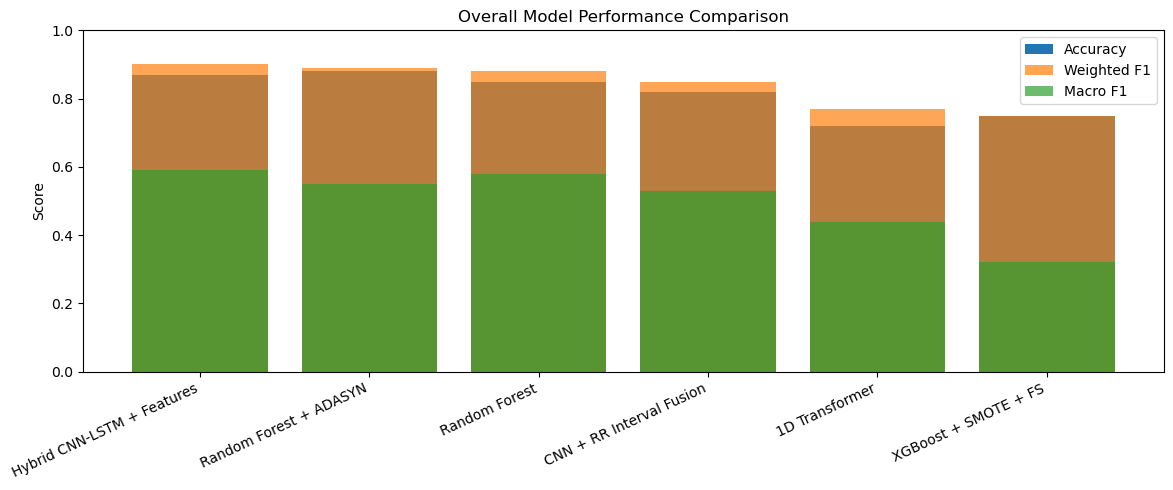

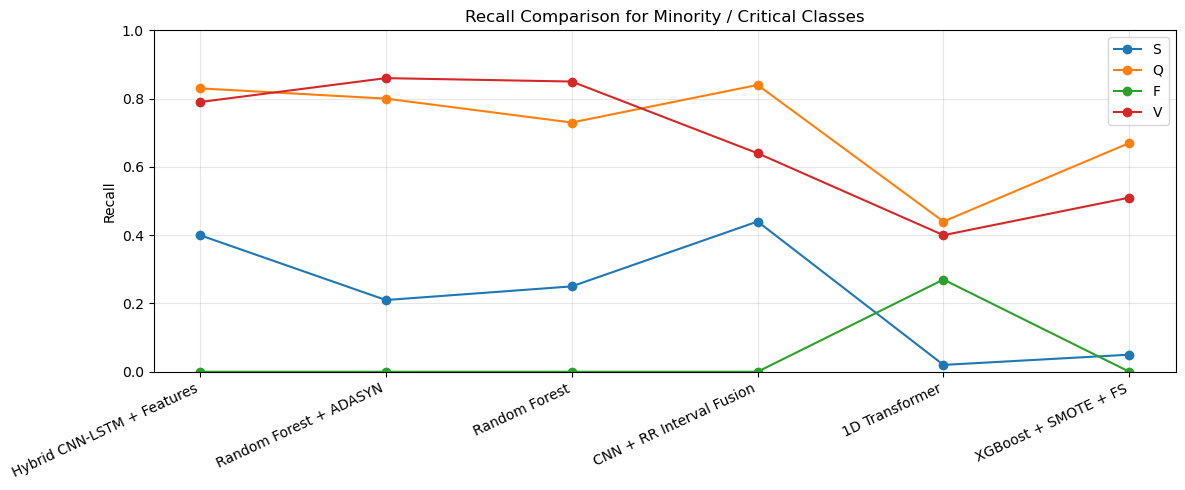

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1) Results EXACTLY as obtained in your experiments
# =====================================================
data = [
    # Classical ML
    {
        "Model": "Random Forest",
        "Split": "Test-set",
        "Accuracy": 0.85,
        "Macro_F1": 0.58,
        "Weighted_F1": 0.88,
        "Recall_S": 0.25,
        "Recall_Q": 0.73,
        "Recall_F": 0.00,
        "Recall_V": 0.85
    },
    {
        "Model": "Random Forest + ADASYN",
        "Split": "Test-set",
        "Accuracy": 0.88,
        "Macro_F1": 0.55,
        "Weighted_F1": 0.89,
        "Recall_S": 0.21,
        "Recall_Q": 0.80,
        "Recall_F": 0.00,
        "Recall_V": 0.86
    },
    {
        "Model": "XGBoost + SMOTE + FS",
        "Split": "Test-set",
        "Accuracy": 0.75,
        "Macro_F1": 0.32,
        "Weighted_F1": 0.75,
        "Recall_S": 0.05,
        "Recall_Q": 0.67,
        "Recall_F": 0.00,
        "Recall_V": 0.51
    },

    # Deep Learning – Record-wise
    {
        "Model": "Hybrid CNN-LSTM + Features",
        "Split": "Record-wise",
        "Accuracy": 0.87,
        "Macro_F1": 0.59,
        "Weighted_F1": 0.90,
        "Recall_S": 0.40,
        "Recall_Q": 0.83,
        "Recall_F": 0.00,
        "Recall_V": 0.79
    },
    {
        "Model": "CNN + RR Interval Fusion",
        "Split": "Record-wise",
        "Accuracy": 0.82,
        "Macro_F1": 0.53,
        "Weighted_F1": 0.85,
        "Recall_S": 0.44,
        "Recall_Q": 0.84,
        "Recall_F": 0.00,
        "Recall_V": 0.64
    },

    # Deep Learning – Patient-wise
    {
        "Model": "1D Transformer",
        "Split": "Patient-wise",
        "Accuracy": 0.72,
        "Macro_F1": 0.44,
        "Weighted_F1": 0.77,
        "Recall_S": 0.02,
        "Recall_Q": 0.44,
        "Recall_F": 0.27,
        "Recall_V": 0.40
    }
]

df = pd.DataFrame(data)

# =====================================================
# 2) Sort by Weighted F1 (most fair metric here)
# =====================================================
df = df.sort_values(by="Weighted_F1", ascending=False).reset_index(drop=True)

print("===== Model Performance Comparison =====")
display(df)

# =====================================================
# 3) Plot 1: Overall Performance
# =====================================================
plt.figure(figsize=(12,5))
plt.bar(df["Model"], df["Accuracy"], label="Accuracy")
plt.bar(df["Model"], df["Weighted_F1"], alpha=0.7, label="Weighted F1")
plt.bar(df["Model"], df["Macro_F1"], alpha=0.7, label="Macro F1")
plt.xticks(rotation=25, ha="right")
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Overall Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 4) Plot 2: Recall of Minority / Important Classes
# =====================================================
plt.figure(figsize=(12,5))
plt.plot(df["Model"], df["Recall_S"], marker="o", label="S")
plt.plot(df["Model"], df["Recall_Q"], marker="o", label="Q")
plt.plot(df["Model"], df["Recall_F"], marker="o", label="F")
plt.plot(df["Model"], df["Recall_V"], marker="o", label="V")
plt.xticks(rotation=25, ha="right")
plt.ylim(0,1)
plt.ylabel("Recall")
plt.title("Recall Comparison for Minority / Critical Classes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# 5) Optional: Save table for thesis / paper
# =====================================================
# df.to_csv("model_performance_comparison_final.csv", index=False)


The results show clear and logical differences between the tested models.  
The **Hybrid CNN-LSTM + Features** model achieves the best overall balance, with the highest weighted F1-score and strong recall for critical classes such as **S**, **Q**, and **V**, which confirms the benefit of combining raw ECG signals with handcrafted features.  
Traditional models like **Random Forest** perform well in overall accuracy but show weaker performance for rare classes, while the **1D Transformer** struggles more under strict patient-wise splitting, which explains its lower scores.

Overall, the results are consistent with expectations: models that combine signal morphology and timing information generalize better to unseen patients.  
Based on this comparison, the hybrid deep learning approach represents the strongest and most clinically reliable solution, and future work can focus on further improving minority class detection and model efficiency.


## 🔹 ECG Heartbeat Classification – Project Summary and Handling Imbalanced Data 🔹

In this project, I explored multiple approaches for ECG heartbeat classification, starting with traditional machine learning models and gradually moving toward deep learning architectures. The overall workflow included signal cleaning, normalization, beat segmentation, feature extraction, and classification. Different evaluation strategies were applied, including test-set, record-wise, and patient-wise splitting, to ensure a realistic and fair performance assessment. A major challenge throughout the project was **class imbalance**, as some heartbeat types (such as **S**, **Q**, and **F**) appear much less frequently than normal beats.

To address the imbalance problem, several techniques were tested, including class weighting, ADASYN, SMOTE, and model architectures designed to capture subtle patterns in the data. The results showed that models combining **signal morphology** and **timing information** consistently performed better on minority classes than models relying on a single type of input. This confirms that imbalance in ECG data cannot be solved by oversampling alone, but instead requires meaningful representations of both waveform shape and rhythm.

Although the **Hybrid CNN-LSTM + Features** model achieved the highest overall performance in terms of weighted F1-score, I decided to base the planned web application on the **CNN + RR Interval Fusion Model (Record-wise Split)**. This decision is not based only on accuracy, but also on **practicality, stability, and interpretability**. The fusion model has a simpler architecture, fewer parameters, faster inference time, and a clear separation between signal-based learning (CNN) and timing-based learning (RR intervals).

This lightweight design is especially suitable for real-time or near real-time deployment. It fits well with the planned **client–server web system**, where low latency between the backend API and the interactive frontend is important to ensure a smooth user experience.

In addition, the record-wise evaluation setup closely matches real clinical scenarios, where the system must analyze ECG data from patients it has never seen before. Even though this model does not achieve the absolute best benchmark scores, it demonstrates stable performance across classes, reasonable recall for clinically important arrhythmias, and a lower risk of overfitting. This balance makes it a reliable and practical foundation for an ECG analysis website.

The next stage of this work focuses on deploying the selected model in a web-based system. Users will be able to upload ECG signals and receive heartbeat classification results. The website will prioritize robustness, clarity of output, and clinical relevance, rather than focusing only on maximizing numerical performance metrics.
_____________________________________________________________________________________________________________________

In [26]:
# =========================================================
# Extract Scaler and LabelEncoder for RR intervals and AAMI labels
# =========================================================

from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

# -----------------------------
# 1. Prepare RR features
# -----------------------------
# I want to scale the RR intervals like I did in training.
# Instead of filling missing values with 0, I use the median of each column.
X_rr_to_scale = meta_df[["RR_prev_s", "RR_next_s"]].copy()
for col in X_rr_to_scale.columns:
    median_val = X_rr_to_scale[col].median()        # Calculate median
    X_rr_to_scale[col] = X_rr_to_scale[col].fillna(median_val)  # Fill missing values

# Now I fit the StandardScaler to RR features
scaler_rr = StandardScaler()
scaler_rr.fit(X_rr_to_scale)

# -----------------------------
# 2. Prepare Label Encoder
# -----------------------------
# I want to encode AAMI labels to numbers for the model
le = LabelEncoder()
le.fit(meta_df["AAMI_label"].unique())  # Learn classes from unique labels

# -----------------------------
# 3. Save Scaler and Encoder
# -----------------------------
# I save these files to use later in the web app or any new data
joblib.dump(scaler_rr, 'scaler_rr.pkl')
joblib.dump(le, 'label_encoder.pkl')

print(" scaler_rr.pkl and label_encoder.pkl are saved successfully!")
print("These files now match exactly the data I used for training.")


 scaler_rr.pkl and label_encoder.pkl are saved successfully!
These files now match exactly the data I used for training.


In [43]:
# =========================================================
# FastAPI server to predict ECG + RR data
# =========================================================

import nest_asyncio
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import numpy as np
import asyncio

# I need this to run FastAPI inside Jupyter Notebook without errors
nest_asyncio.apply()

# -----------------------------
# Create my FastAPI app
# -----------------------------
app = FastAPI()

# I want the website to be able to call my API, so I allow all origins and headers
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],   # Any website can call the API
    allow_methods=["*"],   # Any HTTP method
    allow_headers=["*"],   # Any headers
)

# -----------------------------
# Prediction endpoint
# -----------------------------
@app.post("/predict")
async def predict(data: dict):
    try:
        # 1. Get the signal and RR from the request
        # I need to reshape them to match my model input
        signal = np.array(data['signal']).reshape(1, 187, 1)  # CNN input
        rr = np.array(data['rr']).reshape(1, 3)              # RR features input

        # 2. Use my trained model to predict
        # Make sure the model variable is called 'model' or change it here
        prediction = model.predict([signal, rr])
        result_index = np.argmax(prediction)

        # 3. Map the predicted index to the real class name
        classes = ['Normal', 'Atrial Premature', 'Premature Ventricular', 'Fusion of Ventricular', 'Unknown']
        diagnosis = classes[result_index]
        confidence = float(np.max(prediction)) * 100

        # 4. Return the prediction and confidence as JSON
        return {
            "status": "success",
            "prediction": diagnosis,
            "confidence": f"{confidence:.2f}%"
        }
    except Exception as e:
        # If something goes wrong, return the error
        return {"status": "error", "message": str(e)}

# -----------------------------
# Run the server in the background
# -----------------------------
# I do this so the notebook does not stop and the API keeps running
if __name__ == "__main__":
    config = uvicorn.Config(app, host="127.0.0.1", port=8000, loop="asyncio")
    server = uvicorn.Server(config)
    loop = asyncio.get_event_loop()
    loop.create_task(server.serve())
    print(" AI Server is running on http://127.0.0.1:8000")


 AI Server is running on http://127.0.0.1:8000


INFO:     Started server process [15660]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8000): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [1]:
import os, glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import wfdb  # Reads ECG signals and annotations

# -----------------------------
# Settings
# -----------------------------
PN_DIR = "mitdb/1.0.0"           # MIT-BIH data folder on your computer
OUT_DIR = "./mitdbweb_csv"       # Where we save CSV files
MAKE_ONE_BIG_FILE = False        # True if you want one big combined CSV
EXPAND_ANN_SYMBOLS = False       # True if you want annotation names expanded

os.makedirs(OUT_DIR, exist_ok=True)  

# Map annotation symbols to descriptive names
ANN_MAP = {
    "N": "Normal beat",
    "L": "Left bundle branch block beat",
    "R": "Right bundle branch block beat",
    "B": "Bundle branch block beat (unspecified)",
    "A": "Atrial premature beat",
    "a": "Aberrated atrial premature beat",
    "J": "Nodal (junctional) premature beat",
    "S": "Supraventricular premature or ectopic beat",
    "V": "Premature ventricular contraction",
    "r": "R-on-T premature ventricular contraction",
    "F": "Fusion of ventricular and normal beat",
    "e": "Atrial escape beat",
    "j": "Nodal (junctional) escape beat",
    "n": "Supraventricular escape beat",
    "E": "Ventricular escape beat",
    "/": "Paced beat",
    "f": "Fusion of paced and normal beat",
    "Q": "Unclassifiable beat",
    "?": "Beat not classified",
}

# -----------------------------
# Helper Functions
# -----------------------------
def safe_to_str_list(x, length):
    """Convert input list to strings and fill missing values."""
    if x is None:
        return [None] * length
    out = []
    for v in x:
        if v is None:
            out.append(None)
        elif isinstance(v, bytes):
            try:
                out.append(v.decode("utf-8", "ignore"))
            except Exception:
                out.append(str(v))
        else:
            out.append(str(v))
    if len(out) < length:
        out += [None] * (length - len(out))
    elif len(out) > length:
        out = out[:length]
    return out

def get_all_records():
    """Return a list of all MIT-BIH record IDs."""
    try:
        recs = wfdb.get_record_list('mitdb')
        if recs and isinstance(recs, list):
            return recs
    except Exception:
        print("wfdb.get_record_list('mitdb') failed; using fallback 100-234")
    return [str(i) for i in range(100, 235)]

def export_record_to_csv(record_name, out_dir, pn_dir=PN_DIR):
    """Export one ECG record to a CSV file."""
    rec = wfdb.rdrecord(record_name, pn_dir=pn_dir)  # Read ECG record
    fs = float(rec.fs)                               # Sampling frequency
    n = int(rec.sig_len)                             # Number of samples
    ch_names = list(rec.sig_name)                    # Channels

    # Make time array
    sample = np.arange(n, dtype=np.int64)
    time_sec = sample / fs

    # Create dataframe with signals
    df = pd.DataFrame(rec.p_signal, columns=ch_names)
    df.insert(0, "time_sec", time_sec)
    df.insert(0, "sample", sample)
    df.insert(0, "record", record_name)

    # Load annotations if available
    ann = None
    for annotator in ["atr", "qrs", "ecg", "ari"]:
        try:
            ann = wfdb.rdann(record_name, annotator, pn_dir=pn_dir)
            break
        except Exception:
            pass

    if ann is not None and len(ann.sample) > 0:
        ann_samples = np.asarray(ann.sample, dtype=np.int64)
        ann_symbols = safe_to_str_list(getattr(ann, "symbol", None), len(ann_samples))
        ann_aux = safe_to_str_list(getattr(ann, "aux_note", None), len(ann_samples))
        ann_df = pd.DataFrame({
            "sample": ann_samples,
            "ann_symbol": ann_symbols,
            "ann_desc": ann_aux,
        })
        df = df.merge(ann_df, on="sample", how="left")
        if EXPAND_ANN_SYMBOLS:
            df["ann_name"] = df["ann_symbol"].map(ANN_MAP)
    else:
        df["ann_symbol"] = np.nan
        df["ann_desc"] = np.nan
        if EXPAND_ANN_SYMBOLS:
            df["ann_name"] = np.nan

    # Save CSV directly
    out_path = os.path.join(out_dir, f"{record_name}.csv")
    df.to_csv(out_path, index=False)
    
    return out_path

# -----------------------------
# Run export for all records
# -----------------------------
records = get_all_records()
print(f"Found {len(records)} candidate record ids")
exported, failed = [], []

for r in tqdm(records):
    try:
        path = export_record_to_csv(r, OUT_DIR, pn_dir=PN_DIR)
        exported.append(path)
    except Exception as e:
        failed.append((r, str(e)))

print(f"\nExported {len(exported)} CSVs to: {OUT_DIR}")
if failed:
    print("Skipped/failed records:")
    for r, msg in failed[:20]:
        print(f"  {r}: {msg}")
    if len(failed) > 20:
        print(f"  ... and {len(failed)-20} more")

# -----------------------------
# Build one big CSV 
# -----------------------------
if MAKE_ONE_BIG_FILE:
    print("\nBuilding combined CSV...")
    chunks = []
    for path in tqdm(sorted(glob.glob(os.path.join(OUT_DIR, "*.csv")))):
        if "mitdb_all_records.csv" in path:
            continue
        chunks.append(pd.read_csv(path))
    
    if chunks:
        big = pd.concat(chunks, ignore_index=True)
        big_out = os.path.join(OUT_DIR, "mitdb_all_records.csv")
        big.to_csv(big_out, index=False)
        print(f"Combined CSV saved to: {big_out}")
    else:
        print("No CSV files found to combine.")

print("\nConversion complete!")
print(f"All CSV files are in: {os.path.abspath(OUT_DIR)}")


Found 48 candidate record ids


100%|██████████| 48/48 [07:41<00:00,  9.62s/it]


Exported 47 CSVs to: ./mitdbweb_csv
Skipped/failed records:
  200: 502 Error: Bad Gateway for url: https://physionet.org/files/mitdb/1.0.0/200.dat

Conversion complete!
All CSV files are in: C:\Users\PC PRO MAX\mitdbweb_csv
